<h1 style="text-align: center;">Joined Data Exploration & EDA</h1>

This notebook combines the selected tables from the SQLite database into a match-level dataset for further exploration.

The initial focus is on understanding the joined data, checking its structure and quality, exploring feature distributions and relationships, and identifying potential issues that may affect the modelling process.

No final feature selection or modelling decisions are made at this stage. These decisions will be based on the findings from the EDA.

---

## Data Import

In [40]:
import pandas as pd
import sqlite3

In [41]:
connection = sqlite3.connect(r"../Data/database.sqlite")

In [42]:
match_df = pd.read_sql("SELECT * FROM Match", connection)
match_df.head()

,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,home_player_X1,home_player_X2,home_player_X3,home_player_X4,home_player_X5,home_player_X6,home_player_X7,home_player_X8,home_player_X9,home_player_X10,home_player_X11,away_player_X1,away_player_X2,away_player_X3,away_player_X4,away_player_X5,away_player_X6,away_player_X7,away_player_X8,away_player_X9,away_player_X10,away_player_X11,home_player_Y1,home_player_Y2,home_player_Y3,home_player_Y4,home_player_Y5,home_player_Y6,home_player_Y7,home_player_Y8,home_player_Y9,home_player_Y10,home_player_Y11,away_player_Y1,away_player_Y2,away_player_Y3,away_player_Y4,away_player_Y5,away_player_Y6,away_player_Y7,away_player_Y8,away_player_Y9,away_player_Y10,away_player_Y11,home_player_1,home_player_2,home_player_3,home_player_4,home_player_5,home_player_6,home_player_7,home_player_8,home_player_9,home_player_10,home_player_11,away_player_1,away_player_2,away_player_3,away_player_4,away_player_5,away_player_6,away_player_7,away_player_8,away_player_9,away_player_10,away_player_11,goal,shoton,shotoff,foulcommit,card,cross,corner,possession,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,LBH,LBD,LBA,PSH,PSD,PSA,WHH,WHD,WHA,SJH,SJD,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1,1,1,2008/2009,1,2008-08-17 00:00:00,492473,9987,9993,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.73,3.40,5.00,1.75,3.35,4.20,1.85,3.2,3.5,1.80,3.3,3.75,NaN,NaN,NaN,1.70,3.30,4.33,1.90,3.3,4.00,1.65,3.40,4.50,1.78,3.25,4.00,1.73,3.40,4.20
1,2,1,1,2008/2009,1,2008-08-16 00:00:00,492474,10000,9994,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.95,3.20,3.60,1.80,3.30,3.95,1.90,3.2,3.5,1.90,3.2,3.50,NaN,NaN,NaN,1.83,3.30,3.60,1.95,3.3,3.80,2.00,3.25,3.25,1.85,3.25,3.75,1.91,3.25,3.60
2,3,1,1,2008/2009,1,2008-08-16 00:00:00,492475,9984,8635,0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.38,3.30,2.75,2.40,3.30,2.55,2.60,3.1,2.3,2.50,3.2,2.50,NaN,NaN,NaN,2.50,3.25,2.40,2.63,3.3,2.50,2.35,3.25,2.65,2.50,3.20,2.50,2.30,3.20,2.75
3,4,1,1,2008/2009,1,2008-08-17 00:00:00,492476,9991,9998,5,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.44,3.75,7.50,1.40,4.00,6.80,1.40,3.9,6.0,1.44,3.6,6.50,NaN,NaN,NaN,1.44,3.75,6.00,1.44,4.0,7.50,1.45,3.75,6.50,1.50,3.75,5.50,1.44,3.75,6.50
4,5,1,1,2008/2009,1,2008-08-16 00:00:00,492477,7947,9985,1,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.00,3.50,1.65,5.00,3.50,1.60,4.00,3.3,1.7,4.00,3.4,1.72,NaN,NaN,NaN,4.20,3.40,1.70,4.50,3.5,1.73,4.50,3.40,1.65,4.50,3.50,1.65,4.75,3.30,1.67


In [43]:
league_df = pd.read_sql("SELECT * FROM League", connection)
league_df.head()

,id,country_id,name
0,1,1,Belgium Jupiler League
1,1729,1729,England Premier League
2,4769,4769,France Ligue 1
3,7809,7809,Germany 1. Bundesliga
4,10257,10257,Italy Serie A


In [44]:
team_df = pd.read_sql("SELECT * FROM Team", connection)
team_df.head()

,id,team_api_id,team_fifa_api_id,team_long_name,team_short_name
0,1,9987,673.0,KRC Genk,GEN
1,2,9993,675.0,Beerschot AC,BAC
2,3,10000,15005.0,SV Zulte-Waregem,ZUL
3,4,9994,2007.0,Sporting Lokeren,LOK
4,5,9984,1750.0,KSV Cercle Brugge,CEB


In [45]:
team_attributes_df=pd.read_sql("SELECT * FROM Team_Attributes", connection)
team_attributes_df.head()

,id,team_fifa_api_id,team_api_id,date,buildUpPlaySpeed,buildUpPlaySpeedClass,buildUpPlayDribbling,buildUpPlayDribblingClass,buildUpPlayPassing,buildUpPlayPassingClass,buildUpPlayPositioningClass,chanceCreationPassing,chanceCreationPassingClass,chanceCreationCrossing,chanceCreationCrossingClass,chanceCreationShooting,chanceCreationShootingClass,chanceCreationPositioningClass,defencePressure,defencePressureClass,defenceAggression,defenceAggressionClass,defenceTeamWidth,defenceTeamWidthClass,defenceDefenderLineClass
0,1,434,9930,2010-02-22 00:00:00,60,Balanced,NaN,Little,50,Mixed,Organised,60,Normal,65,Normal,55,Normal,Organised,50,Medium,55,Press,45,Normal,Cover
1,2,434,9930,2014-09-19 00:00:00,52,Balanced,48.0,Normal,56,Mixed,Organised,54,Normal,63,Normal,64,Normal,Organised,47,Medium,44,Press,54,Normal,Cover
2,3,434,9930,2015-09-10 00:00:00,47,Balanced,41.0,Normal,54,Mixed,Organised,54,Normal,63,Normal,64,Normal,Organised,47,Medium,44,Press,54,Normal,Cover
3,4,77,8485,2010-02-22 00:00:00,70,Fast,NaN,Little,70,Long,Organised,70,Risky,70,Lots,70,Lots,Organised,60,Medium,70,Double,70,Wide,Cover
4,5,77,8485,2011-02-22 00:00:00,47,Balanced,NaN,Little,52,Mixed,Organised,53,Normal,48,Normal,52,Normal,Organised,47,Medium,47,Press,52,Normal,Cover


---

## Data Merge

In [46]:
match_df["year"] = pd.to_datetime(match_df["date"]).dt.year

In [47]:
data = match_df.merge(league_df, left_on="league_id", right_on="id", how="left", validate="m:1")

In [48]:
team_attributes_df["year"] = pd.to_datetime(
    team_attributes_df["date"]
).dt.year

In [49]:
master_team_df = team_attributes_df.merge(team_df, on="team_api_id", how="left", validate="m:1")

In [50]:
master_team_df.drop(columns=['id_y','team_fifa_api_id_y'], inplace=True)

In [51]:
master_team_df.rename(columns={'id_x':'id','team_fifa_api_id_x':'team_fifa_api_id'}, inplace=True)

In [52]:
home_team_data = master_team_df.copy()
away_team_data = master_team_df.copy()

In [53]:
home_team_data = home_team_data.add_prefix("home_")
away_team_data = away_team_data.add_prefix("away_")

In [54]:
data = data.merge(home_team_data, left_on=["home_team_api_id","year"], right_on=["home_team_api_id", "home_year"], how='left', validate="m:m")

In [55]:
data = data.merge(away_team_data, left_on=["away_team_api_id","year"], right_on=["away_team_api_id","away_year"], how='left', validate="m:m")

In [56]:
data_profile = pd.DataFrame({
    "columns":data.columns,
    "data_types":data.dtypes.values,
    "missing_values":data.isna().sum().values,
    "missing_percentage":(data.isna().mean()*100).values,
    "unique_values":data.nunique().values
})

In [57]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
data_profile

,columns,data_types,missing_values,missing_percentage,unique_values
0,id_x,int64,0,0.000000,25979
1,country_id_x,int64,0,0.000000,11
2,league_id,int64,0,0.000000,11
3,season,str,0,0.000000,8
4,stage,int64,0,0.000000,38
5,date,str,0,0.000000,1694
6,match_api_id,int64,0,0.000000,25979
7,home_team_api_id,int64,0,0.000000,299
8,away_team_api_id,int64,0,0.000000,299
9,home_team_goal,int64,0,0.000000,11


In [58]:
#data.to_parquet("../Data/joined_match_data_raw.parquet", index=False)
#data_profile.to_csv("../Data/joined_data_profile_raw.csv", index=False)

In [59]:
data.shape

(25979, 173)

---

## Creating the Match Outcome Target

The target `FTR` represents the final outcome of each match based on the
home and away team goals. It classifies each match as a home win (`H`),
draw (`D`), or away win (`A`).

In [60]:
import numpy as np

In [61]:
data['FTR'] = np.select([ data["home_team_goal"] > data["away_team_goal"], data["home_team_goal"] < data["away_team_goal"]],["H","A"], default="D")

#### Target Exploration

For this stage, FTR will be used as our main target variable during exploration and EDA. The existing columns, including the goal columns used to create FTR, will not be removed yet. Column removal and other dataset changes will be carried out later after the exploratory analysis and feature-selection process.

---

## Initial Column Classification

At this stage, we are separating columns that can be removed with high
confidence from those that require further investigation. **No feature
selection based on predictive usefulness is being performed yet.**

### Columns to Remove with High Confidence

The following columns are considered redundant, technical identifiers,
constant features, or direct target leakage:

- Technical/identifier columns: `id_x`, `country_id_x`, `league_id`,
  `match_api_id`, `home_team_api_id`, `away_team_api_id`, `id_y`,
  `country_id_y`, `home_id`, `home_team_fifa_api_id`, `away_id`,
  `away_team_fifa_api_id`
- Redundant date information: `date`, `home_date`, `away_date`,
  `home_year`, `away_year`
  - The main `year` column will be retained.
- Target-leaking columns: `home_team_goal`, `away_team_goal`
- Constant column: `away_player_Y2`

### Columns to Investigate Further

The following will **not be removed yet**. Their usefulness will be
examined during EDA:

- Match statistics such as `goal` through `possession`, which have
  substantial and synchronized missing values.
- Betting-odds columns with high missingness.
- `buildUpPlayDribbling` and `away_buildUpPlayDribbling`, because of their
  high missing percentages.
- Other high-missingness team-attribute features.

The purpose of this stage is therefore to remove only what we are already
confident is unnecessary, while keeping potentially useful features for
further EDA and evidence-based selection.

---

## Target Distribution

Before examining individual feature groups, we first inspect the distribution
of our target variable, `FTR`. This helps us understand how the three match
outcomes — Home Win (`H`), Draw (`D`), and Away Win (`A`) — are distributed
across the dataset. A count plot will be used to visualize the number of
matches in each outcome category.

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

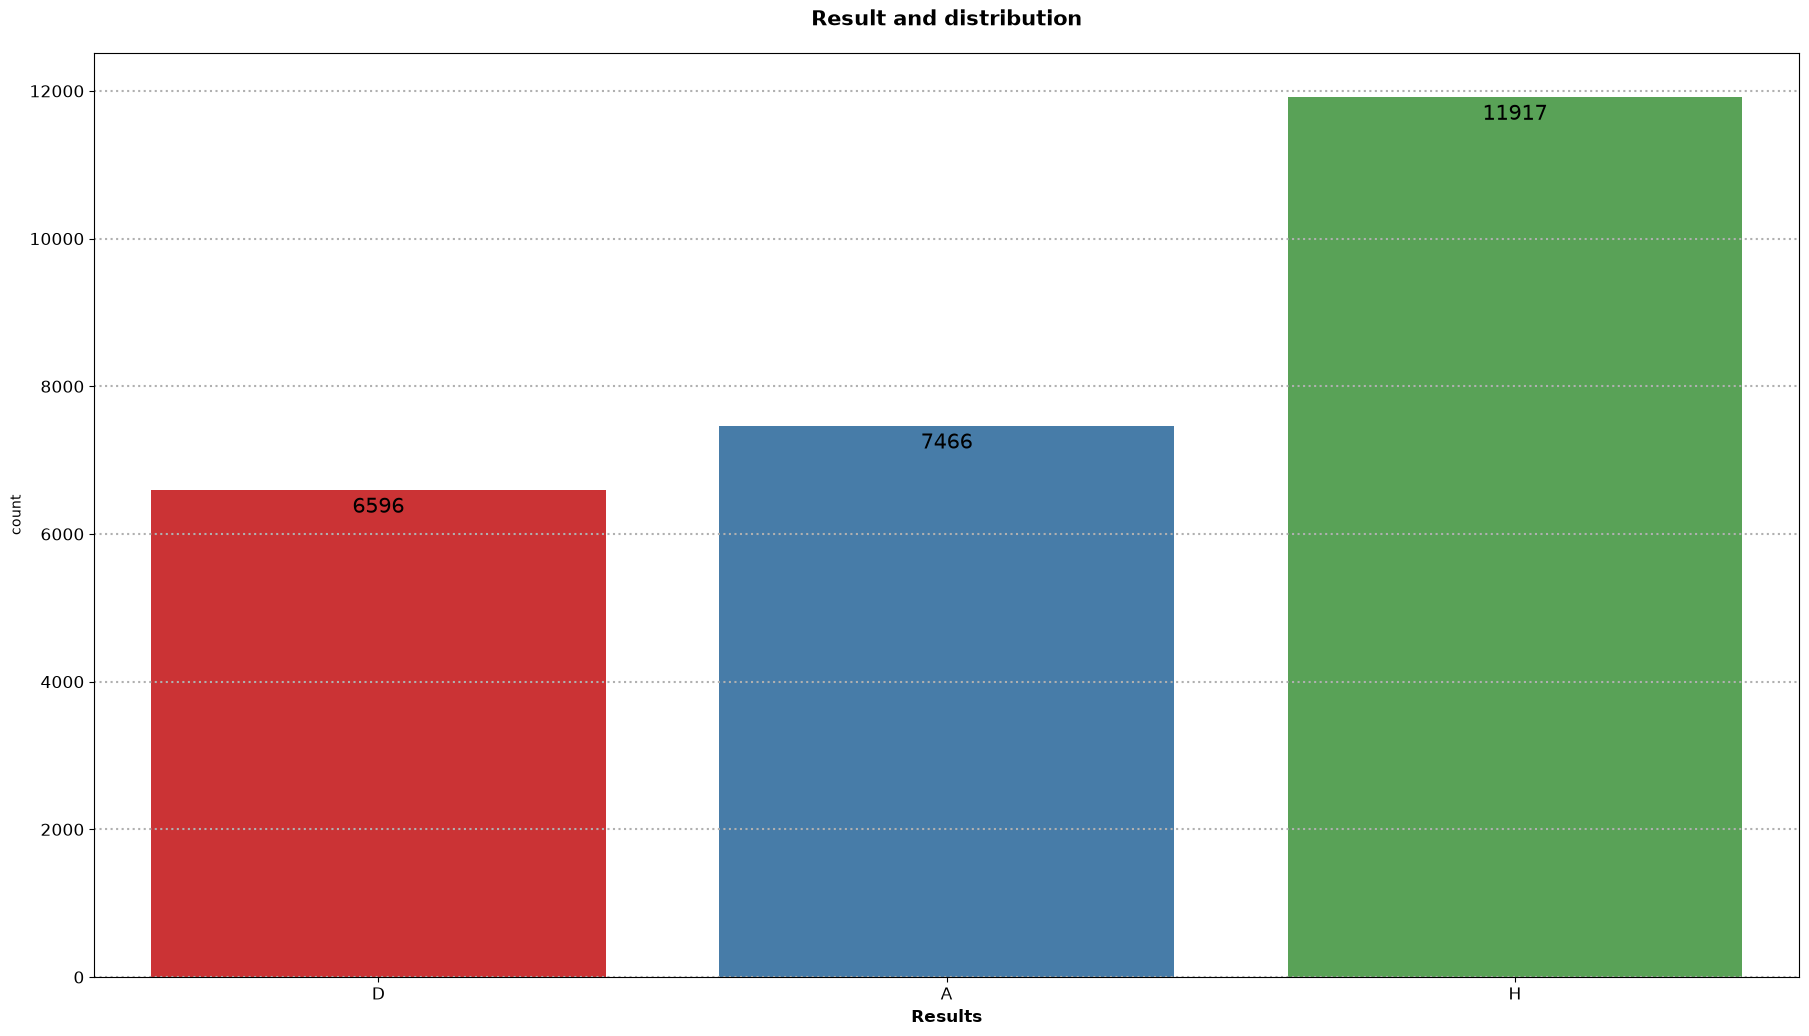

In [63]:
plt.figure(figsize=(22,12))
ax = sns.countplot(data=data, x='FTR', hue='FTR', palette="Set1",linewidth=1.5, alpha=1, )
for container in ax.containers:
    ax.bar_label(container, fontsize=15, padding=-20)
plt.xlabel("Results", fontsize=12, fontweight="bold", alpha=1, )
plt.tick_params(axis='both', labelsize=12, labelcolor='black')
plt.title("Result and distribution", fontsize=15, fontweight='bold', pad=20)
plt.rcParams['axes.axisbelow']=True
plt.grid(True, axis='y', linewidth=1.5, alpha=1, linestyle=':')
plt.show()

The target distribution is reasonably balanced for further modelling. Home wins are the most frequent outcome (11,917), but draws (6,596) and away wins (7,466) also have substantial representation. Therefore, there is no extreme class imbalance that would prevent us from continuing with the modelling process.

---

## Group 1: Season, Stage and League Information

This group contains `season`, `stage`, and `name`. These variables describe
the competition and context in which a match was played. We will investigate
their distributions and examine how they relate to the target `FTR` before
deciding whether they should be retained, transformed, or removed.

In [64]:
group1 = data[['season','stage','name']]

In [65]:
group1.dtypes

season      str
stage     int64
name        str
dtype: object

In [66]:
for i in group1:
    print('*********************************************************************')
    print(group1[i].value_counts())

*********************************************************************
season
2008/2009    3326
2015/2016    3326
2014/2015    3325
2010/2011    3260
2012/2013    3260
2009/2010    3230
2011/2012    3220
2013/2014    3032
Name: count, dtype: int64
*********************************************************************
stage
1     740
2     740
3     740
4     740
5     740
6     740
10    738
11    738
12    738
13    738
14    738
15    738
16    738
17    738
18    738
7     738
8     738
9     738
19    737
20    737
21    737
24    737
25    737
28    737
22    736
29    736
23    735
30    733
26    730
27    730
31    578
32    578
33    578
34    578
35    407
36    407
37    368
38    367
Name: count, dtype: int64
*********************************************************************
name
England Premier League      3040
France Ligue 1              3040
Spain LIGA BBVA             3040
Italy Serie A               3017
Germany 1. Bundesliga       2448
Netherlands Eredivisie      244

In [67]:
group1.isna().sum()

season    0
stage     0
name      0
dtype: int64

In [68]:
group1.describe()

,stage
count,25979.000000
mean,18.242773
std,10.407354
min,1.000000
25%,9.000000
50%,18.000000
75%,27.000000
max,38.000000


*******************************************************************************************************************************************************************************


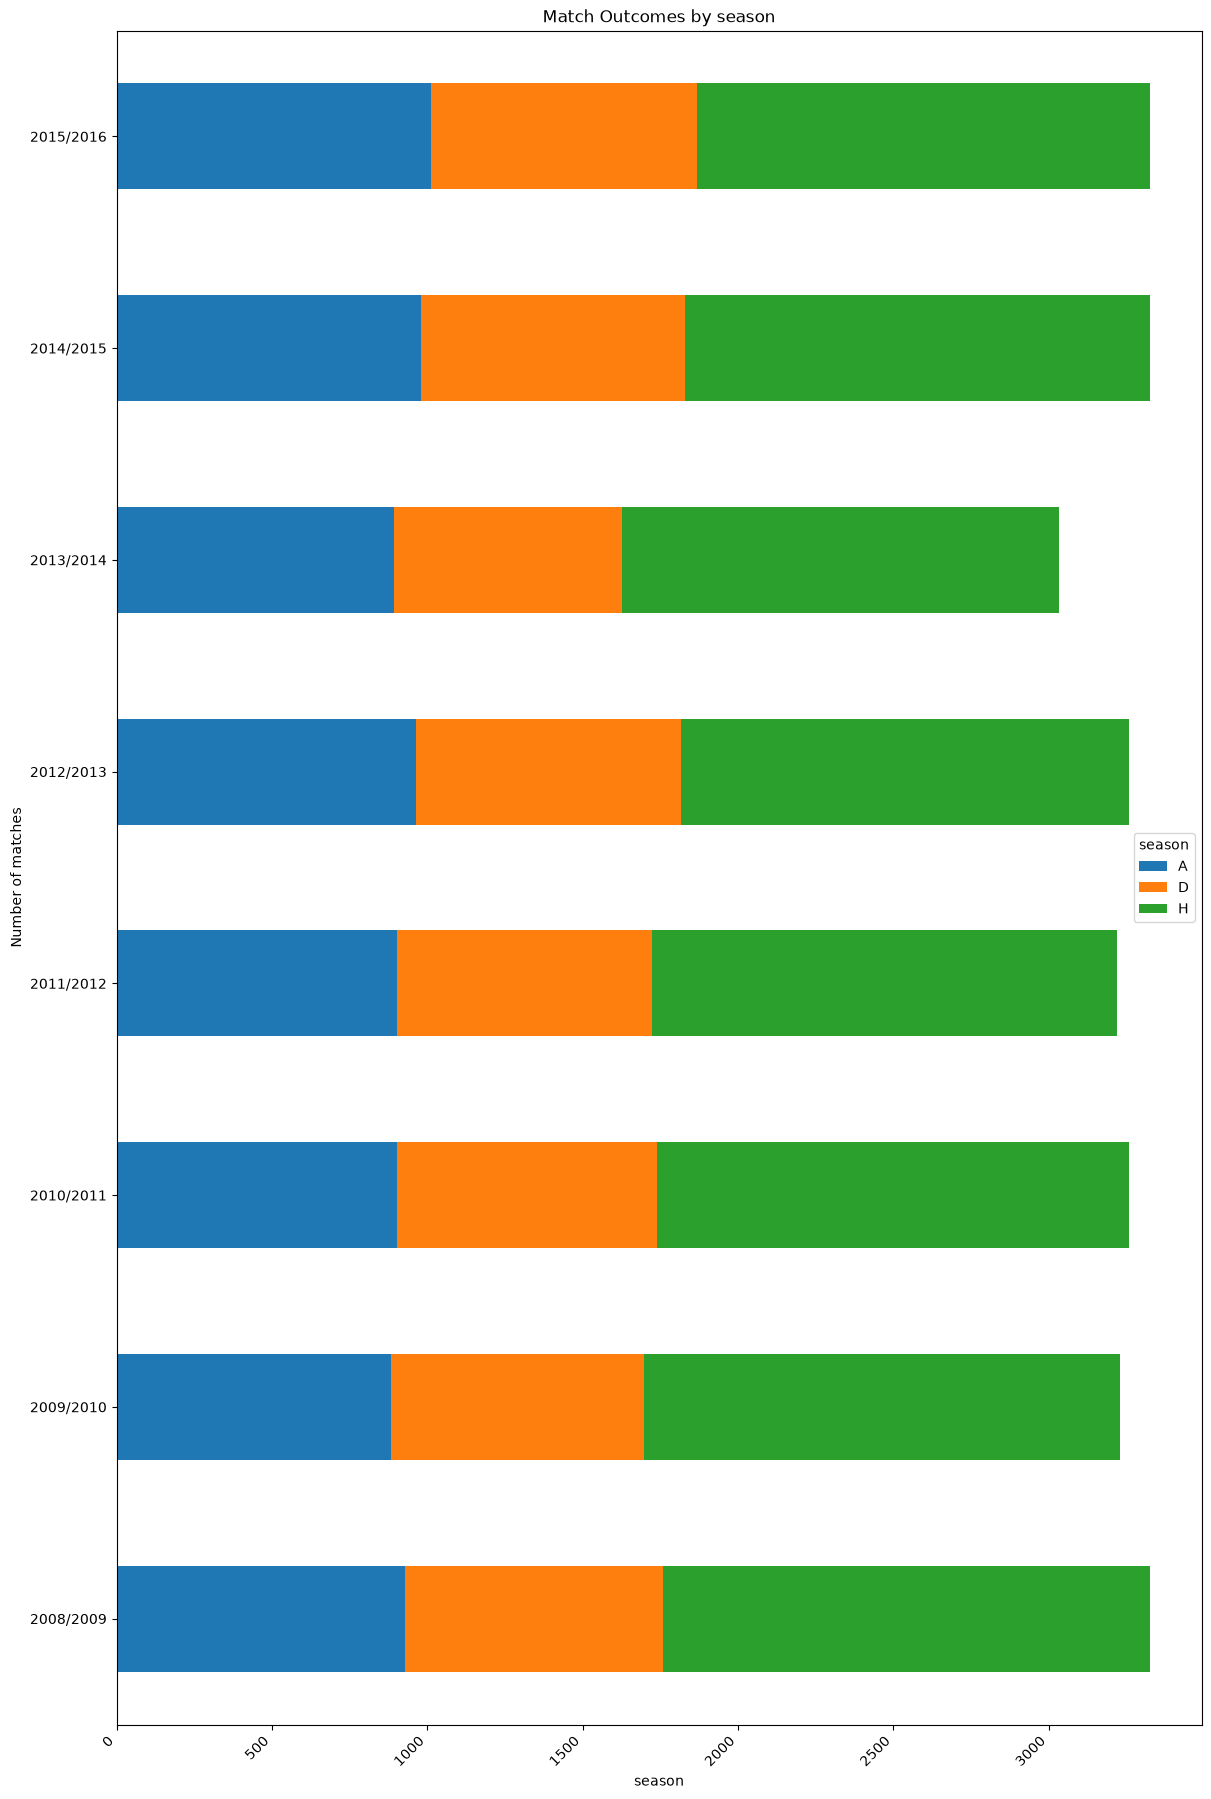

*******************************************************************************************************************************************************************************


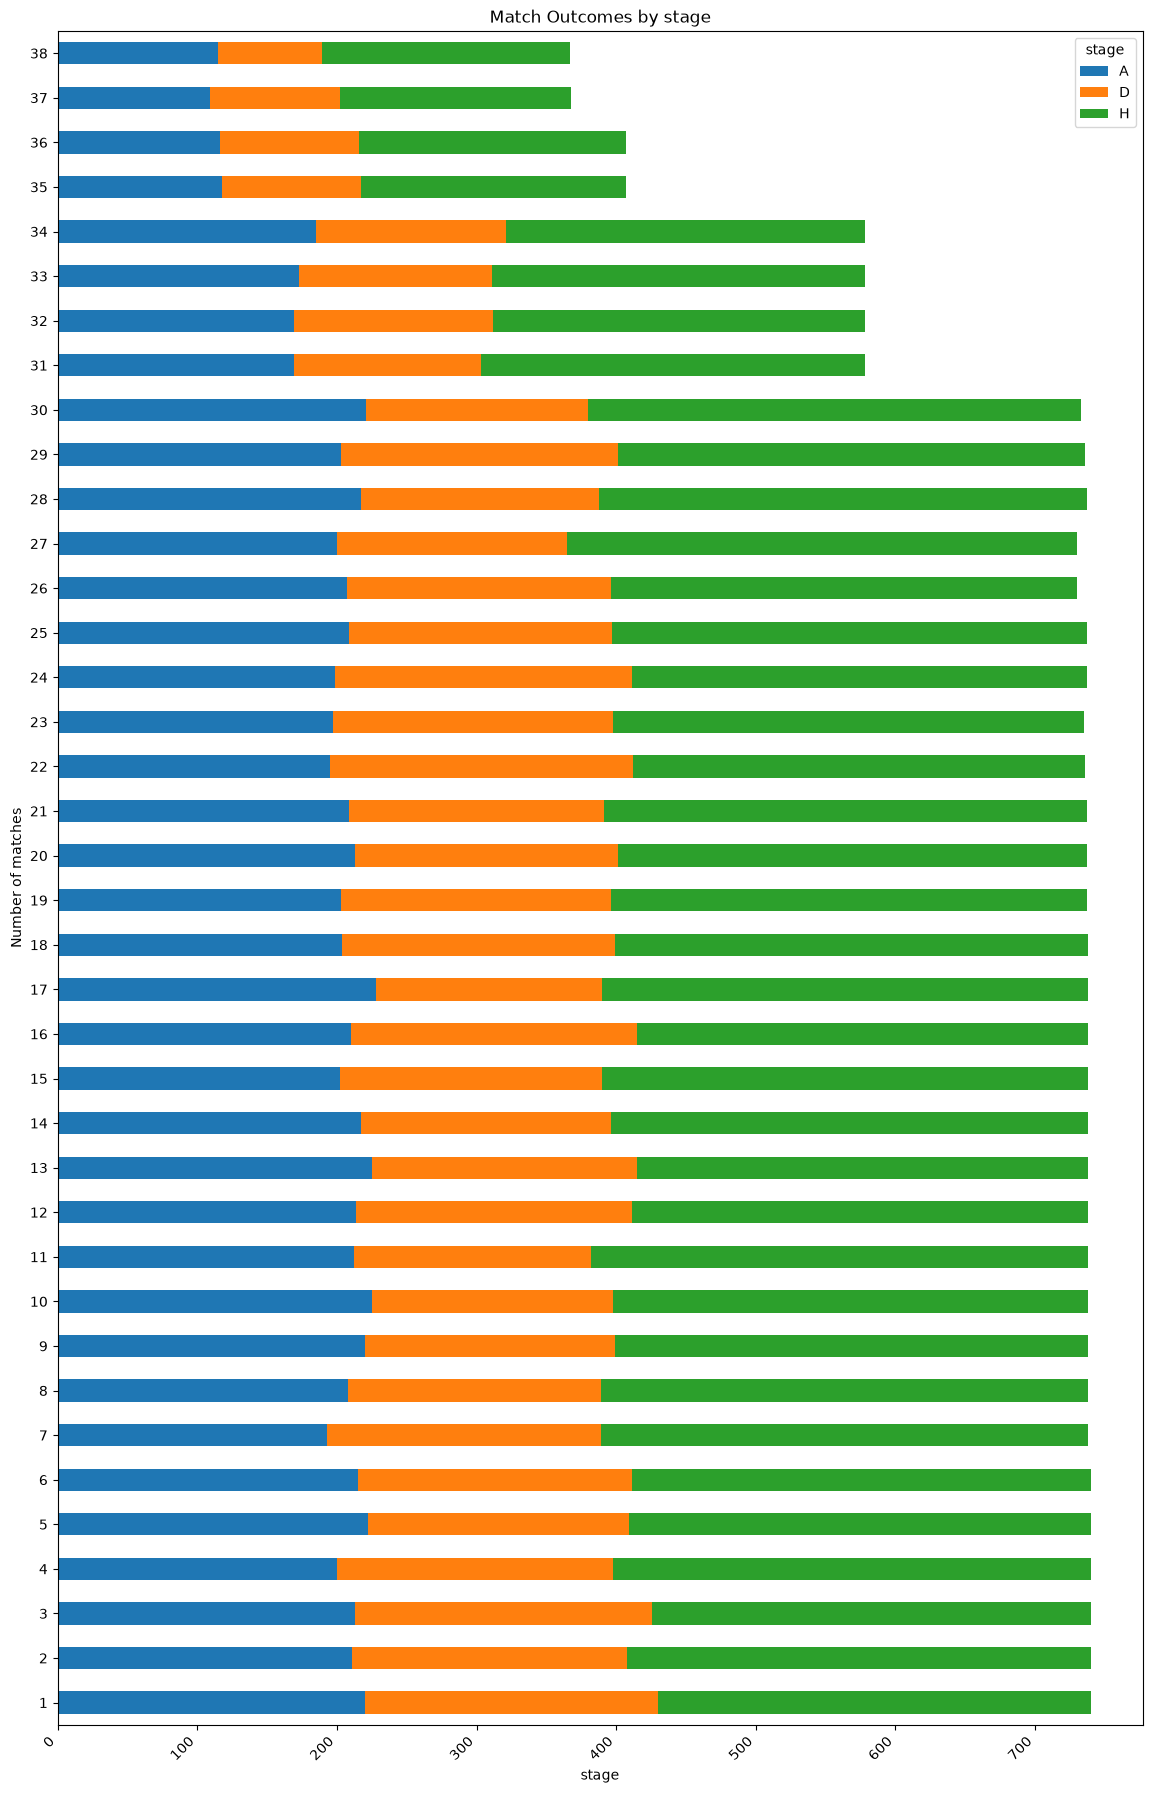

*******************************************************************************************************************************************************************************


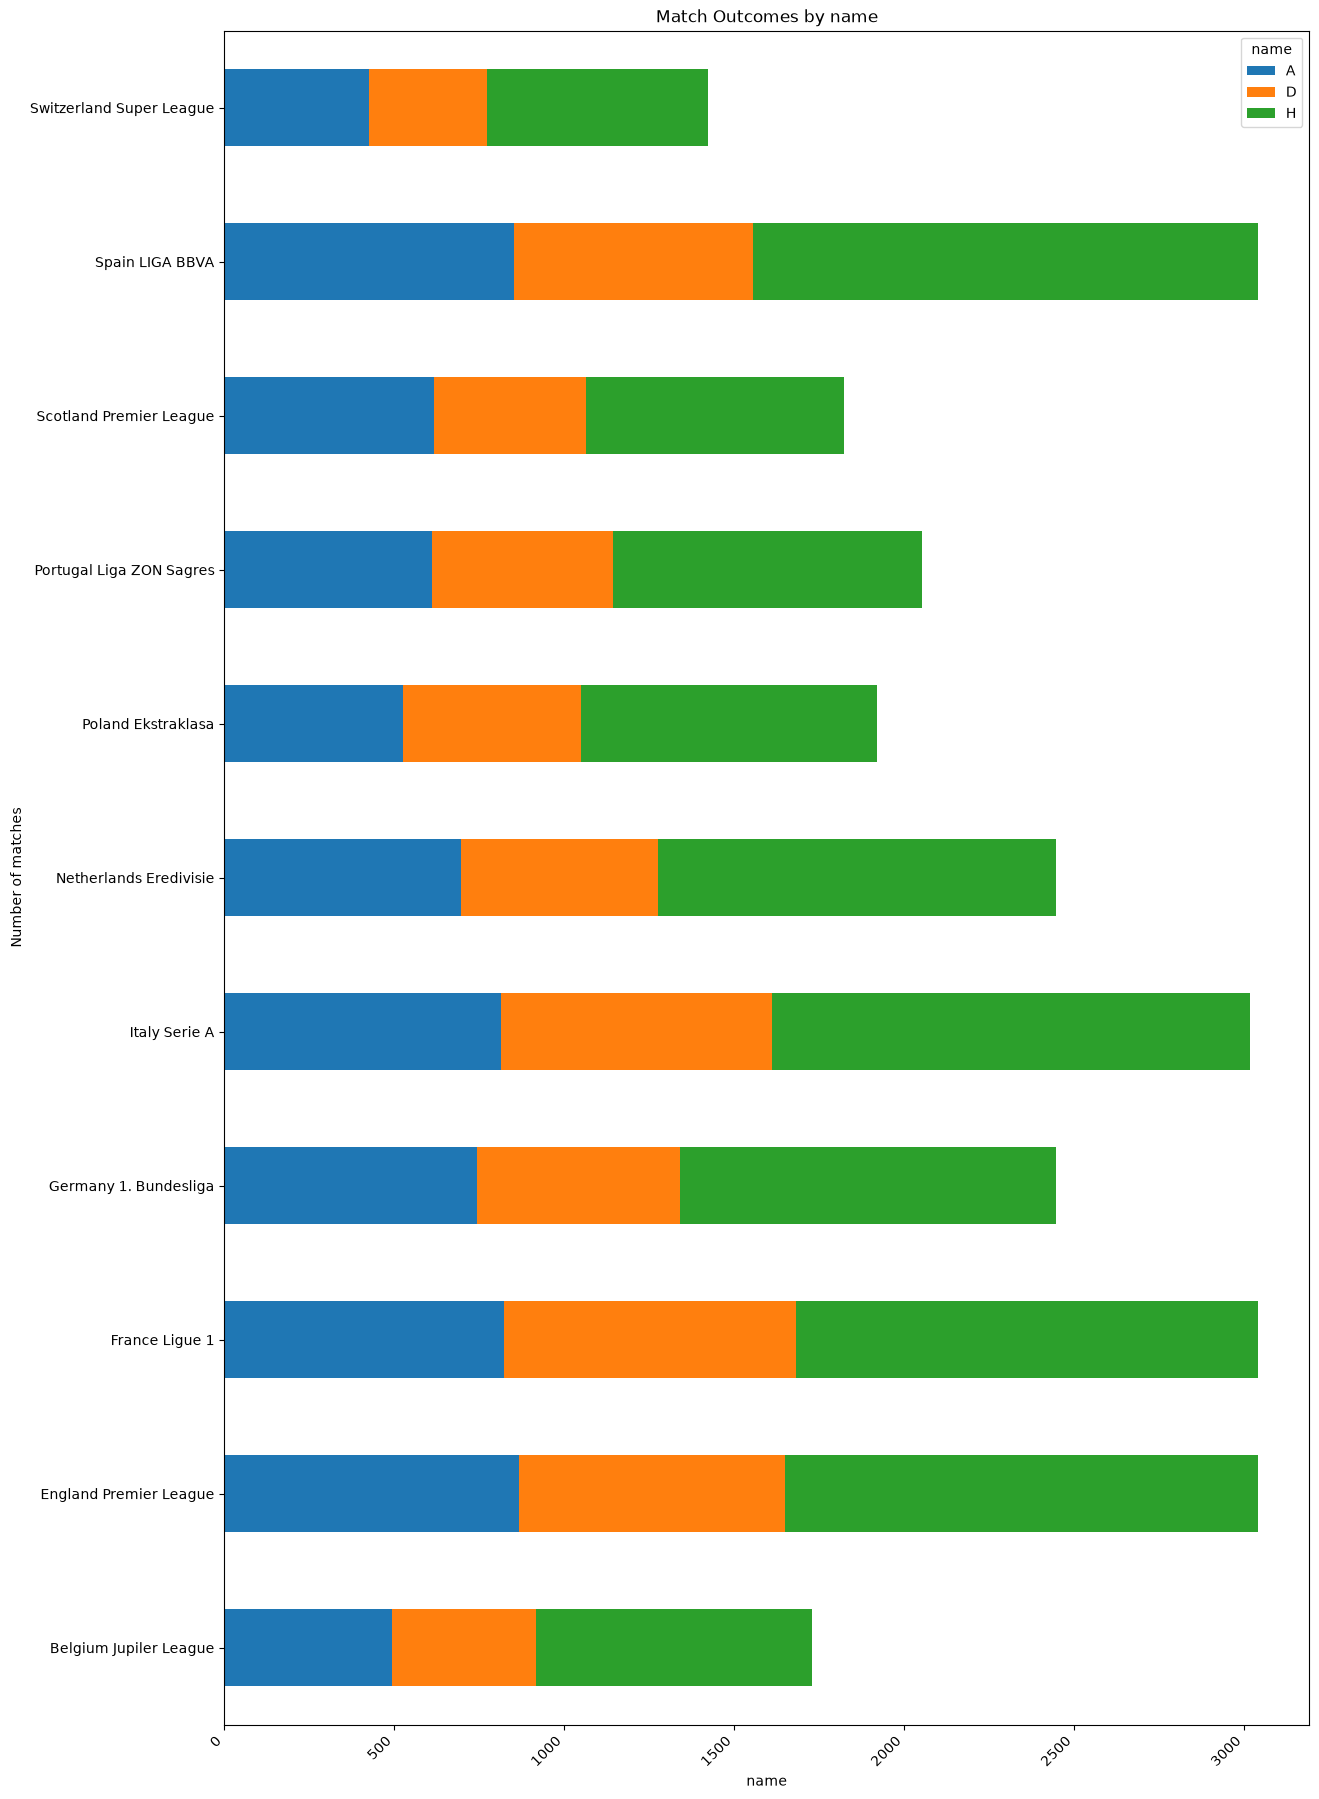

In [69]:
for columns in group1:
    print("*******************************************************************************************************************************************************************************")
    pd.crosstab(group1[columns], data['FTR']).plot(kind="barh", stacked=True,figsize=(14,22))
    plt.xlabel(columns)
    plt.ylabel("Number of matches")
    plt.title(f"Match Outcomes by {columns}")
    plt.legend(title=columns)
    plt.xticks(rotation=45, ha="right")
    plt.show()

### Evaluation

The distributions of `season`, `stage`, and `name` show broadly similar
patterns across the three match outcomes. No clear category-specific
relationship with `FTR` is evident from these visualizations. Therefore,
these features currently provide limited evidence of useful predictive
information and will be considered for removal after the remaining EDA
and feature-selection process.

----

## Player Information - Excluded

The player identifier columns (`home_player_1–11` and `away_player_1–11`)
identify the individual players involved in each match. The corresponding
`X/Y` columns describe their positions within the team formation.

Since our first experiment focuses on **team-level attributes** rather than
individual player information, both the player identifiers and player
position columns will be excluded from modelling and placed in the drop
category. No further EDA will be performed on these columns at this stage.

---

## Match Statistics - Excluded

All match statistics (`shoton`, `shotoff`, `foulcommit`, `card`, `cross`, `corner`, and `possession`) will be excluded because this information is recorded during the match and is unavailable before kickoff. Since our objective is **pre-match outcome prediction**, including these features would cause data leakage and produce unrealistic predictions. Therefore, no further analysis or imputation is required.

---

## Fair Bookmaker Odds Comparison
This section creates a temporary evaluation dataset containing the betting odds from all bookmakers. Only matches where every bookmaker has complete Home, Draw, and Away odds are retained.
Using the same matches for all bookmakers ensures that the comparison is fair and that no bookmaker benefits from having more available data or a different set of matches. Each bookmaker will then be evaluated separately by comparing its predicted match outcome with the actual result (FTR).

In [86]:
import duckdb

In [87]:
betting_stat = duckdb.sql("""
SELECT
    B365H, B365D, B365A,
    BWH, BWD, BWA,
    IWH, IWD, IWA,
    LBH, LBD, LBA,
    PSH, PSD, PSA,
    WHH, WHD, WHA,
    SJH, SJD, SJA,
    VCH, VCD, VCA,
    GBH, GBD, GBA,
    BSH, BSD, BSA,
    FTR
FROM data
WHERE
    B365H IS NOT NULL AND B365D IS NOT NULL AND B365A IS NOT NULL
    AND BWH IS NOT NULL AND BWD IS NOT NULL AND BWA IS NOT NULL
    AND IWH IS NOT NULL AND IWD IS NOT NULL AND IWA IS NOT NULL
    AND LBH IS NOT NULL AND LBD IS NOT NULL AND LBA IS NOT NULL
    AND PSH IS NOT NULL AND PSD IS NOT NULL AND PSA IS NOT NULL
    AND WHH IS NOT NULL AND WHD IS NOT NULL AND WHA IS NOT NULL
    AND SJH IS NOT NULL AND SJD IS NOT NULL AND SJA IS NOT NULL
    AND VCH IS NOT NULL AND VCD IS NOT NULL AND VCA IS NOT NULL
    AND GBH IS NOT NULL AND GBD IS NOT NULL AND GBA IS NOT NULL
    AND BSH IS NOT NULL AND BSD IS NOT NULL AND BSA IS NOT NULL
""").df()

In [88]:
betting_stat.info()

<class 'pandas.DataFrame'>
RangeIndex: 2756 entries, 0 to 2755
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   B365H   2756 non-null   float64
 1   B365D   2756 non-null   float64
 2   B365A   2756 non-null   float64
 3   BWH     2756 non-null   float64
 4   BWD     2756 non-null   float64
 5   BWA     2756 non-null   float64
 6   IWH     2756 non-null   float64
 7   IWD     2756 non-null   float64
 8   IWA     2756 non-null   float64
 9   LBH     2756 non-null   float64
 10  LBD     2756 non-null   float64
 11  LBA     2756 non-null   float64
 12  PSH     2756 non-null   float64
 13  PSD     2756 non-null   float64
 14  PSA     2756 non-null   float64
 15  WHH     2756 non-null   float64
 16  WHD     2756 non-null   float64
 17  WHA     2756 non-null   float64
 18  SJH     2756 non-null   float64
 19  SJD     2756 non-null   float64
 20  SJA     2756 non-null   float64
 21  VCH     2756 non-null   float64
 22  VCD     275

In [89]:
betting_stat.shape

(2756, 31)

### Next Step

Each bookmaker will now be evaluated individually to measure how accurately its odds predict the actual match result (`FTR`) on the same 2,756 matches.

The bookmakers will then be compared based on their prediction accuracy. Only the stronger and more reliable bookmakers will be considered for the final modelling feature set, while consistently weak bookmakers will be candidates for exclusion.

---

## Bet365 Prediction Accuracy

In [90]:
group2 = betting_stat[["B365H","B365D","B365A","FTR"]]

In [92]:
home = 1/group2["B365H"]
away = 1/group2["B365A"]
draw = 1/group2["B365D"]

total = home+away+draw

group2["B365H_porb"] = (home/total).round(3)
group2["B365A_porb"] = (away/total).round(3)
group2["B365D_porb"] = (draw/total).round(3)

group2.head()


,B365H,B365D,B365A,FTR,B365H_porb,B365A_porb,B365D_porb
0,2.38,3.25,3.00,A,0.396,0.314,0.290
1,1.80,3.60,4.33,H,0.522,0.217,0.261
2,1.65,3.80,5.00,A,0.567,0.187,0.246
3,1.50,4.00,7.00,H,0.629,0.135,0.236
4,1.29,5.25,10.00,H,0.727,0.094,0.179


In [93]:
group2["Predicted_FTR"] = group2[
    ["B365H_porb", "B365D_porb", "B365A_porb"]
].idxmax(axis=1).map({
    "B365H_porb": "H",
    "B365D_porb": "D",
    "B365A_porb": "A"
})

In [94]:
group2.head()

,B365H,B365D,B365A,FTR,B365H_porb,B365A_porb,B365D_porb,Predicted_FTR
0,2.38,3.25,3.00,A,0.396,0.314,0.290,H
1,1.80,3.60,4.33,H,0.522,0.217,0.261,H
2,1.65,3.80,5.00,A,0.567,0.187,0.246,H
3,1.50,4.00,7.00,H,0.629,0.135,0.236,H
4,1.29,5.25,10.00,H,0.727,0.094,0.179,H


In [96]:
group2["correct"] = (group2["FTR"] == group2["Predicted_FTR"]).astype(int)

In [98]:
group2.head()

,B365H,B365D,B365A,FTR,B365H_porb,B365A_porb,B365D_porb,Predicted_FTR,correct
0,2.38,3.25,3.00,A,0.396,0.314,0.290,H,0
1,1.80,3.60,4.33,H,0.522,0.217,0.261,H,1
2,1.65,3.80,5.00,A,0.567,0.187,0.246,H,0
3,1.50,4.00,7.00,H,0.629,0.135,0.236,H,1
4,1.29,5.25,10.00,H,0.727,0.094,0.179,H,1


In [107]:
accuracy = round(float(group2["correct"].mean()), 3)
accuracy = accuracy * 100

print(f"{accuracy}%")

51.2%


Bet365 correctly predicted the final match outcome in 51.2% of the evaluated matches. This means that, when the outcome with the highest implied probability was treated as Bet365’s prediction, it matched the actual FTR result slightly more than half of the time.
This result provides a baseline measure of Bet365’s predictive strength. The same process will now be repeated for the remaining bookmakers so their accuracies can be compared fairly on the same set of matches.

---

## Bet&Win Prediction Accuracy

In [108]:
group3 = betting_stat[["BWH","BWD", "BWA", "FTR"]]
group3.head()

,BWH,BWD,BWA,FTR
0,2.45,3.3,2.7,A
1,1.75,3.7,4.2,H
2,1.67,3.6,5.0,A
3,1.53,3.9,6.0,H
4,1.25,5.5,10.0,H


In [ ]:
home = 1/group3["BWH"]
away = 1/group3["BWA"]
draw = 1/group3["BWD"]

total = home+away+draw

group3["BWH_porb"] = (home/total).round(3)
group3["BWA_porb"] = (away/total).round(3)
group3["BWD_porb"] = (draw/total).round(3)

group3.head()


,BWH,BWD,BWA,FTR,BWH_porb,BWA_porb,BWD_porb
0,2.45,3.3,2.7,A,0.377,0.342,0.280
1,1.75,3.7,4.2,H,0.529,0.221,0.250
2,1.67,3.6,5.0,A,0.556,0.186,0.258
3,1.53,3.9,6.0,H,0.607,0.155,0.238
4,1.25,5.5,10.0,H,0.739,0.092,0.168


In [111]:
group3["pred_FTR"] =  group3[["BWH_porb" , "BWA_porb", "BWD_porb"]].idxmax(axis=1).map({"BWH_porb":"H", "BWA_porb":"A", "BWD_porb":"D"})
group3.head()

,BWH,BWD,BWA,FTR,BWH_porb,BWA_porb,BWD_porb,pred_FTR
0,2.45,3.3,2.7,A,0.377,0.342,0.280,H
1,1.75,3.7,4.2,H,0.529,0.221,0.250,H
2,1.67,3.6,5.0,A,0.556,0.186,0.258,H
3,1.53,3.9,6.0,H,0.607,0.155,0.238,H
4,1.25,5.5,10.0,H,0.739,0.092,0.168,H


In [112]:
group3["correct"] = (group3["FTR"] == group3["pred_FTR"]).astype(int)

In [113]:
accuracy = round(float(group3["correct"].mean()),3)*100
print(f"{accuracy}%")

51.1%


### Bet & Win Prediction Accuracy
Bet & Win achieved an accuracy of 51.1%, which is almost identical to Bet365’s 51.2%. This suggests that both bookmakers have very similar raw predictive performance on the same set of matches.
At this stage, neither bookmaker clearly outperforms the other, so both should remain under consideration until the remaining bookmakers are evaluated.

----

In [114]:
group4 = betting_stat[["IWH","IWD", "IWA", "FTR"]]
group4.head()

,IWH,IWD,IWA,FTR
0,2.30,3.1,2.6,A
1,1.80,3.2,3.7,H
2,1.65,3.3,4.4,A
3,1.50,3.7,5.0,H
4,1.25,4.5,9.0,H


In [115]:
home = 1/group4["IWH"]
away = 1/group4["IWA"]
draw = 1/group4["IWD"]

total = home+away+draw

group4["IWH_porb"] = (home/total).round(3)
group4["IWA_porb"] = (away/total).round(3)
group4["IWD_porb"] = (draw/total).round(3)

group4.head()

,IWH,IWD,IWA,FTR,IWH_porb,IWA_porb,IWD_porb
0,2.30,3.1,2.6,A,0.381,0.337,0.282
1,1.80,3.2,3.7,H,0.488,0.237,0.275
2,1.65,3.3,4.4,A,0.533,0.200,0.267
3,1.50,3.7,5.0,H,0.586,0.176,0.238
4,1.25,4.5,9.0,H,0.706,0.098,0.196


In [119]:
group4["pred_FTR"] = group4[
    ["IWH_porb", "IWD_porb", "IWA_porb"]
].idxmax(axis=1).map({
    "IWH_porb": "H",
    "IWD_porb": "D",
    "IWA_porb": "A"
})

In [120]:
group4["correct"] = (group4["FTR"] == group4["pred_FTR"]).astype(int)

In [121]:
accuracy = round(float(group4["correct"].mean()), 3) * 100
print(f"{accuracy}%")

51.1%


### Interwetten Prediction Accuracy
Interwetten achieved a prediction accuracy of 51.1%, meaning its highest implied-probability outcome matched the actual FTR result in just over half of the evaluated matches.
This performance is almost identical to Bet365 and Bet & Win, suggesting that the three bookmakers currently show very similar raw predictive strength.

---

## Ladbrokes Prediction Accuracy

In [123]:
group5 = betting_stat[["LBH","LBD", "LBA", "FTR"]]
group5.head()

,LBH,LBD,LBA,FTR
0,2.38,3.2,2.75,A
1,1.73,3.4,4.33,H
2,1.67,3.5,4.50,A
3,1.50,3.8,6.00,H
4,1.25,5.0,10.00,H


In [124]:
home = 1/group5["LBH"]
away = 1/group5["LBA"]
draw = 1/group5["LBD"]

total = home+away+draw

group5["LBH_porb"] = (home/total).round(3)
group5["LBA_porb"] = (away/total).round(3)
group5["LBD_porb"] = (draw/total).round(3)

group5.head()

,LBH,LBD,LBA,FTR,LBH_porb,LBA_porb,LBD_porb
0,2.38,3.2,2.75,A,0.383,0.332,0.285
1,1.73,3.4,4.33,H,0.524,0.209,0.267
2,1.67,3.5,4.50,A,0.541,0.201,0.258
3,1.50,3.8,6.00,H,0.608,0.152,0.240
4,1.25,5.0,10.00,H,0.727,0.091,0.182


In [125]:
group5["pred_FTR"] = group5[
    ["LBH_porb", "LBD_porb", "LBA_porb"]
].idxmax(axis=1).map({
    "LBH_porb": "H",
    "LBD_porb": "D",
    "LBA_porb": "A"
})

In [126]:
group5["correct"] = (group5["FTR"] == group5["pred_FTR"]).astype(int)

In [127]:
accuracy = round(float(group5["correct"].mean()), 3) * 100
print(f"{accuracy}%")

51.1%


### Ladbrokes Prediction Accuracy
Ladbrokes achieved a prediction accuracy of 51.1%, meaning its highest implied-probability outcome matched the actual FTR result in just over half of the evaluated matches.
This performance is identical to Bet & Win and Interwetten at 51.1%, and slightly below Bet365 at 51.2%.

---

## Pinnacle Prediction Accuracy

In [128]:
group6 = betting_stat[["PSH","PSD", "PSA", "FTR"]]
group6.head()

,PSH,PSD,PSA,FTR
0,2.48,3.52,2.96,A
1,1.83,3.79,4.63,H
2,1.74,3.82,5.20,A
3,1.58,4.27,6.25,H
4,1.29,5.74,12.41,H


In [129]:
home = 1/group6["PSH"]
away = 1/group6["PSA"]
draw = 1/group6["PSD"]

total = home+away+draw

group6["PSH_porb"] = (home/total).round(3)
group6["PSA_porb"] = (away/total).round(3)
group6["PSD_porb"] = (draw/total).round(3)

group6.head()

,PSH,PSD,PSA,FTR,PSH_porb,PSA_porb,PSD_porb
0,2.48,3.52,2.96,A,0.393,0.330,0.277
1,1.83,3.79,4.63,H,0.532,0.210,0.257
2,1.74,3.82,5.20,A,0.559,0.187,0.254
3,1.58,4.27,6.25,H,0.616,0.156,0.228
4,1.29,5.74,12.41,H,0.753,0.078,0.169


In [130]:
group6["pred_FTR"] = group6[
    ["PSH_porb", "PSD_porb", "PSA_porb"]
].idxmax(axis=1).map({
    "PSH_porb": "H",
    "PSD_porb": "D",
    "PSA_porb": "A"
})

In [131]:
group6["correct"] = (group6["FTR"] == group6["pred_FTR"]).astype(int)

In [159]:
accuracy = round(float(group6["correct"].mean()), 3) * 100
print(f"{round(accuracy,3)}%")

51.3%


### Pinnacle Prediction Accuracy
Pinnacle achieved a prediction accuracy of 51.3%, meaning its highest implied-probability outcome matched the actual FTR result in just over half of the evaluated matches.
This performance is slightly above Bet365 at 51.2% and Bet & Win and Interwetten at 51.1%, suggesting very similar raw predictive strength.

---

## William Hill Prediction Accuracy

In [133]:
group7 = betting_stat[["WHH","WHD", "WHA", "FTR"]]
group7.head()

,WHH,WHD,WHA,FTR
0,2.30,3.3,2.80,A
1,1.73,3.5,4.33,H
2,1.57,3.6,5.50,A
3,1.50,3.8,6.00,H
4,1.25,5.0,11.00,H


In [134]:
home = 1/group7["WHH"]
away = 1/group7["WHA"]
draw = 1/group7["WHD"]

total = home+away+draw

group7["WHH_porb"] = (home/total).round(3)
group7["WHA_porb"] = (away/total).round(3)
group7["WHD_porb"] = (draw/total).round(3)

group7.head()

,WHH,WHD,WHA,FTR,WHH_porb,WHA_porb,WHD_porb
0,2.30,3.3,2.80,A,0.397,0.326,0.277
1,1.73,3.5,4.33,H,0.528,0.211,0.261
2,1.57,3.6,5.50,A,0.581,0.166,0.253
3,1.50,3.8,6.00,H,0.608,0.152,0.240
4,1.25,5.0,11.00,H,0.733,0.083,0.183


In [135]:
group7["pred_FTR"] = group7[
    ["WHH_porb", "WHD_porb", "WHA_porb"]
].idxmax(axis=1).map({
    "WHH_porb": "H",
    "WHD_porb": "D",
    "WHA_porb": "A"
})

In [136]:
group7["correct"] = (group7["FTR"] == group7["pred_FTR"]).astype(int)

In [137]:
accuracy = round(float(group7["correct"].mean()), 3) * 100
print(f"{accuracy}%")

51.0%


### William Hill Prediction Accuracy
William Hill achieved a prediction accuracy of 51.0%, meaning its highest implied-probability outcome matched the actual FTR result in just over half of the evaluated matches.
This performance is slightly below Bet365 at 51.2% and Bet & Win and Interwetten at 51.1%, suggesting very similar raw predictive strength.

---

## Stan James Prediction Accuracy

In [138]:
group8 = betting_stat[["SJH","SJD", "SJA", "FTR"]]
group8.head()

,SJH,SJD,SJA,FTR
0,2.38,3.3,2.88,A
1,1.73,3.6,4.50,H
2,1.62,3.6,5.50,A
3,1.50,4.0,6.00,H
4,1.25,5.5,11.00,H


In [139]:
home = 1/group8["SJH"]
away = 1/group8["SJA"]
draw = 1/group8["SJD"]

total = home+away+draw

group8["SJH_porb"] = (home/total).round(3)
group8["SJA_porb"] = (away/total).round(3)
group8["SJD_porb"] = (draw/total).round(3)

group8.head()

,SJH,SJD,SJA,FTR,SJH_porb,SJA_porb,SJD_porb
0,2.38,3.3,2.88,A,0.393,0.324,0.283
1,1.73,3.6,4.50,H,0.536,0.206,0.258
2,1.62,3.6,5.50,A,0.573,0.169,0.258
3,1.50,4.0,6.00,H,0.615,0.154,0.231
4,1.25,5.5,11.00,H,0.746,0.085,0.169


In [140]:
group8["pred_FTR"] = group8[
    ["SJH_porb", "SJD_porb", "SJA_porb"]
].idxmax(axis=1).map({
    "SJH_porb": "H",
    "SJD_porb": "D",
    "SJA_porb": "A"
})

In [141]:
group8["correct"] = (group8["FTR"] == group8["pred_FTR"]).astype(int)

In [142]:
accuracy = round(float(group8["correct"].mean()), 3) * 100
print(f"{accuracy}%")

51.1%


### Stan James Prediction Accuracy
Stan James achieved a prediction accuracy of 51.1%, meaning its highest implied-probability outcome matched the actual FTR result in just over half of the evaluated matches.
This performance is identical to Bet & Win and Interwetten at 51.1%, and slightly below Bet365 at 51.2%.

---

## VC Bet Prediction Accuracy

In [143]:
group9 = betting_stat[["VCH","VCD", "VCA", "FTR"]]
group9.head()

,VCH,VCD,VCA,FTR
0,2.40,3.4,2.9,A
1,1.80,3.6,4.5,H
2,1.70,3.7,5.0,A
3,1.57,3.9,6.0,H
4,1.25,5.5,12.0,H


In [144]:
home = 1/group9["VCH"]
away = 1/group9["VCA"]
draw = 1/group9["VCD"]

total = home+away+draw

group9["VCH_porb"] = (home/total).round(3)
group9["VCA_porb"] = (away/total).round(3)
group9["VCD_porb"] = (draw/total).round(3)

group9.head()

,VCH,VCD,VCA,FTR,VCH_porb,VCA_porb,VCD_porb
0,2.40,3.4,2.9,A,0.395,0.327,0.279
1,1.80,3.6,4.5,H,0.526,0.211,0.263
2,1.70,3.7,5.0,A,0.556,0.189,0.255
3,1.57,3.9,6.0,H,0.601,0.157,0.242
4,1.25,5.5,12.0,H,0.751,0.078,0.171


In [145]:
group9["pred_FTR"] = group9[
    ["VCH_porb", "VCD_porb", "VCA_porb"]
].idxmax(axis=1).map({
    "VCH_porb": "H",
    "VCD_porb": "D",
    "VCA_porb": "A"
})

In [146]:
group9["correct"] = (group9["FTR"] == group9["pred_FTR"]).astype(int)

In [147]:
accuracy = round(float(group9["correct"].mean()), 3) * 100
print(f"{accuracy}%")

51.1%


### VC Bet Prediction Accuracy
VC Bet achieved a prediction accuracy of 51.1%, meaning its highest implied-probability outcome matched the actual FTR result in just over half of the evaluated matches.
This performance is identical to Bet & Win and Interwetten at 51.1%, and slightly below Bet365 at 51.2%.

---

## Gamebookers Prediction Accuracy

In [148]:
group10 = betting_stat[["GBH","GBD", "GBA", "FTR"]]
group10.head()

,GBH,GBD,GBA,FTR
0,2.45,3.3,2.7,A
1,1.75,3.7,4.2,H
2,1.67,3.6,5.0,A
3,1.53,3.9,6.0,H
4,1.25,5.5,10.0,H


In [149]:
home = 1/group10["GBH"]
away = 1/group10["GBA"]
draw = 1/group10["GBD"]

total = home+away+draw

group10["GBH_porb"] = (home/total).round(3)
group10["GBA_porb"] = (away/total).round(3)
group10["GBD_porb"] = (draw/total).round(3)

group10.head()

,GBH,GBD,GBA,FTR,GBH_porb,GBA_porb,GBD_porb
0,2.45,3.3,2.7,A,0.377,0.342,0.280
1,1.75,3.7,4.2,H,0.529,0.221,0.250
2,1.67,3.6,5.0,A,0.556,0.186,0.258
3,1.53,3.9,6.0,H,0.607,0.155,0.238
4,1.25,5.5,10.0,H,0.739,0.092,0.168


In [150]:
group10["pred_FTR"] = group10[
    ["GBH_porb", "GBD_porb", "GBA_porb"]
].idxmax(axis=1).map({
    "GBH_porb": "H",
    "GBD_porb": "D",
    "GBA_porb": "A"
})

In [151]:
group10["correct"] = (group10["FTR"] == group10["pred_FTR"]).astype(int)

In [152]:
accuracy = round(float(group10["correct"].mean()), 3) * 100
print(f"{accuracy}%")

51.1%


### Gamebookers Prediction Accuracy
Gamebookers achieved a prediction accuracy of 51.1%, meaning its highest implied-probability outcome matched the actual FTR result in just over half of the evaluated matches.
This performance is identical to Bet & Win and Interwetten at 51.1%, and slightly below Bet365 at 51.2%.

---

## Blue Square Prediction Accuracy

In [153]:
group11 = betting_stat[["BSH","BSD", "BSA", "FTR"]]
group11.head()

,BSH,BSD,BSA,FTR
0,2.40,3.25,2.7,A
1,1.80,3.50,4.0,H
2,1.70,3.50,4.5,A
3,1.50,3.80,6.0,H
4,1.25,5.50,9.0,H


In [154]:
home = 1/group11["BSH"]
away = 1/group11["BSA"]
draw = 1/group11["BSD"]

total = home+away+draw

group11["BSH_porb"] = (home/total).round(3)
group11["BSA_porb"] = (away/total).round(3)
group11["BSD_porb"] = (draw/total).round(3)

group11.head()

,BSH,BSD,BSA,FTR,BSH_porb,BSA_porb,BSD_porb
0,2.40,3.25,2.7,A,0.381,0.338,0.281
1,1.80,3.50,4.0,H,0.509,0.229,0.262
2,1.70,3.50,4.5,A,0.537,0.203,0.261
3,1.50,3.80,6.0,H,0.608,0.152,0.240
4,1.25,5.50,9.0,H,0.732,0.102,0.166


In [155]:
group11["pred_FTR"] = group11[
    ["BSH_porb", "BSD_porb", "BSA_porb"]
].idxmax(axis=1).map({
    "BSH_porb": "H",
    "BSD_porb": "D",
    "BSA_porb": "A"
})

In [156]:
group11["correct"] = (group11["FTR"] == group11["pred_FTR"]).astype(int)

In [157]:
accuracy = round(float(group11["correct"].mean()), 3) * 100
print(f"{accuracy}%")

51.1%


### Blue Square Prediction Accuracy
Blue Square achieved a prediction accuracy of 51.1%, meaning its highest implied-probability outcome matched the actual FTR result in just over half of the evaluated matches.
This performance is identical to Bet & Win and Interwetten at 51.1%, and slightly below Bet365 at 51.2%.

---

## Bookmaker Feature Selection for Experimentation
Bet365, Bet & Win, and Ladbrokes were selected as the initial bookmaker features for modelling. Their prediction accuracies are very similar to the other bookmakers, while they also have some of the lowest missingness levels at around 13%.
The remaining bookmakers were not selected at this stage because their predictive accuracy is almost identical, while several contain more missing values. Therefore, adding all bookmakers would increase feature count without clear evidence of additional value.
These three bookmakers are only an experimental starting set. The final bookmaker features will be decided after comparing model performance with and without them.

---

## Home Team Attributes and Playing Style
This section examines the home team's tactical and playing-style attributes, including build-up play, chance creation, and defensive characteristics. Both numerical and categorical attributes are explored to understand their distributions and whether they show any relationship with the match outcome (FTR).

In [160]:
group12 = data[[
    "home_buildUpPlaySpeed",
    "home_buildUpPlaySpeedClass",
    "home_buildUpPlayDribbling",
    "home_buildUpPlayDribblingClass",
    "home_buildUpPlayPassing",
    "home_buildUpPlayPassingClass",
    "home_buildUpPlayPositioningClass",
    "home_chanceCreationPassing",
    "home_chanceCreationPassingClass",
    "home_chanceCreationCrossing",
    "home_chanceCreationCrossingClass",
    "home_chanceCreationShooting",
    "home_chanceCreationShootingClass",
    "home_chanceCreationPositioningClass",
    "home_defencePressure",
    "home_defencePressureClass",
    "home_defenceAggression",
    "home_defenceAggressionClass",
    "home_defenceTeamWidth",
    "home_defenceTeamWidthClass",
    "home_defenceDefenderLineClass"
]]

In [161]:
group12.head()

,home_buildUpPlaySpeed,home_buildUpPlaySpeedClass,home_buildUpPlayDribbling,home_buildUpPlayDribblingClass,home_buildUpPlayPassing,home_buildUpPlayPassingClass,home_buildUpPlayPositioningClass,home_chanceCreationPassing,home_chanceCreationPassingClass,home_chanceCreationCrossing,home_chanceCreationCrossingClass,home_chanceCreationShooting,home_chanceCreationShootingClass,home_chanceCreationPositioningClass,home_defencePressure,home_defencePressureClass,home_defenceAggression,home_defenceAggressionClass,home_defenceTeamWidth,home_defenceTeamWidthClass,home_defenceDefenderLineClass
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [162]:
group12.info()

<class 'pandas.DataFrame'>
RangeIndex: 25979 entries, 0 to 25978
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   home_buildUpPlaySpeed                18816 non-null  float64
 1   home_buildUpPlaySpeedClass           18816 non-null  str    
 2   home_buildUpPlayDribbling            6295 non-null   float64
 3   home_buildUpPlayDribblingClass       18816 non-null  str    
 4   home_buildUpPlayPassing              18816 non-null  float64
 5   home_buildUpPlayPassingClass         18816 non-null  str    
 6   home_buildUpPlayPositioningClass     18816 non-null  str    
 7   home_chanceCreationPassing           18816 non-null  float64
 8   home_chanceCreationPassingClass      18816 non-null  str    
 9   home_chanceCreationCrossing          18816 non-null  float64
 10  home_chanceCreationCrossingClass     18816 non-null  str    
 11  home_chanceCreationShooting          18

In [177]:
(group12.isnull().mean())*100

home_buildUpPlaySpeed                  27.57227
home_buildUpPlaySpeedClass             27.57227
home_buildUpPlayDribbling              75.76889
home_buildUpPlayDribblingClass         27.57227
home_buildUpPlayPassing                27.57227
home_buildUpPlayPassingClass           27.57227
home_buildUpPlayPositioningClass       27.57227
home_chanceCreationPassing             27.57227
home_chanceCreationPassingClass        27.57227
home_chanceCreationCrossing            27.57227
home_chanceCreationCrossingClass       27.57227
home_chanceCreationShooting            27.57227
home_chanceCreationShootingClass       27.57227
home_chanceCreationPositioningClass    27.57227
home_defencePressure                   27.57227
home_defencePressureClass              27.57227
home_defenceAggression                 27.57227
home_defenceAggressionClass            27.57227
home_defenceTeamWidth                  27.57227
home_defenceTeamWidthClass             27.57227
home_defenceDefenderLineClass          2

In [178]:
group12.nunique()

home_buildUpPlaySpeed                  56
home_buildUpPlaySpeedClass              3
home_buildUpPlayDribbling              48
home_buildUpPlayDribblingClass          3
home_buildUpPlayPassing                57
home_buildUpPlayPassingClass            3
home_buildUpPlayPositioningClass        2
home_chanceCreationPassing             50
home_chanceCreationPassingClass         3
home_chanceCreationCrossing            56
home_chanceCreationCrossingClass        3
home_chanceCreationShooting            57
home_chanceCreationShootingClass        3
home_chanceCreationPositioningClass     2
home_defencePressure                   48
home_defencePressureClass               3
home_defenceAggression                 46
home_defenceAggressionClass             3
home_defenceTeamWidth                  43
home_defenceTeamWidthClass              3
home_defenceDefenderLineClass           2
dtype: int64

In [163]:
group12.describe().T

,count,mean,std,min,25%,50%,75%,max
home_buildUpPlaySpeed,18816.0,52.643601,11.884965,20.0,45.0,53.0,63.0,80.0
home_buildUpPlayDribbling,6295.0,49.035266,9.925046,24.0,42.0,49.0,55.0,77.0
home_buildUpPlayPassing,18816.0,47.884194,11.120753,20.0,39.0,49.0,55.0,80.0
home_chanceCreationPassing,18816.0,52.475287,10.465855,21.0,47.0,52.0,60.0,80.0
home_chanceCreationCrossing,18816.0,54.047406,11.167294,20.0,48.0,53.0,63.0,80.0
home_chanceCreationShooting,18816.0,54.241975,10.586237,22.0,49.0,54.0,63.0,80.0
home_defencePressure,18816.0,46.473055,10.318160,23.0,39.0,46.0,53.0,72.0
home_defenceAggression,18816.0,49.547353,9.988960,24.0,44.0,48.0,56.0,72.0
home_defenceTeamWidth,18816.0,52.279443,9.559683,29.0,48.0,52.0,59.0,73.0


In [171]:
str_col = [
    "home_buildUpPlaySpeedClass",
    "home_buildUpPlayDribblingClass",
    "home_buildUpPlayPassingClass",
    "home_buildUpPlayPositioningClass",
    "home_chanceCreationPassingClass",
    "home_chanceCreationCrossingClass",
    "home_chanceCreationShootingClass",
    "home_chanceCreationPositioningClass",
    "home_defencePressureClass",
    "home_defenceAggressionClass",
    "home_defenceTeamWidthClass",
    "home_defenceDefenderLineClass"
] 
for col in str_col:
    print("****************************************************************************************")
    print(group12[col].value_counts())
    print("****************************************************************************************\n")

****************************************************************************************
home_buildUpPlaySpeedClass
Balanced    14959
Fast         2454
Slow         1403
Name: count, dtype: int64
****************************************************************************************

****************************************************************************************
home_buildUpPlayDribblingClass
Little    12898
Normal     5566
Lots        352
Name: count, dtype: int64
****************************************************************************************

****************************************************************************************
home_buildUpPlayPassingClass
Mixed    15781
Short     1830
Long      1205
Name: count, dtype: int64
****************************************************************************************

****************************************************************************************
home_buildUpPlayPositioningClass
Organised    17565
Free Form 

### Evaluation

Most home-team attribute features have a similar level of completeness, with around **27.6% missing values**. The main exception is `home_buildUpPlayDribbling`, which has approximately **75.8% missing data** and will therefore be dropped from further investigation; the corresponding away-team feature will also be excluded.

The numerical attributes appear statistically reasonable based on their means, standard deviations, ranges, and quartiles, with no obvious extreme outliers at this stage. The categorical features are also generally well distributed, although some classes are more dominant than others. However, there is not enough evidence to remove these features yet.

The next step is to visualize the distributions of the remaining Team Attribute features and then examine their relationship with the target variable `FTR`.

In [179]:
num_col = [
    "home_buildUpPlaySpeed",
    "home_buildUpPlayPassing",
    "home_chanceCreationPassing",
    "home_chanceCreationCrossing",
    "home_chanceCreationShooting",
    "home_defencePressure",
    "home_defenceAggression",
    "home_defenceTeamWidth"
]

cat_col = [
    "home_buildUpPlaySpeedClass",
    "home_buildUpPlayDribblingClass",
    "home_buildUpPlayPassingClass",
    "home_buildUpPlayPositioningClass",
    "home_chanceCreationPassingClass",
    "home_chanceCreationCrossingClass",
    "home_chanceCreationShootingClass",
    "home_chanceCreationPositioningClass",
    "home_defencePressureClass",
    "home_defenceAggressionClass",
    "home_defenceTeamWidthClass",
    "home_defenceDefenderLineClass"
]

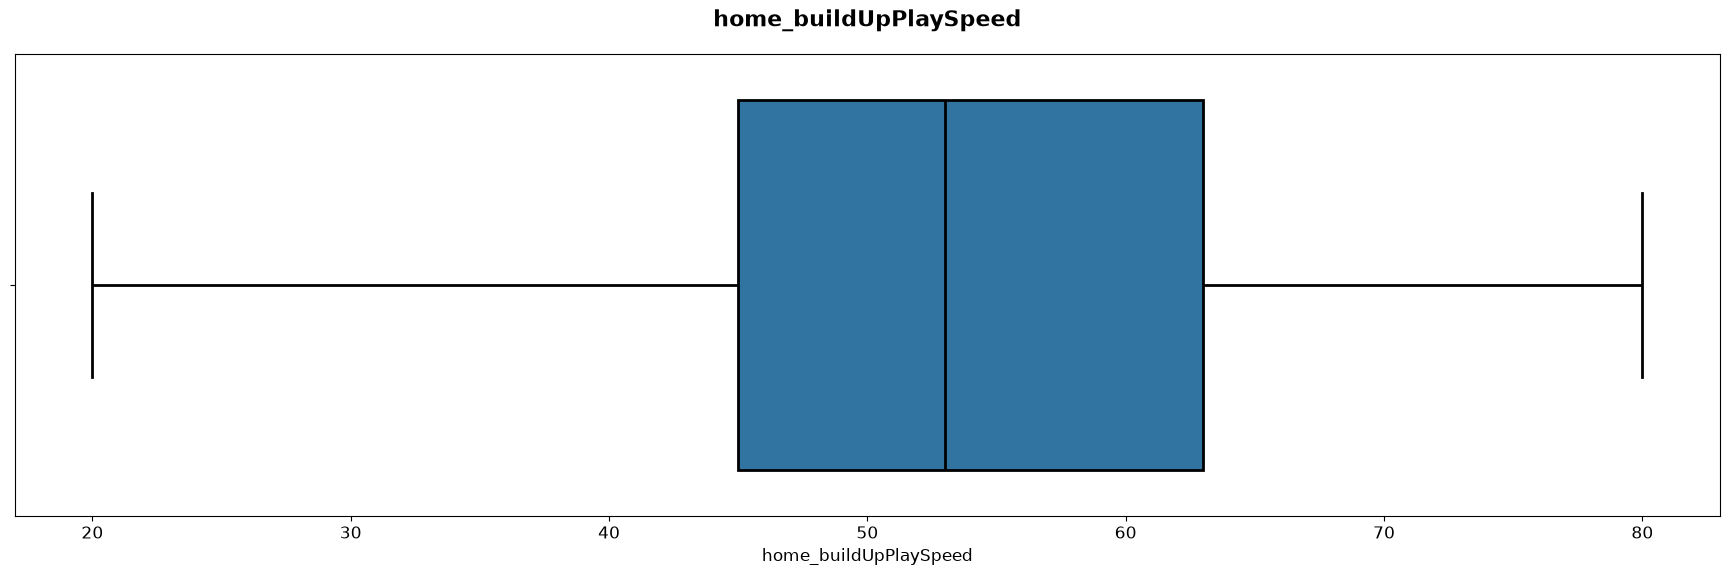

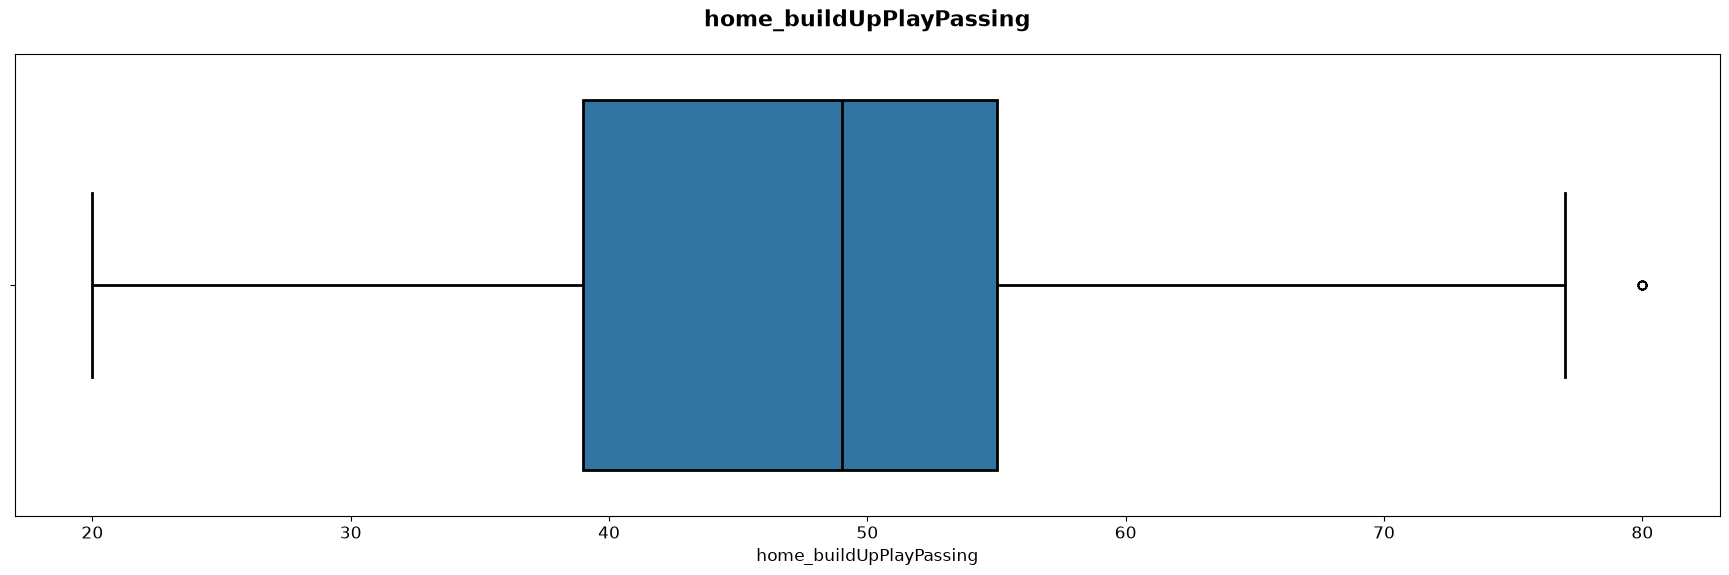

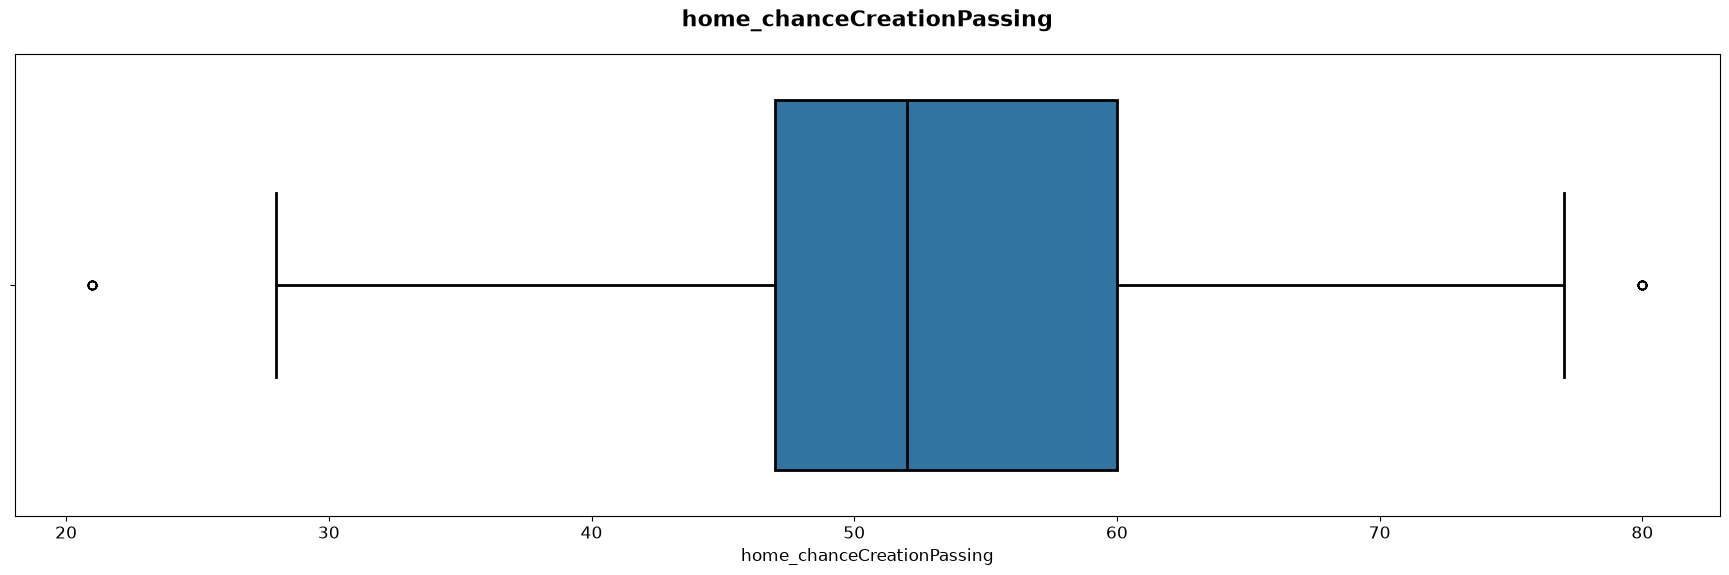

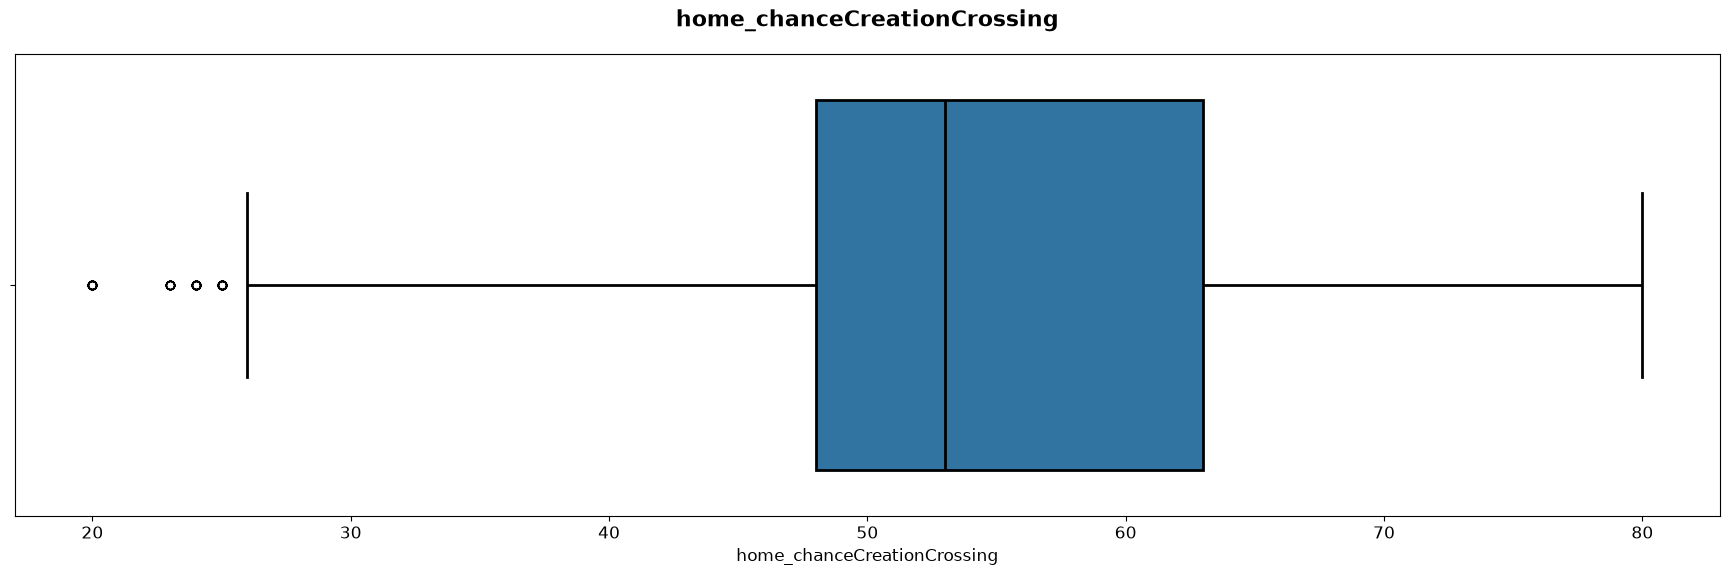

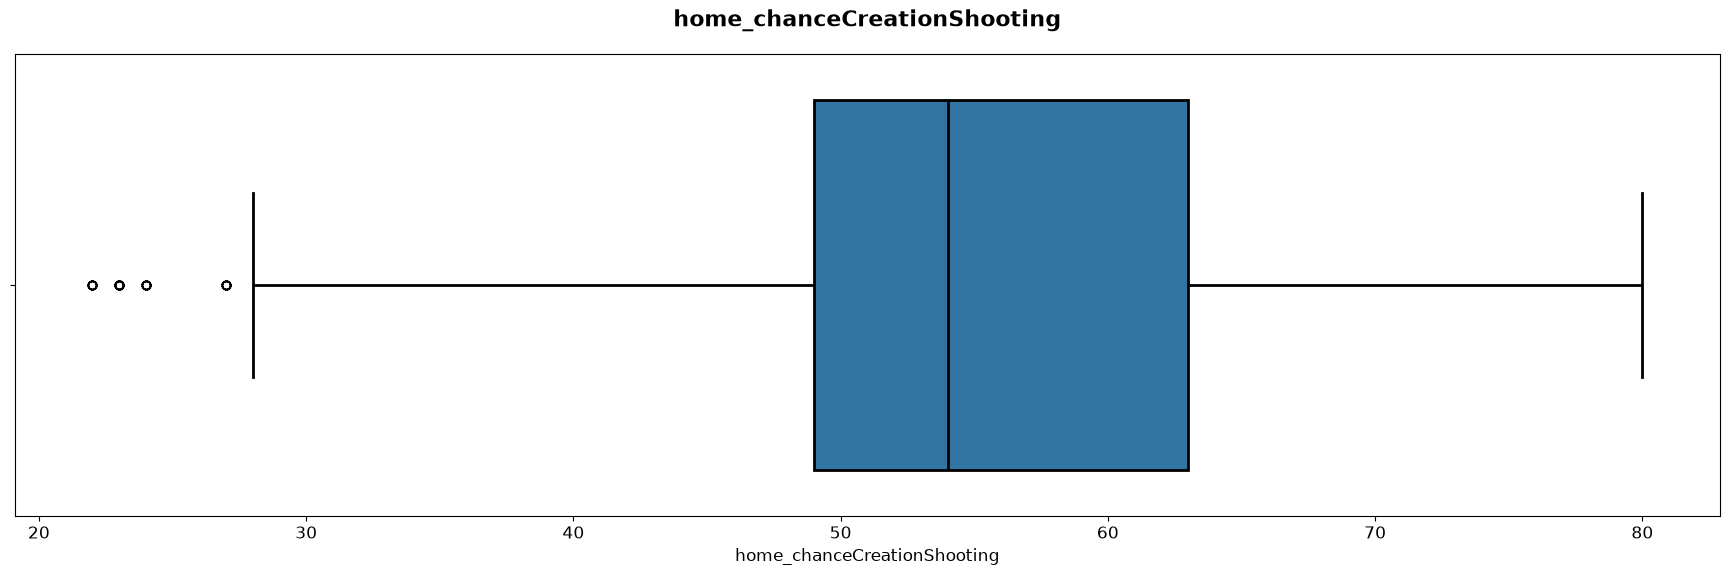

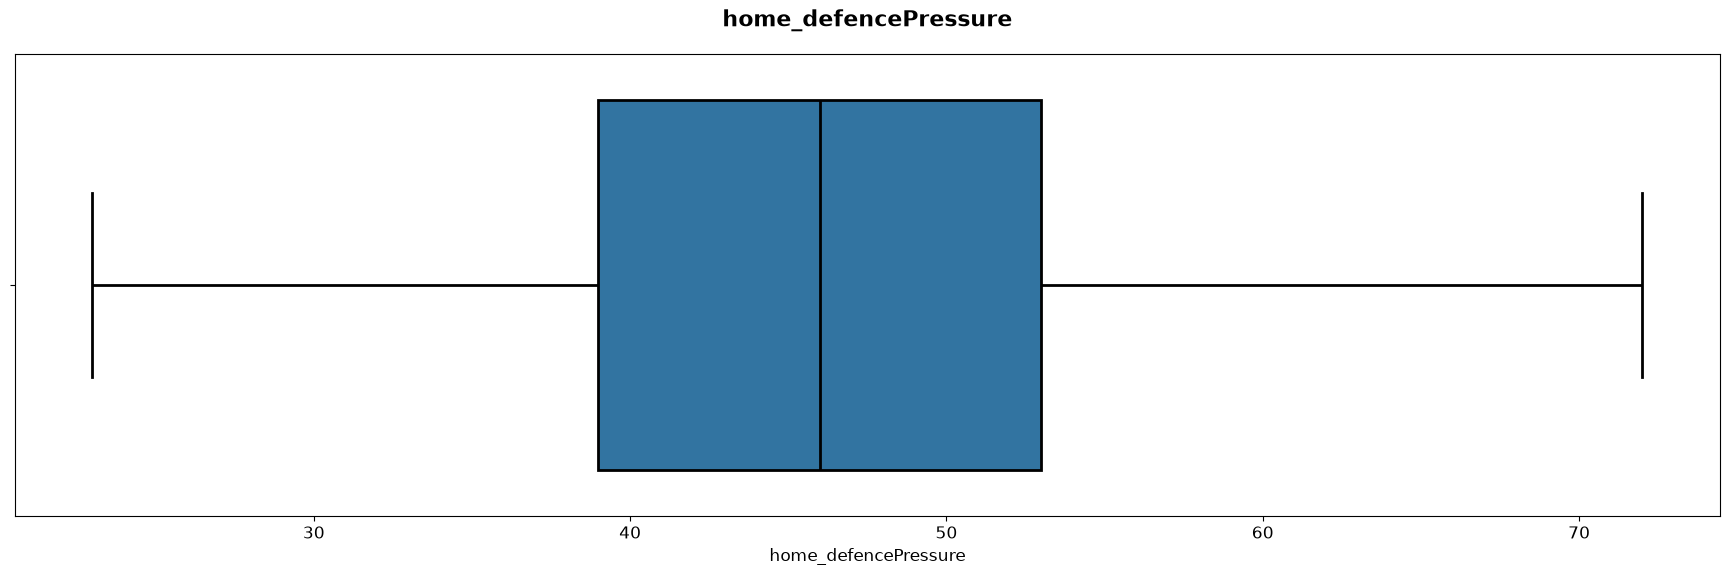

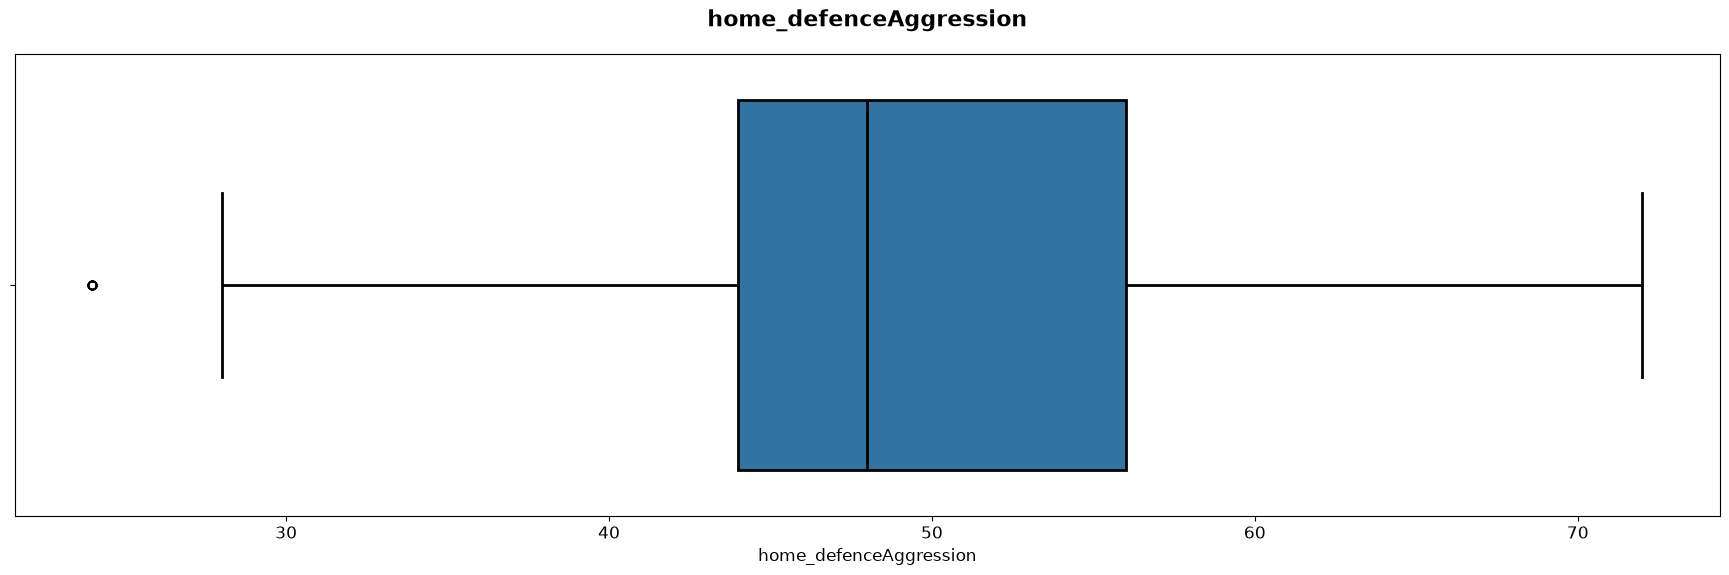

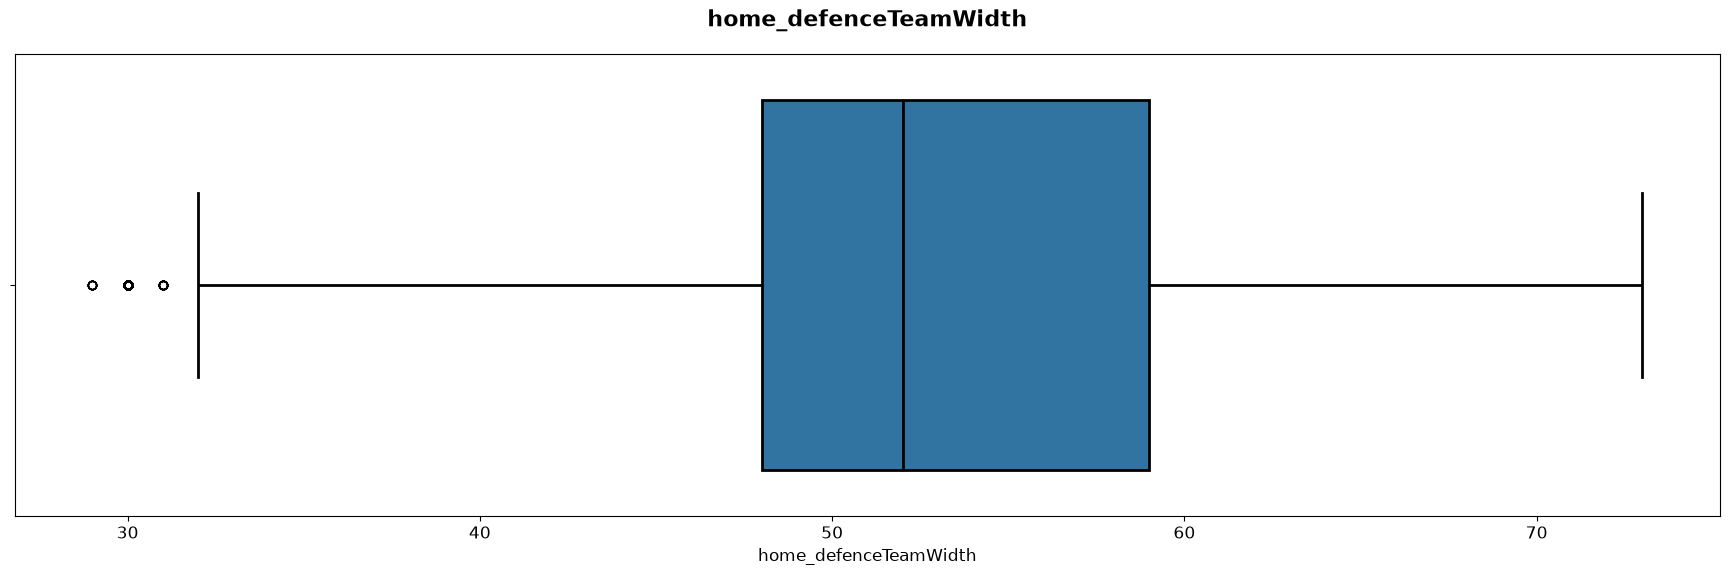

In [183]:
for col in num_col:
    plt.figure(figsize=(22,6))
    sns.boxplot(data=data, x=col, linewidth=2, linecolor="black")
    plt.title(col, fontsize=16, fontweight="bold", pad=20)
    plt.xlabel(col, fontsize=12)
    plt.tick_params(axis="x", labelsize=12, color="black")
    plt.show()

#### Evaluation

The numerical features show a reasonable spread. A few mild outliers are present, but none appear extreme enough to justify removal at this stage.

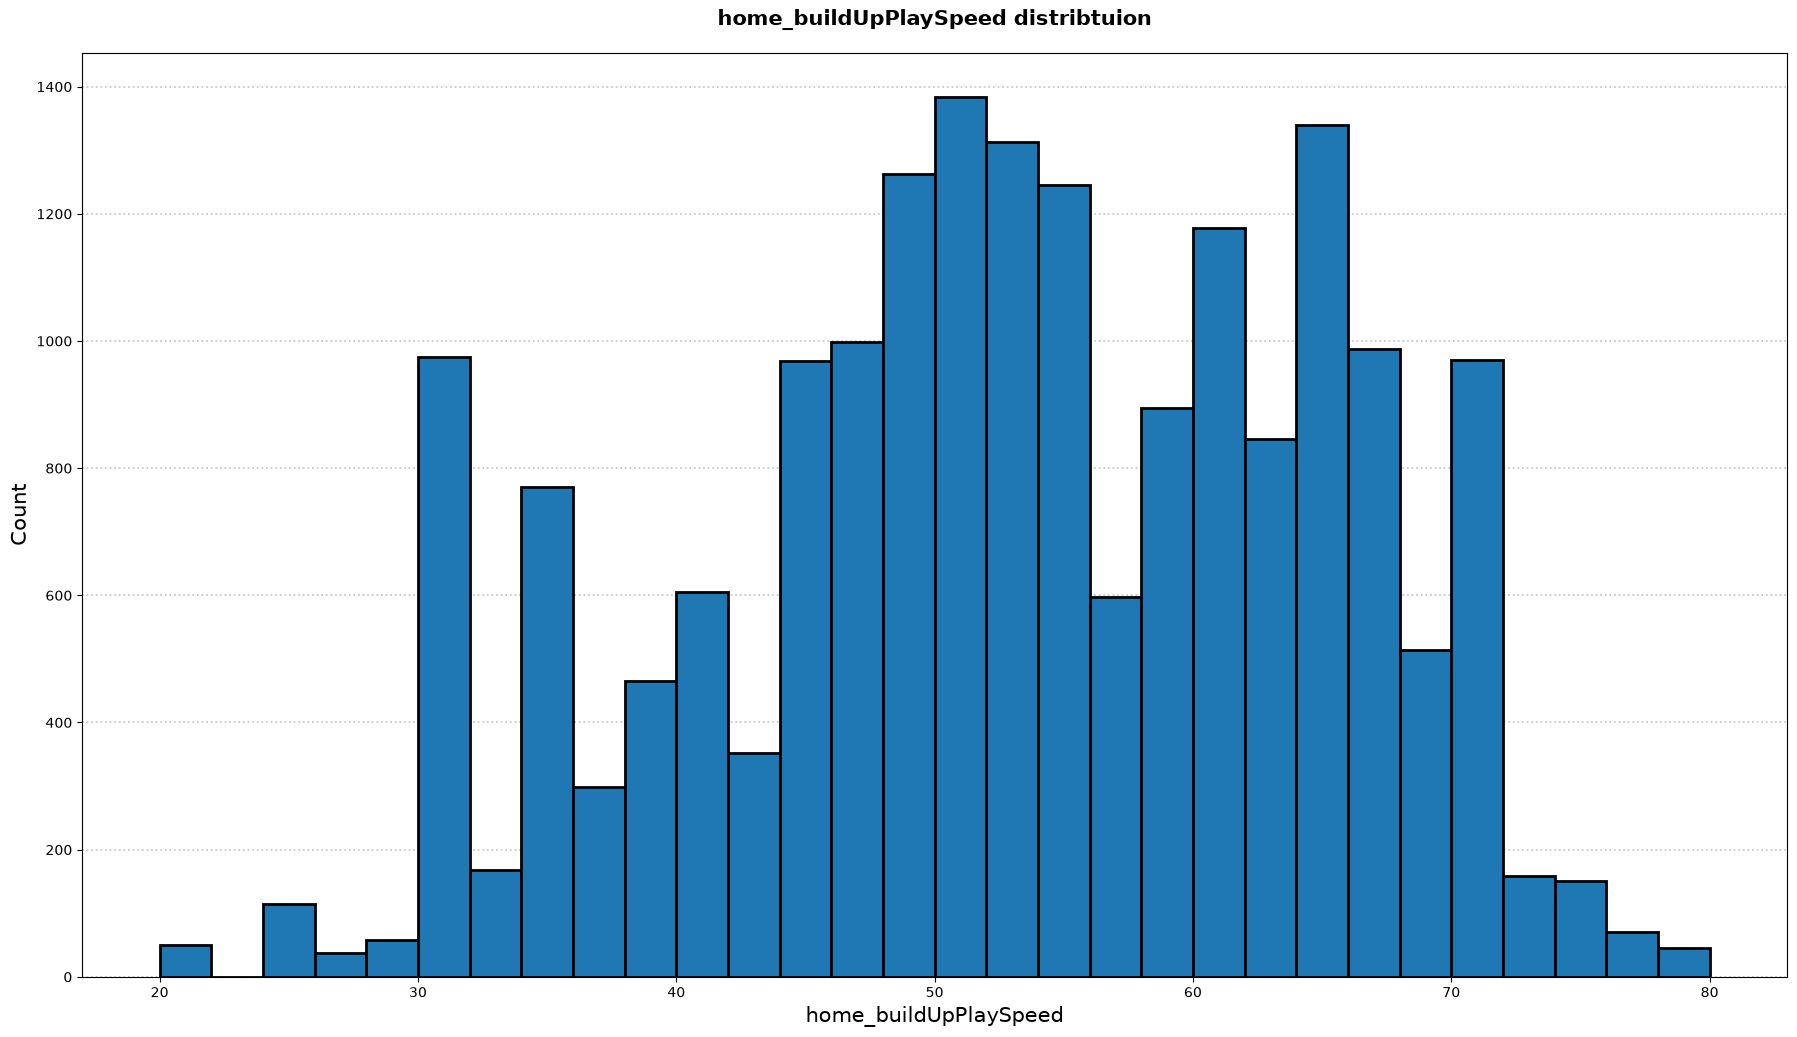

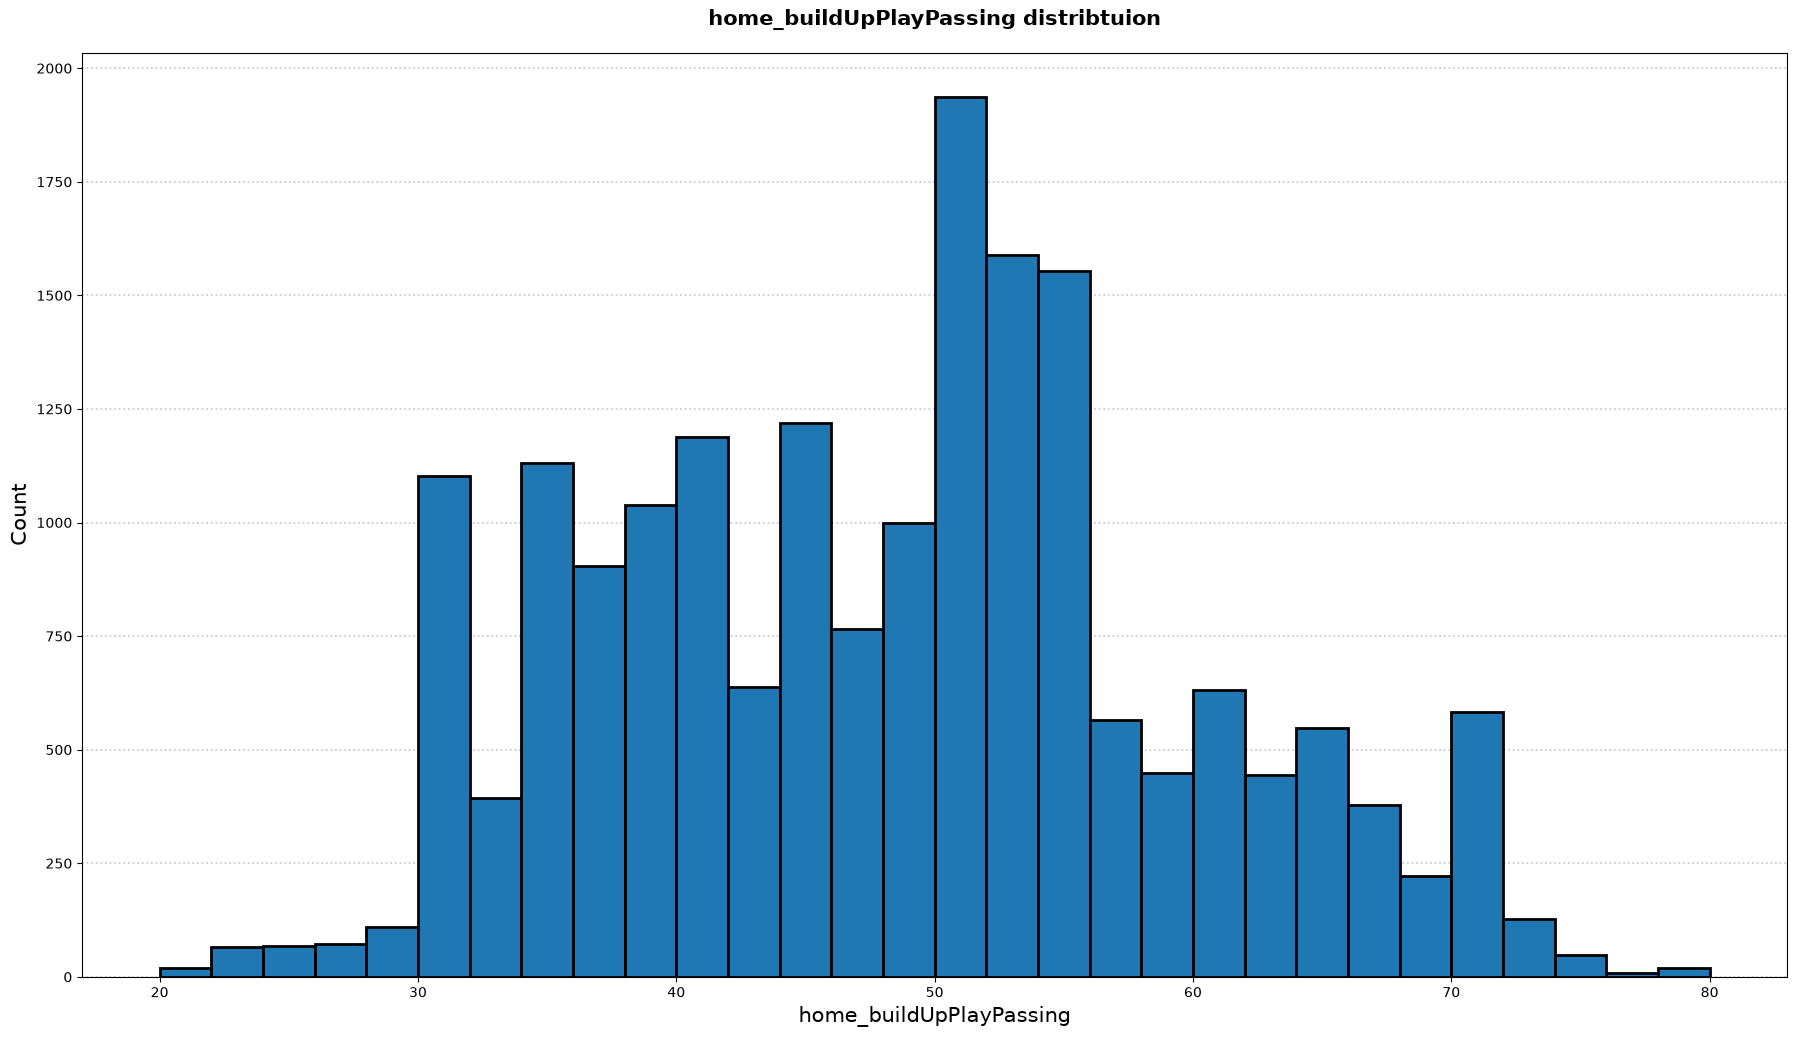

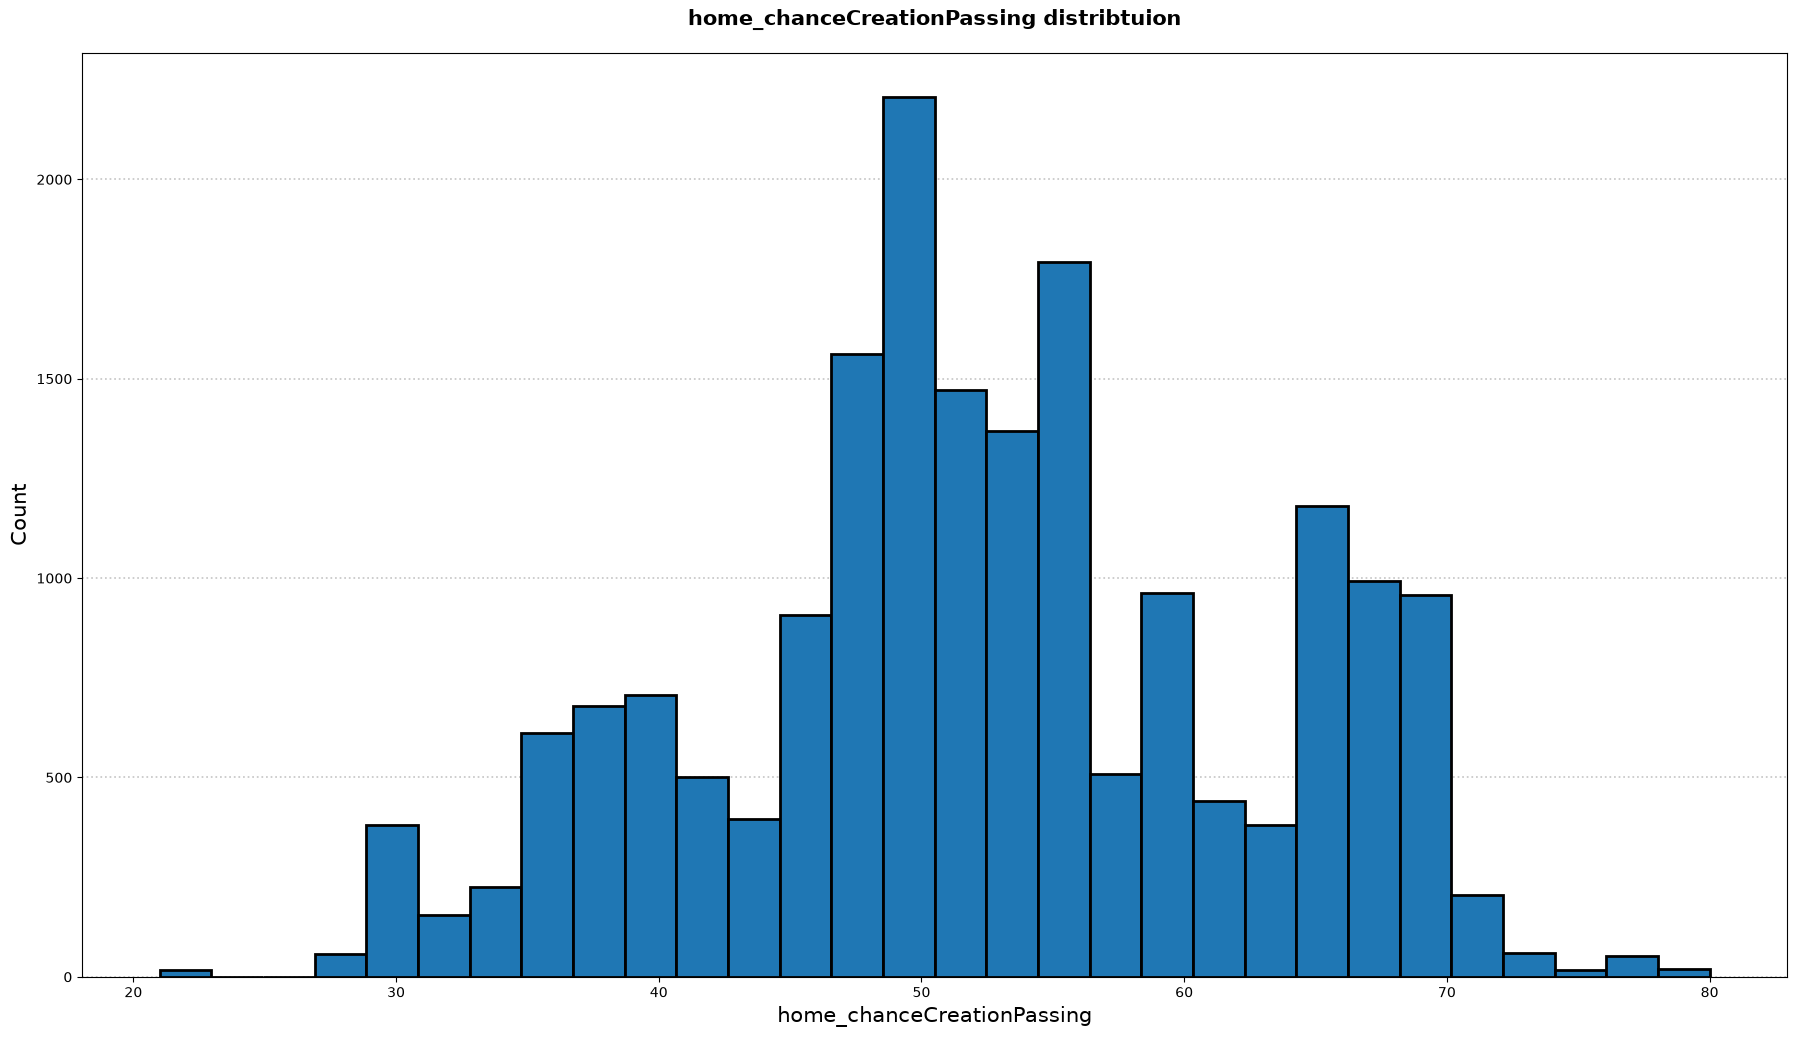

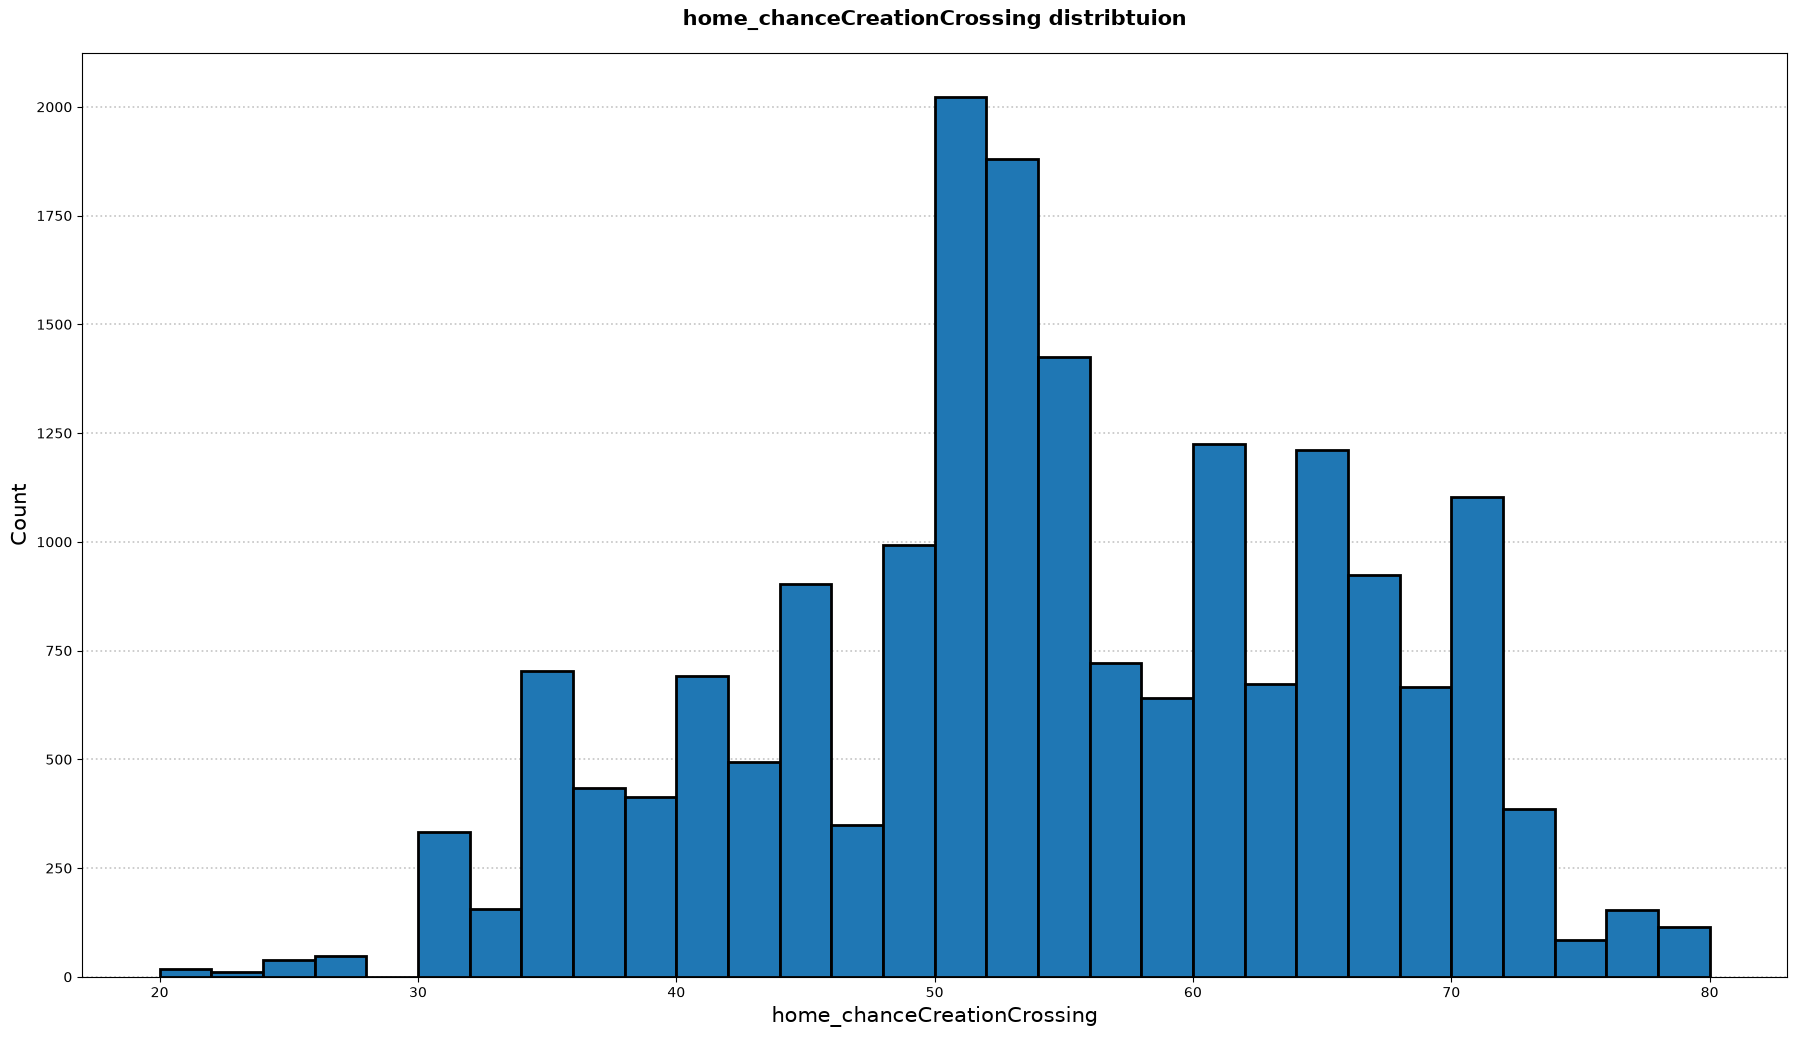

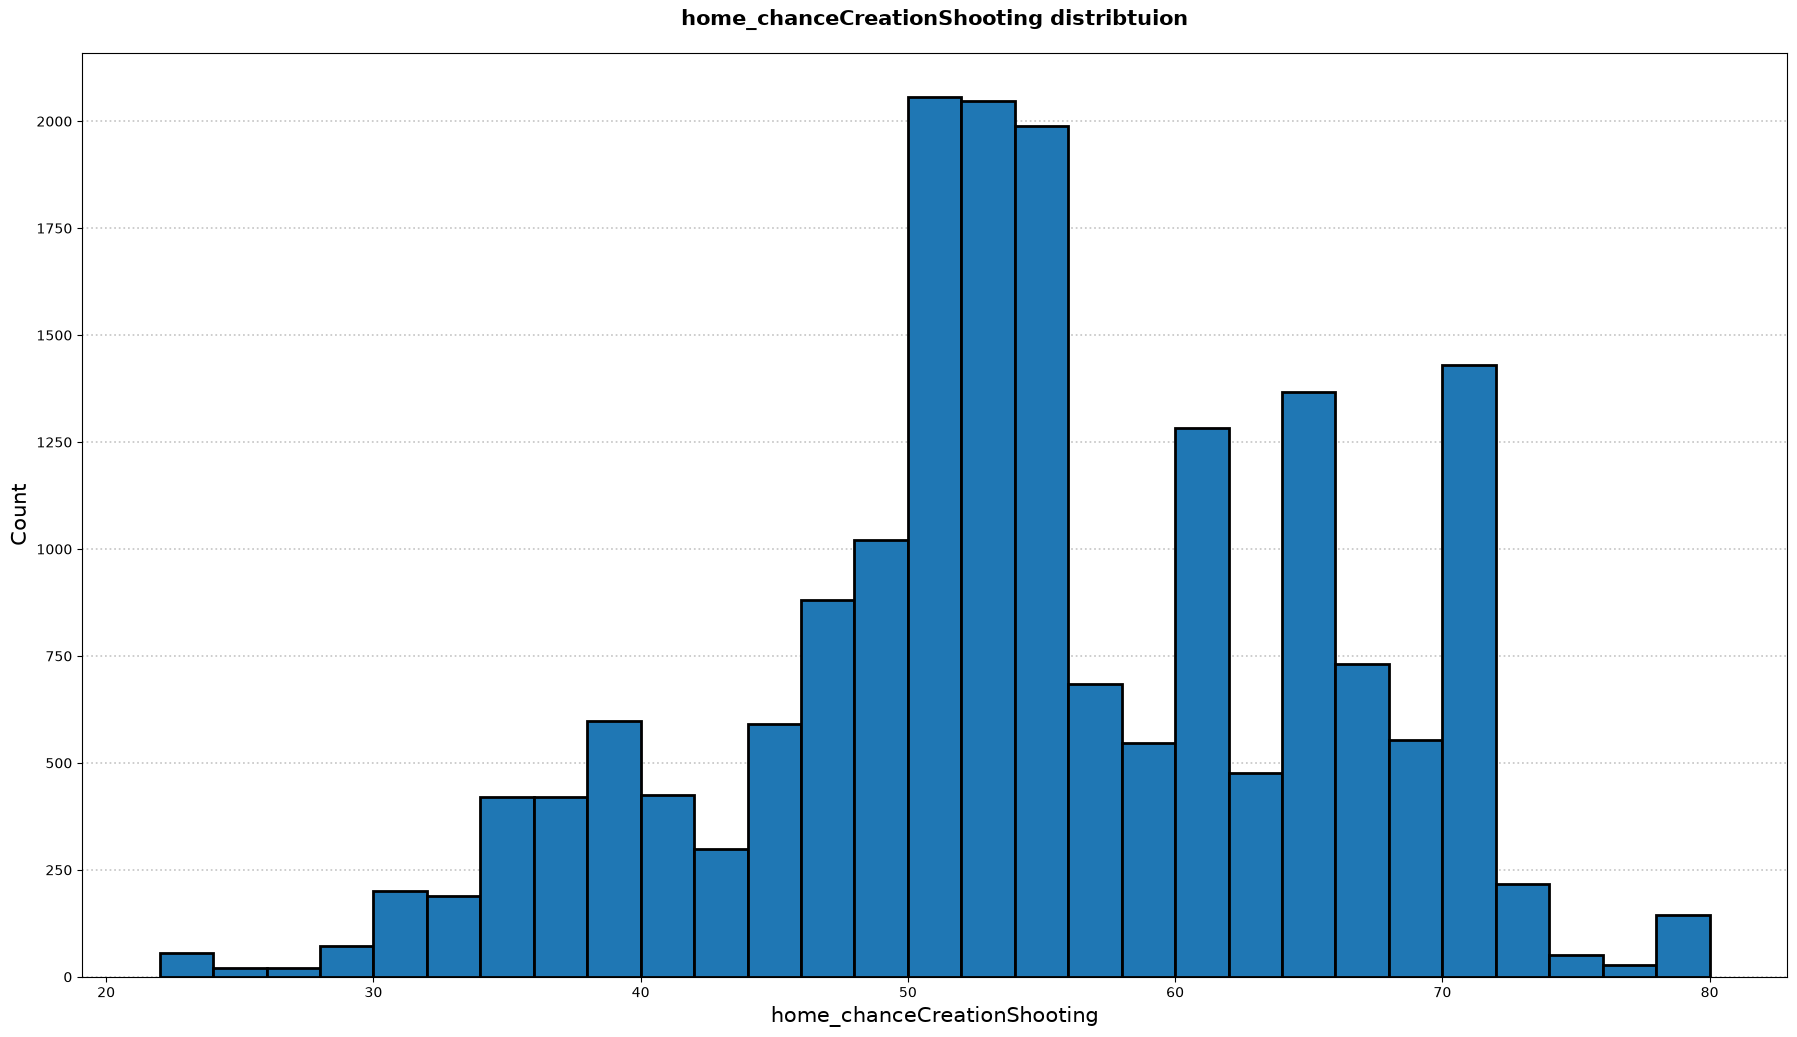

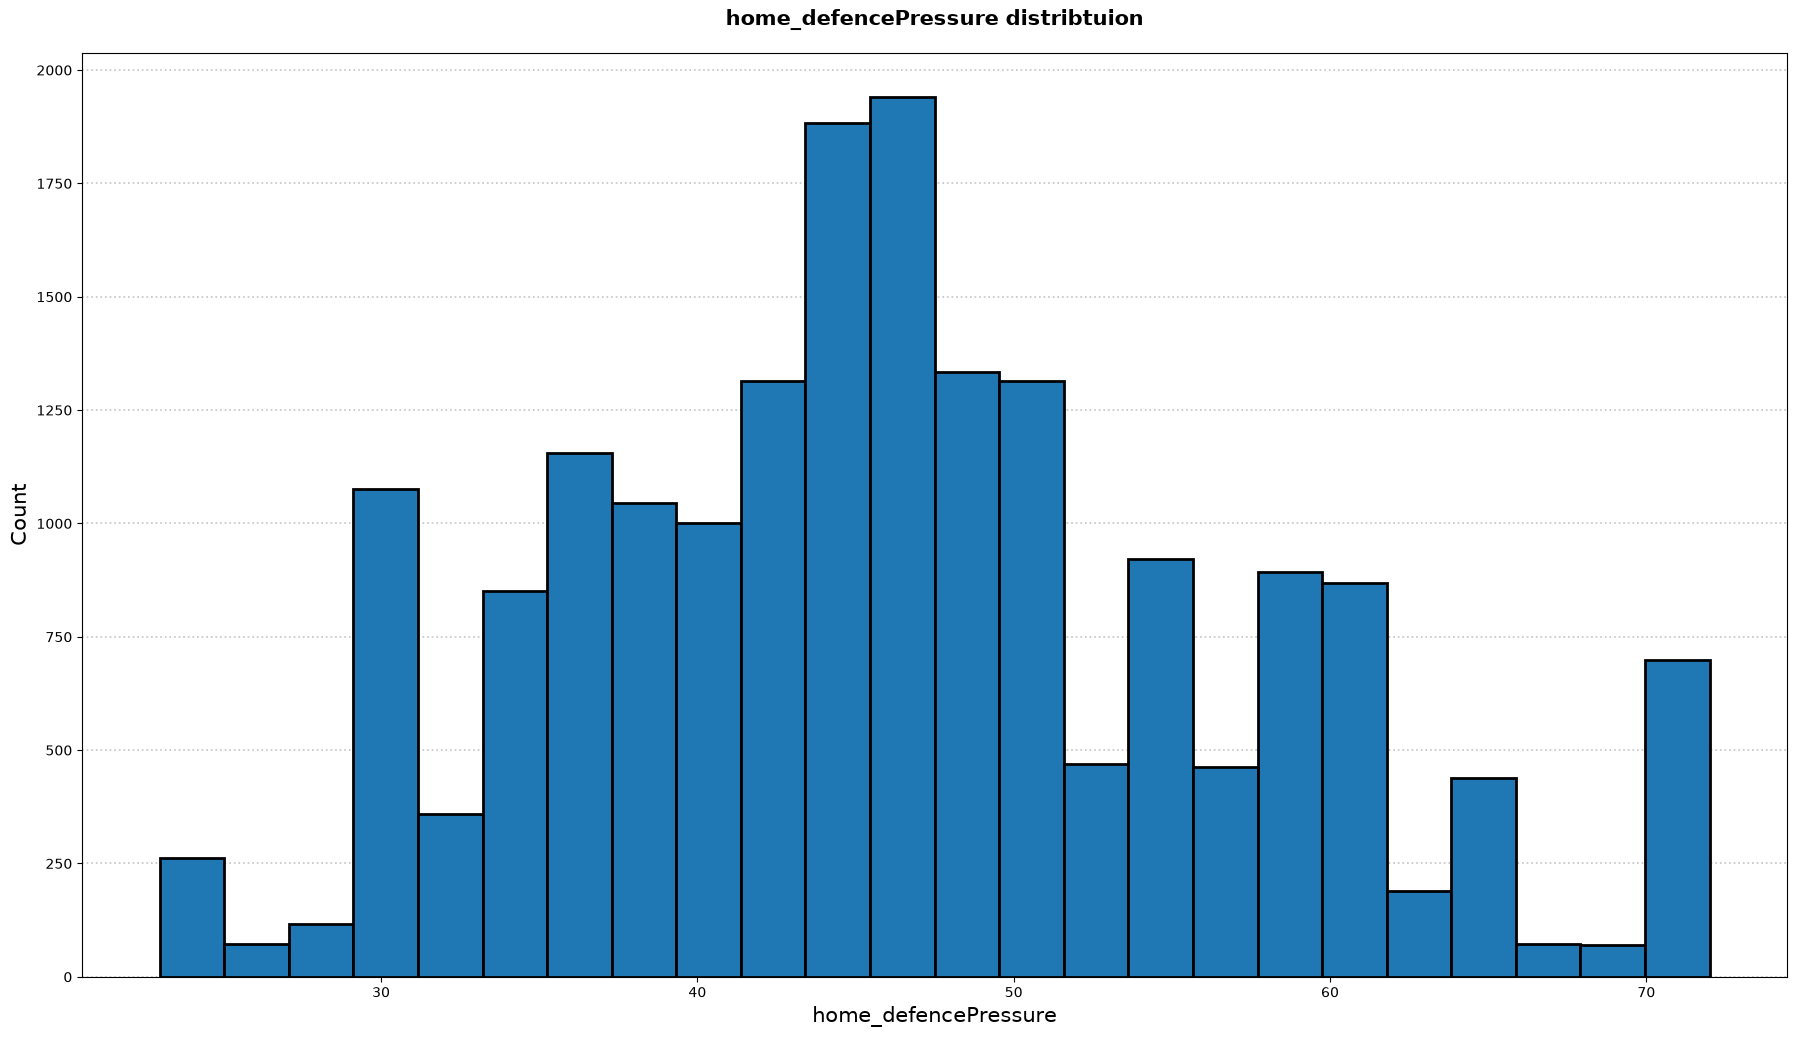

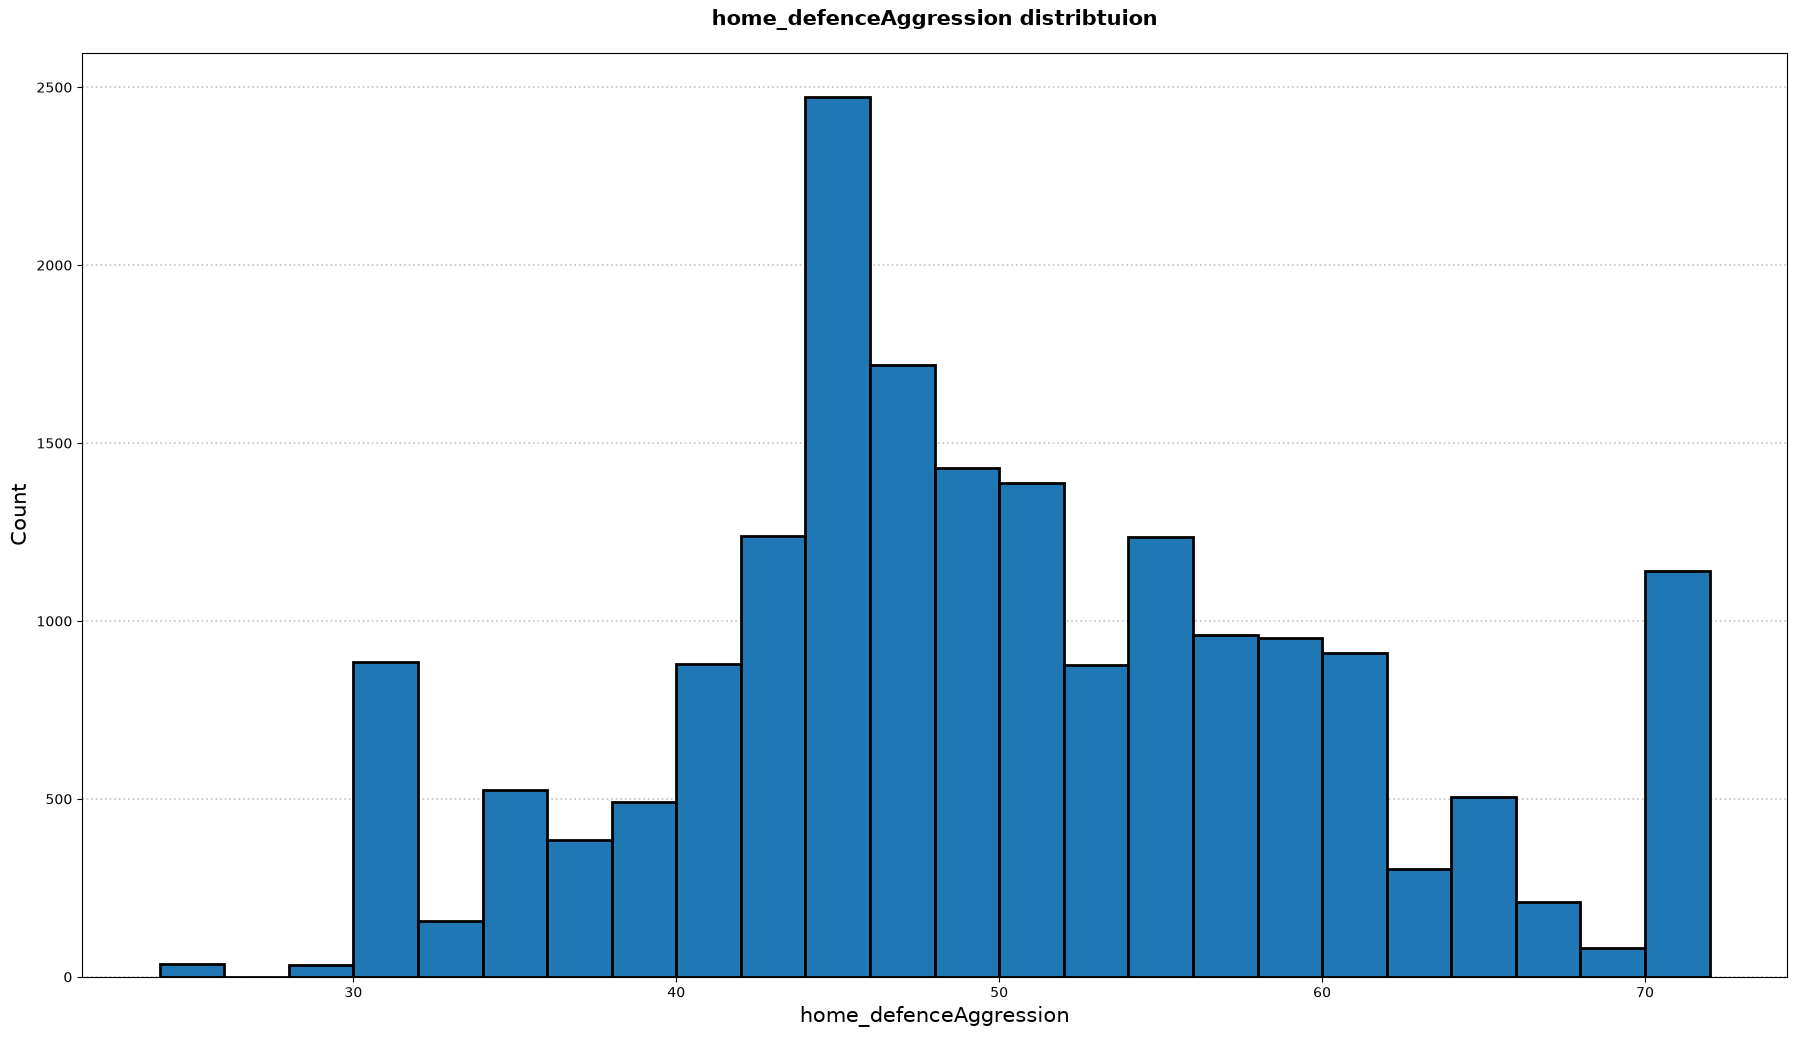

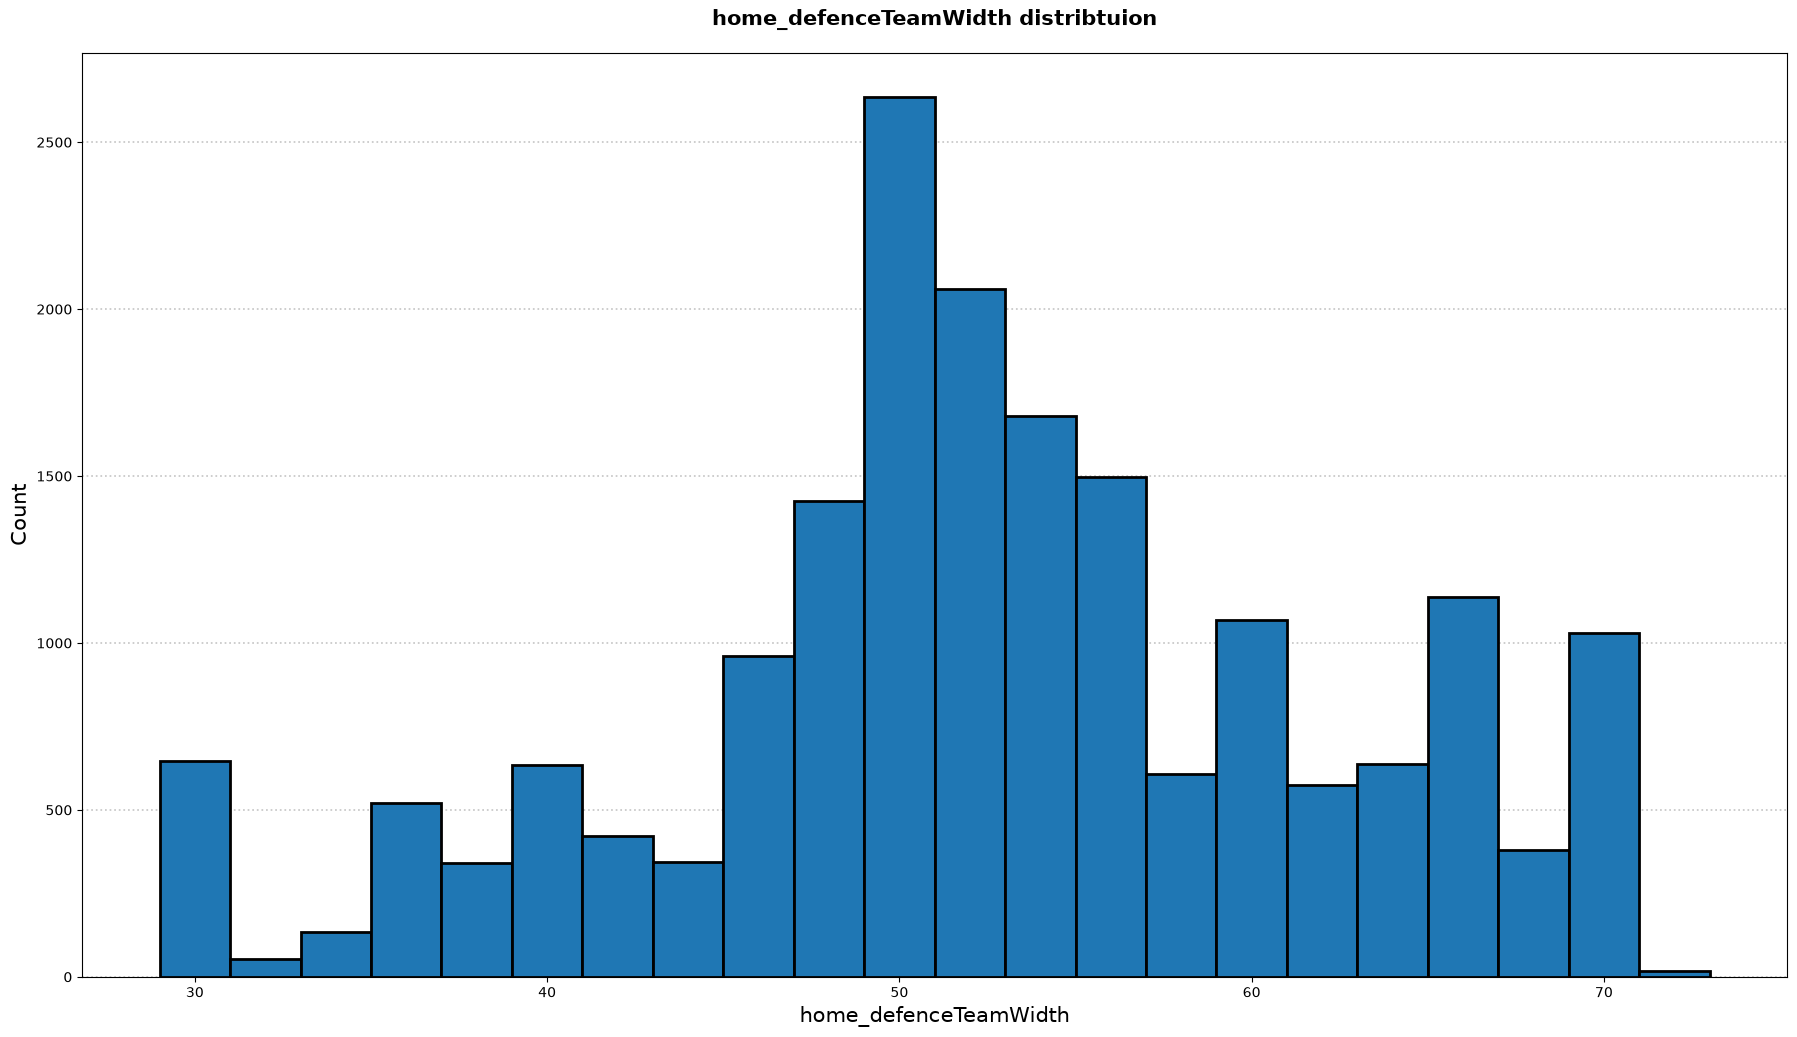

In [186]:
for col in num_col:
    plt.figure(figsize=(22,12))
    sns.histplot(data=data, x=col, linewidth=2, binwidth=2, alpha=1)
    plt.title(f"{col} distribtuion", fontsize=15, fontweight='bold', pad=20)
    plt.xlabel(col, fontsize=15)
    plt.ylabel('Count', fontsize=15)
    plt.rcParams['axes.axisbelow']=True
    plt.grid(True, axis='y', linestyle=':', linewidth=1.25, alpha=0.7)
    plt.show()

#### Evaluation
The numerical features show no strong skewness or extreme distribution problems. Although some distributions are uneven, there is currently no clear reason to transform or remove them before modelling.

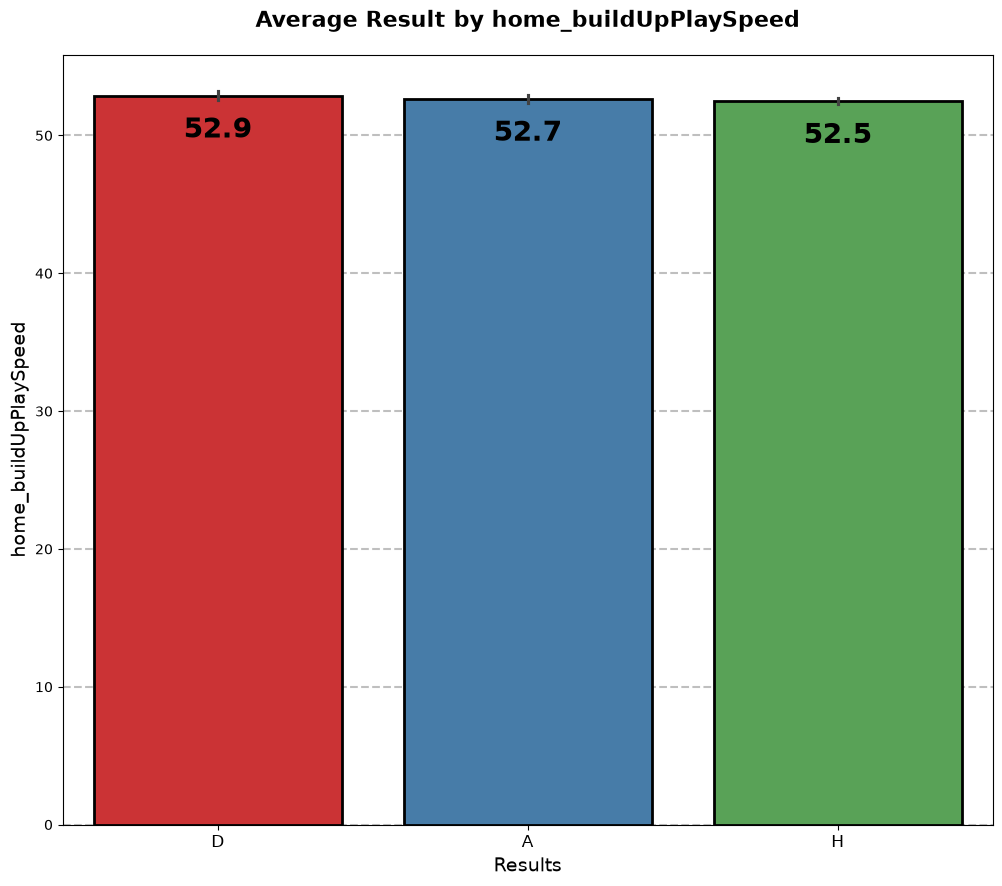

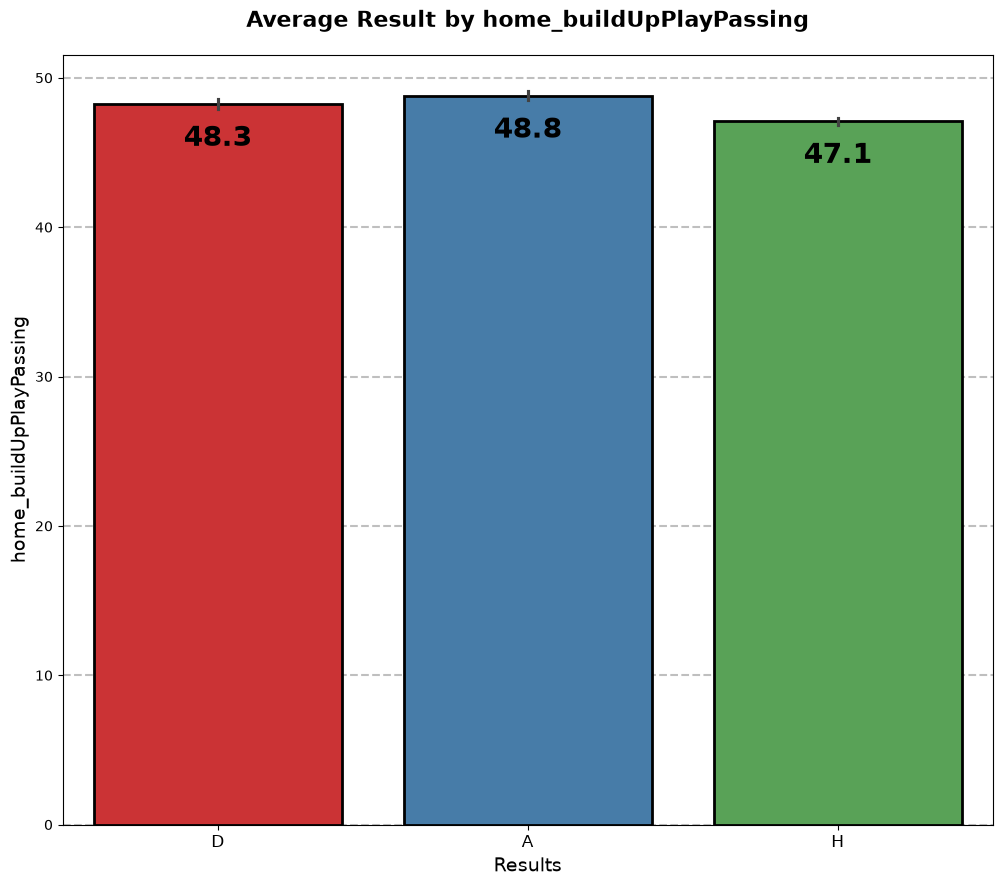

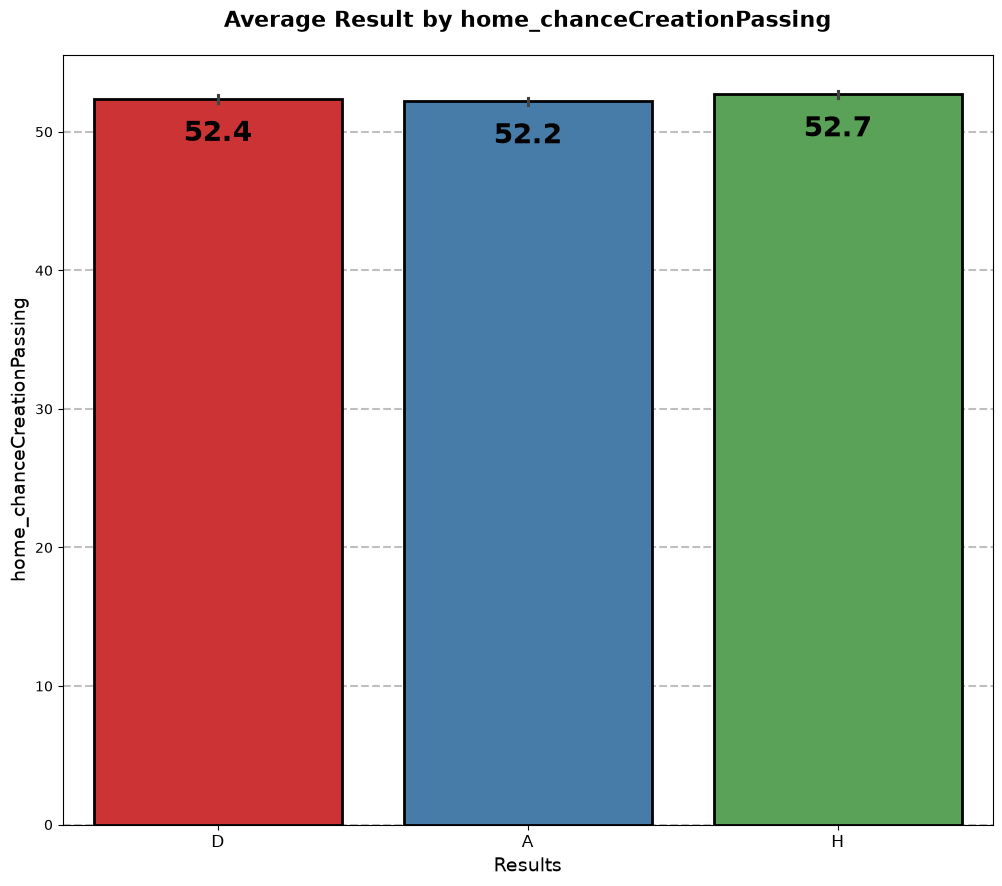

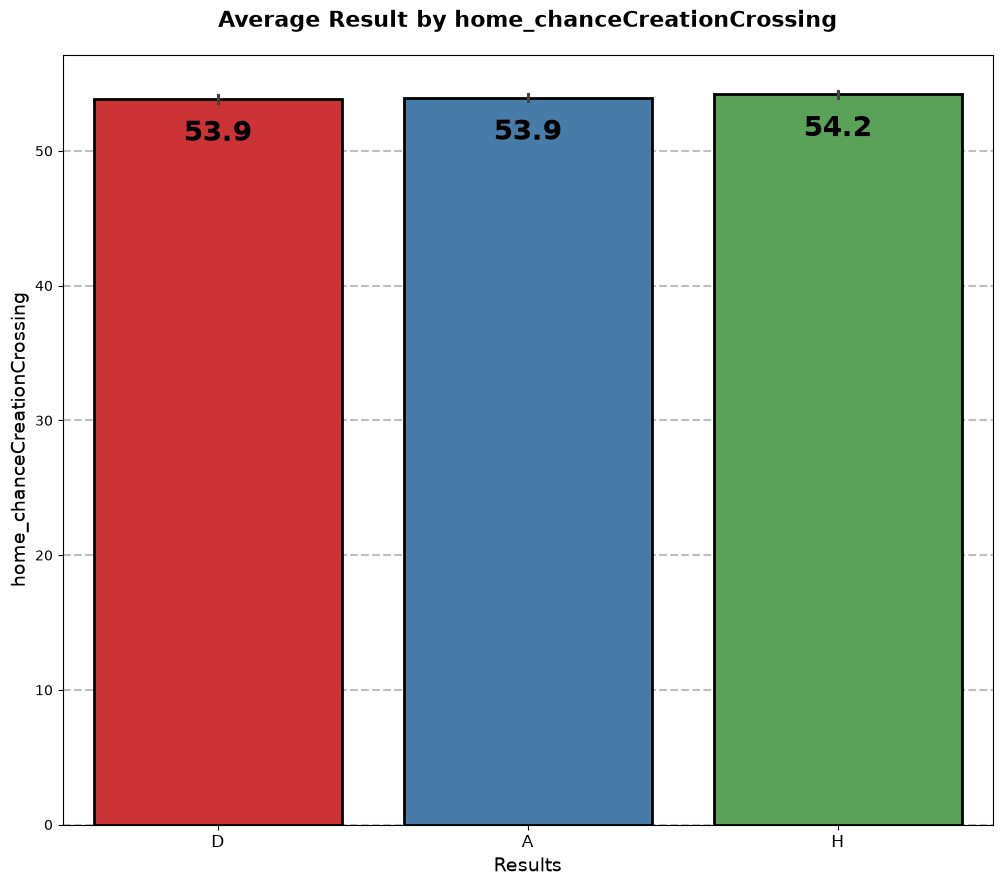

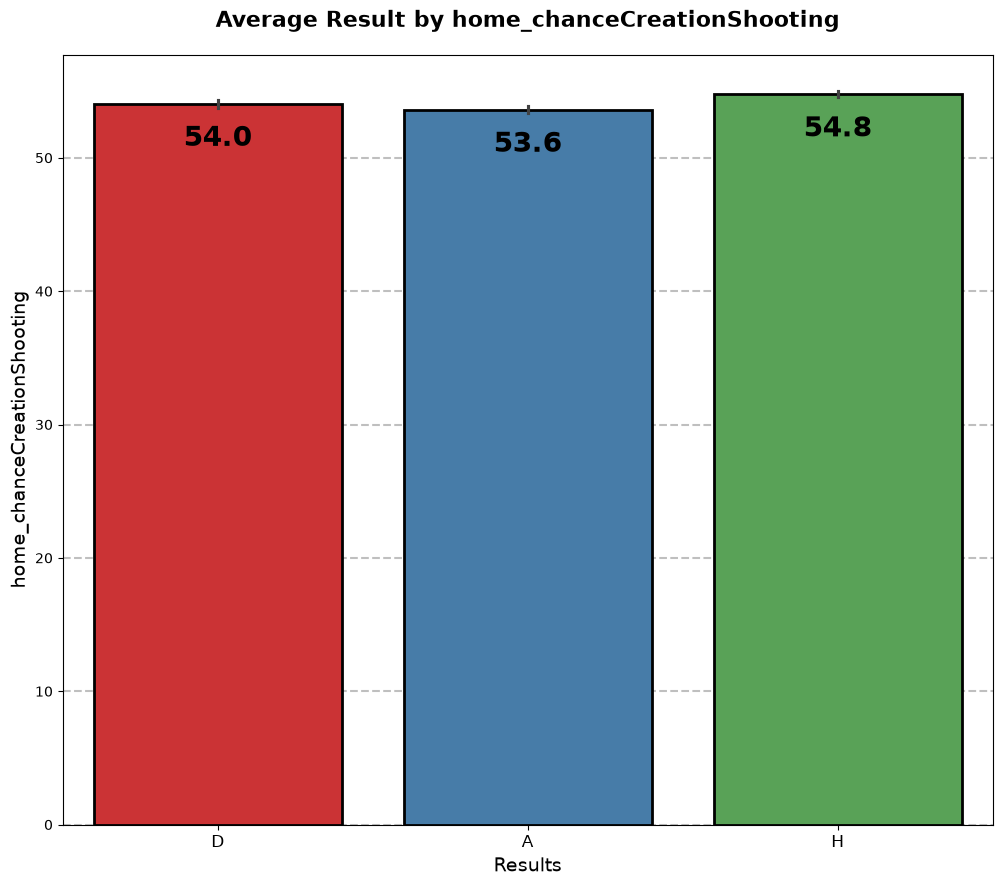

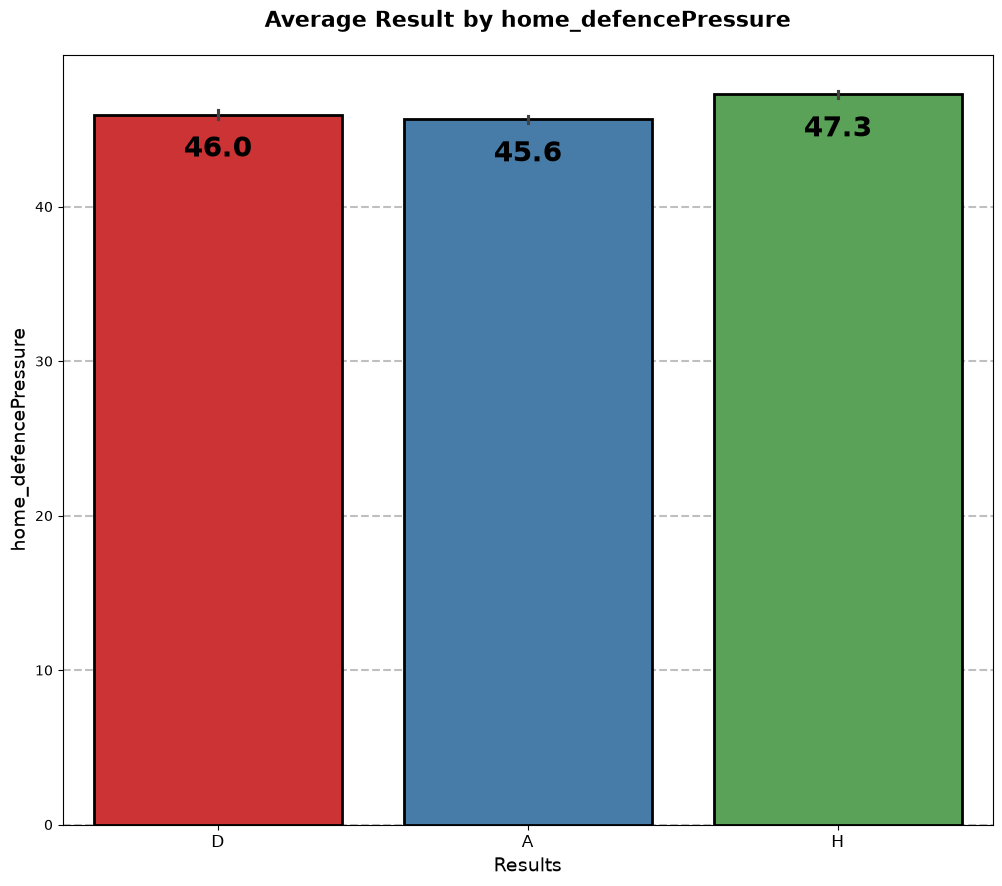

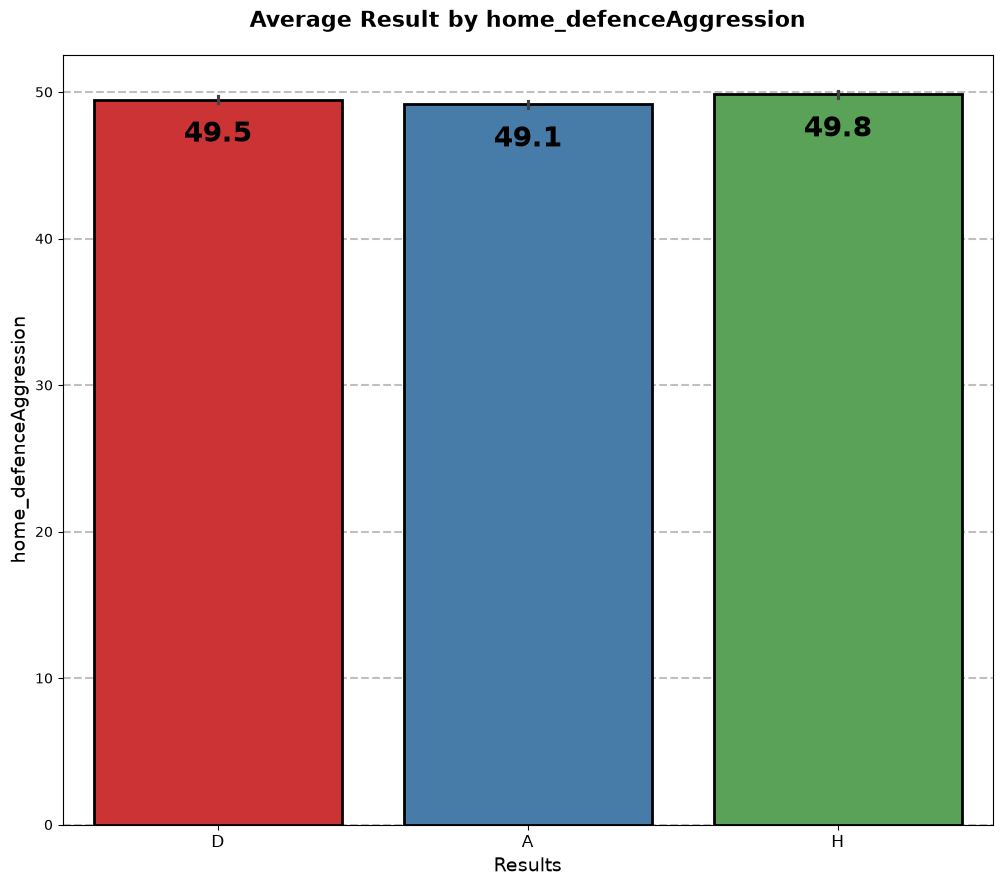

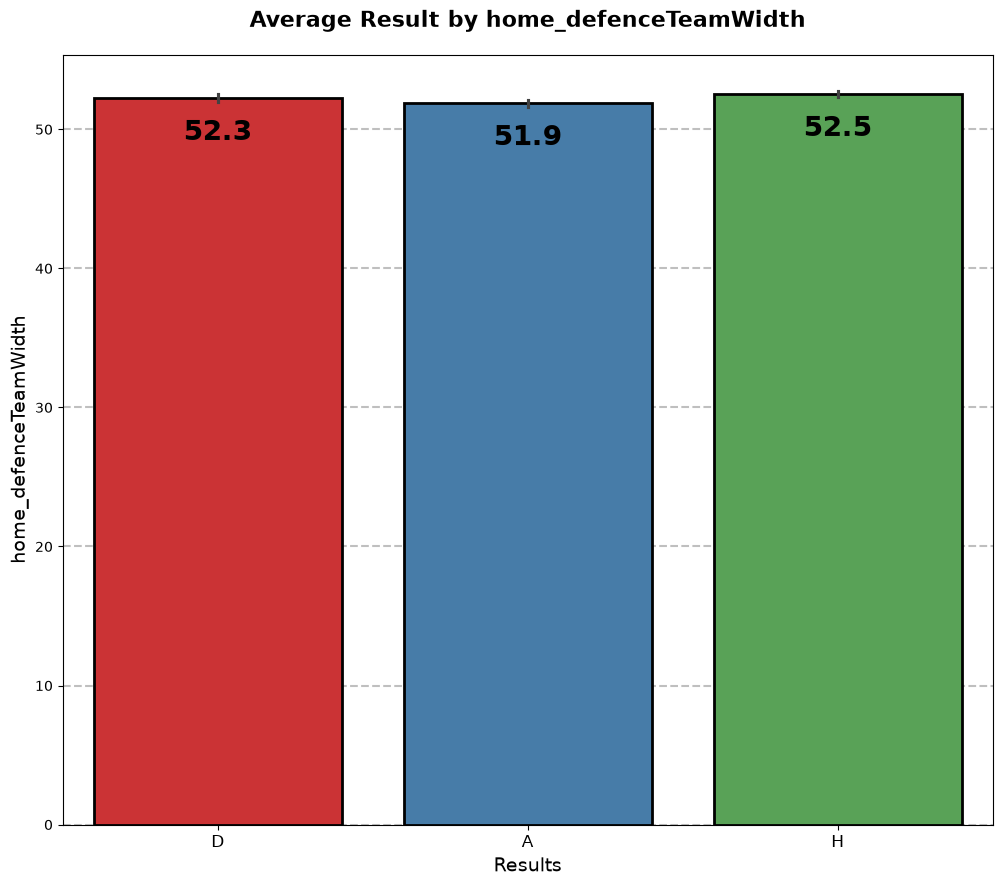

In [188]:
for col in num_col:
    plt.figure(figsize=(12,10))
    ax0=sns.barplot(data=data, x='FTR', y=col, hue='FTR', palette='Set1', linewidth=2 ,edgecolor='black')
    plt.title(f'Average Result by {col}', fontsize=16, fontweight='bold', pad=20)
    ax0.set_axisbelow(True)
    plt.grid(True, axis='y', linestyle='--', linewidth=1.5, alpha=0.8)
    plt.tick_params(axis='x', labelsize=12, color='black')
    plt.xlabel('Results', fontsize=14)
    plt.ylabel(col, fontsize=14)
    for container in ax0.containers:
        plt.bar_label(container,fmt='%.1f', label_type='edge', fontweight='bold' ,fontsize=20, padding=-35)
    plt.show()

#### Evaluation
The mean values are very similar across the three match outcomes, suggesting that these numerical Team Attributes have limited individual relationship with FTR. However, they may still provide useful information when combined, so they should be retained for further analysis.

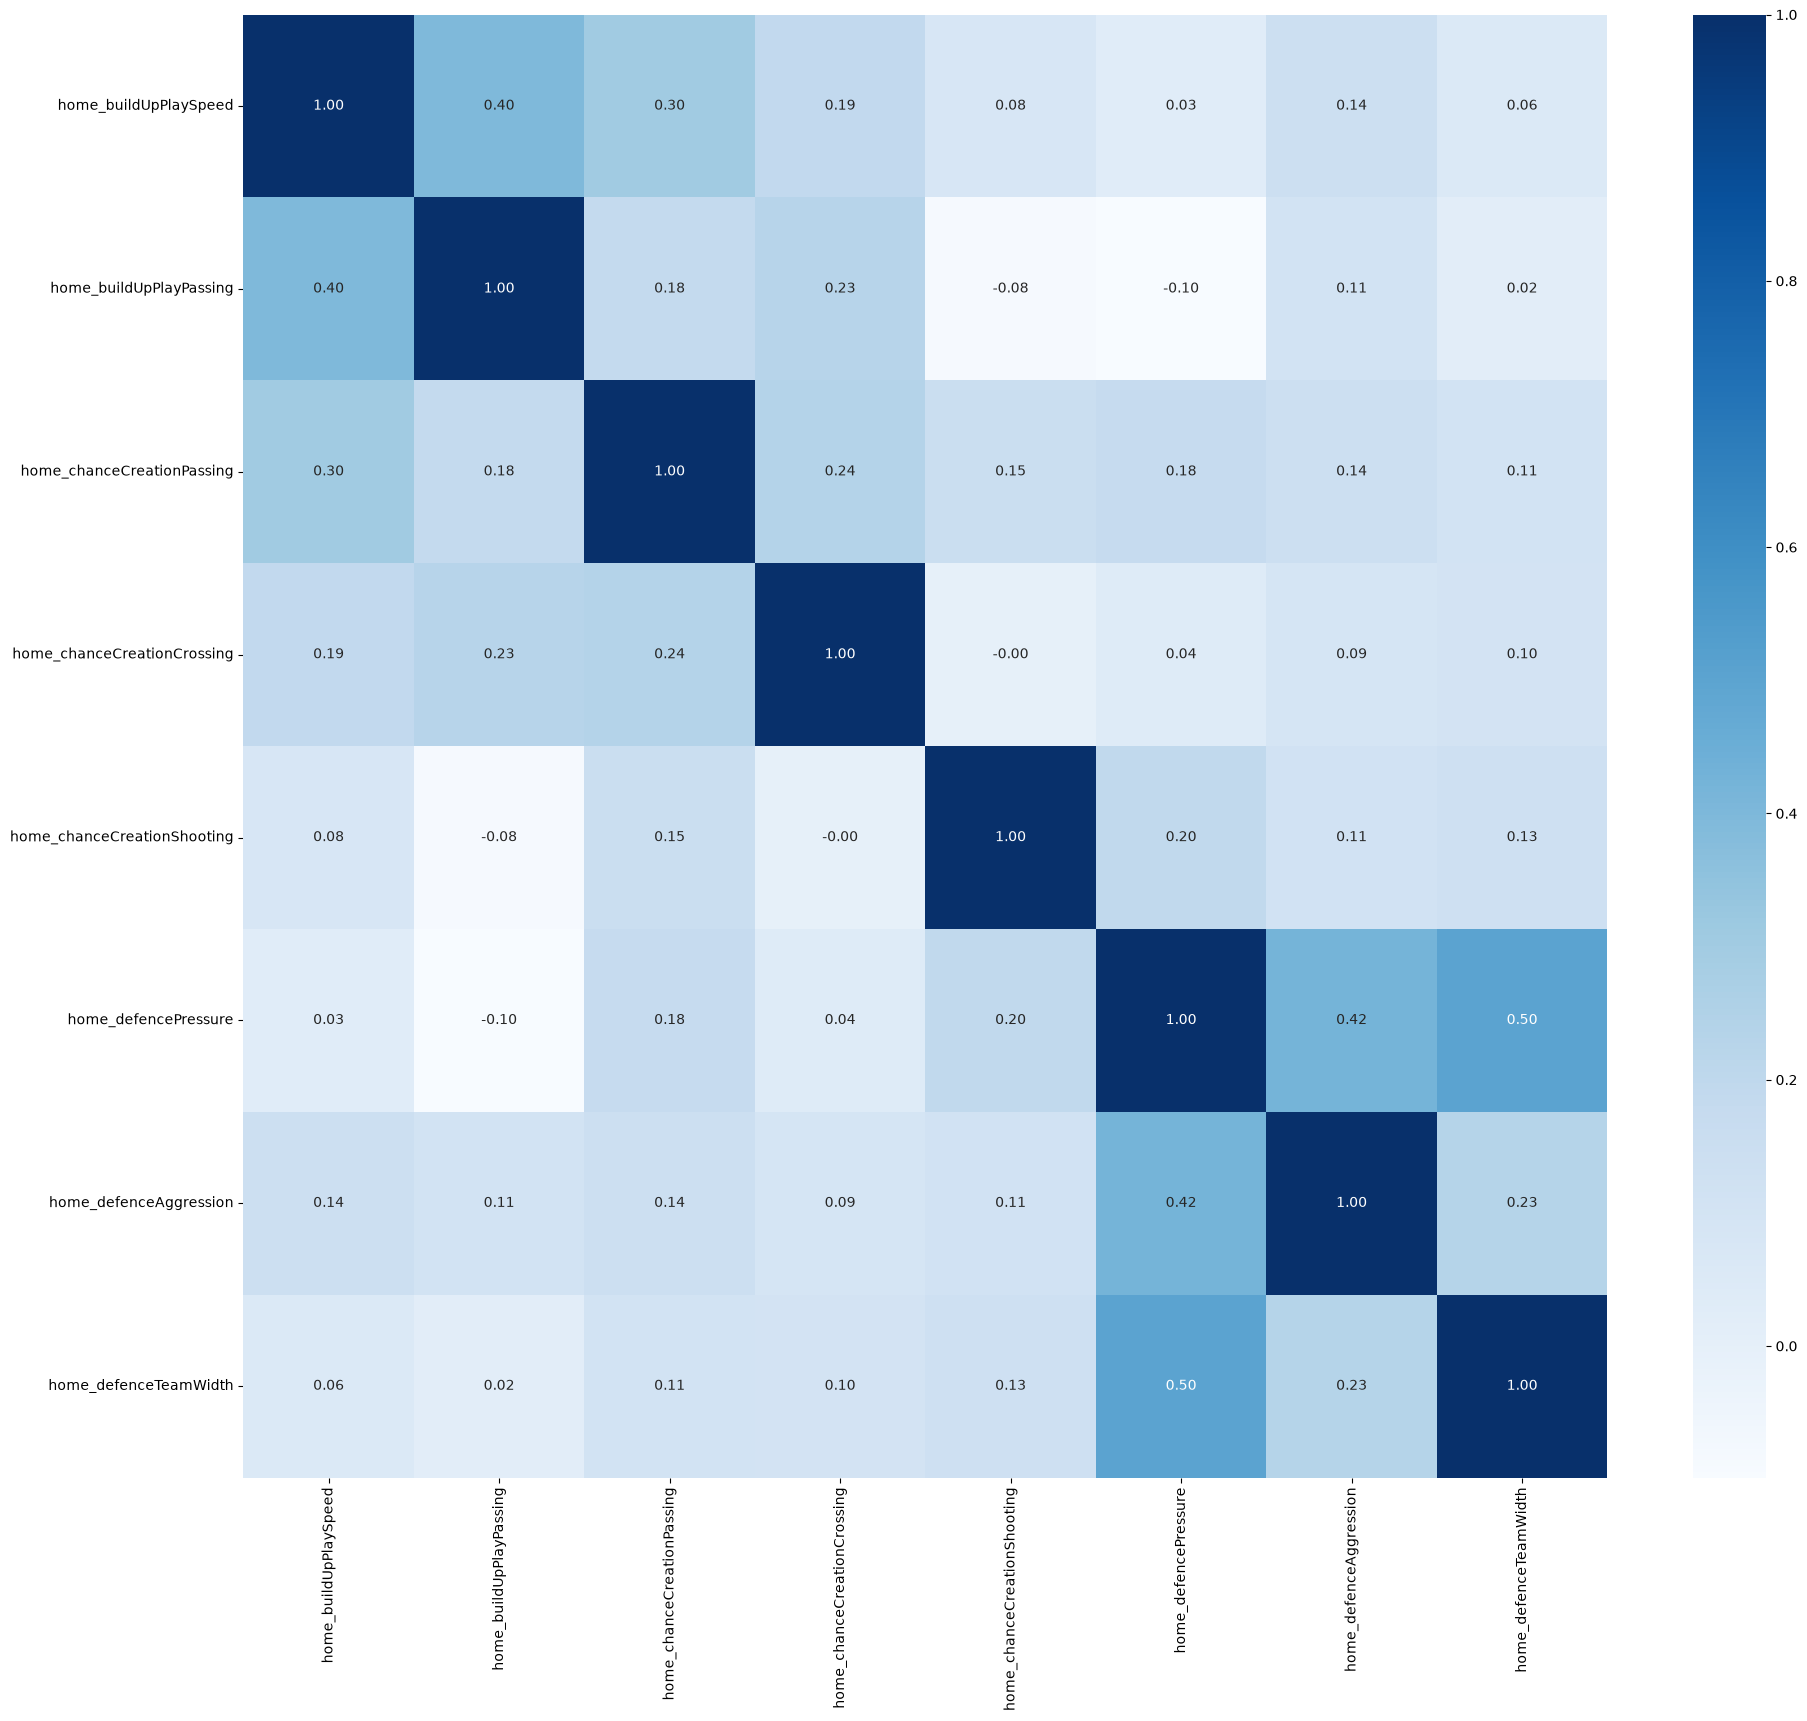

In [198]:
heatmap_col = data[num_col]
plt.figure(figsize=(22,19))
sns.heatmap(heatmap_col.corr(), annot=True, fmt=".2f", cmap="Blues")
plt.show()

### Evaluation

The heatmap shows mostly **weak to moderate correlations**, with the highest around **0.50**, so the numerical features are not heavily interconnected. Combined with the earlier `FTR` comparison, none appears strongly predictive individually, but there is no strong redundancy either. Therefore, they can be retained for modelling while we now move to the categorical attributes.

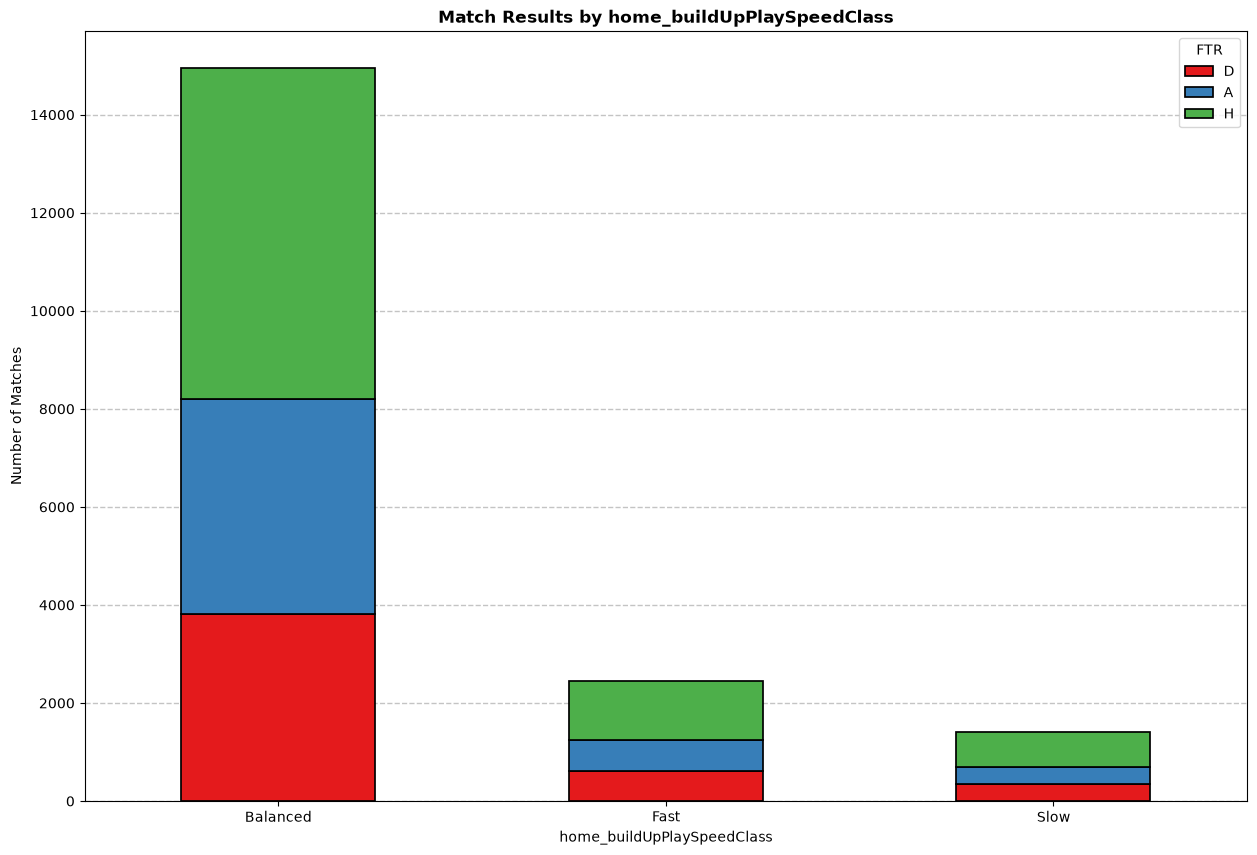

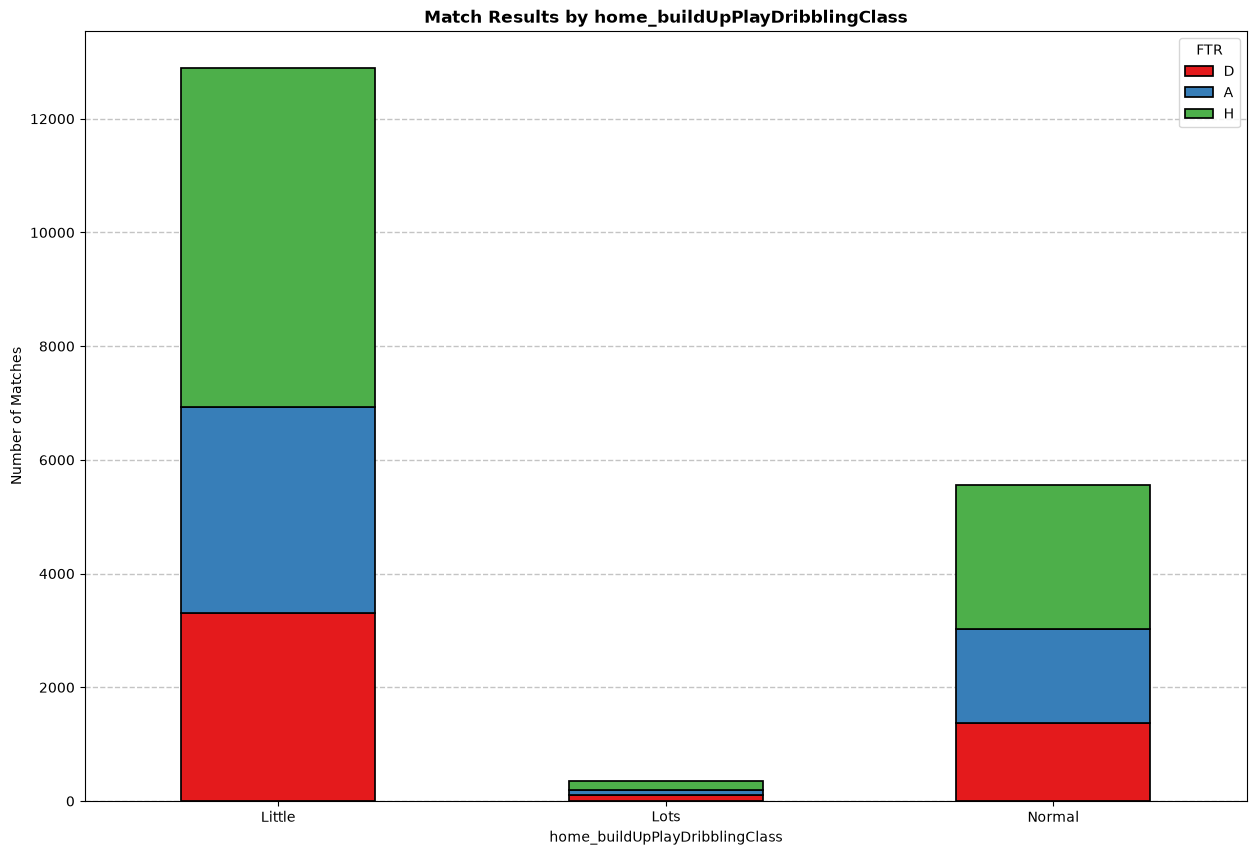

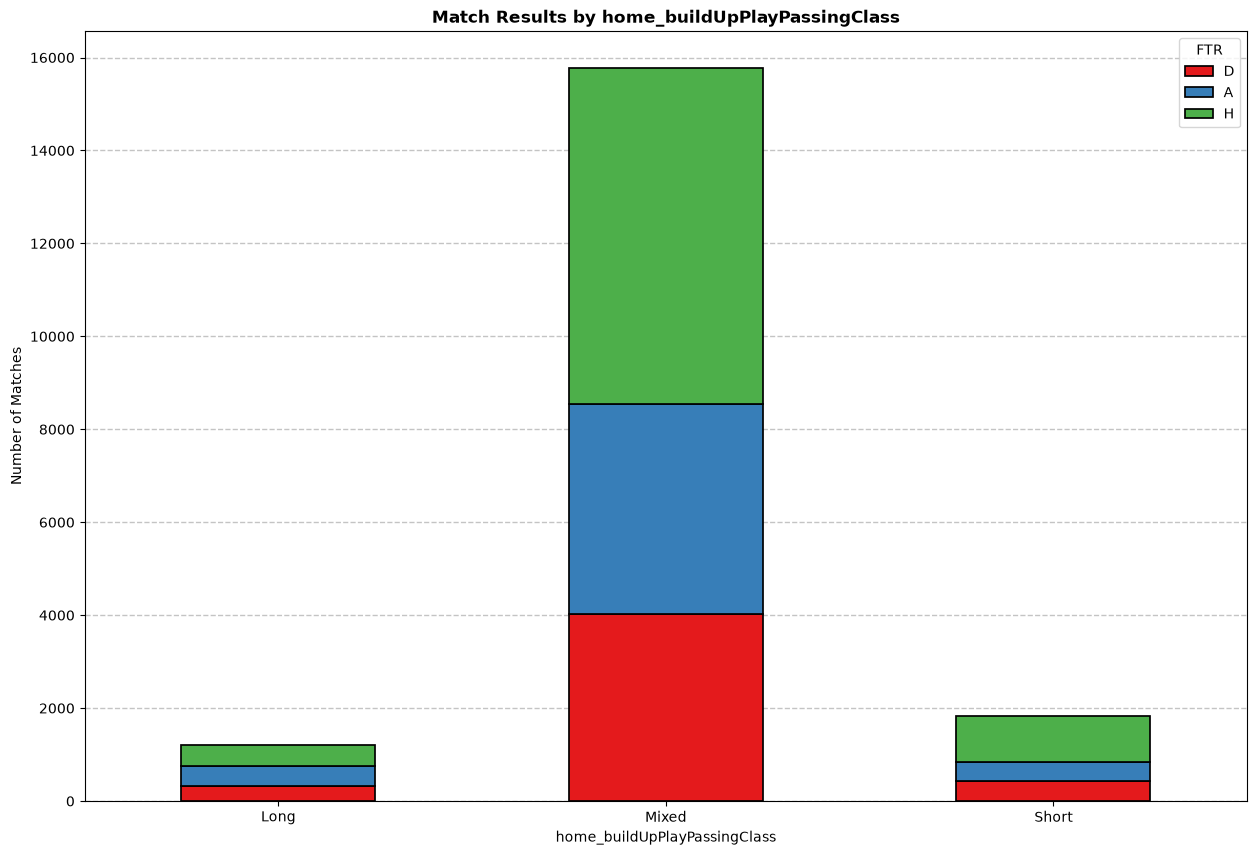

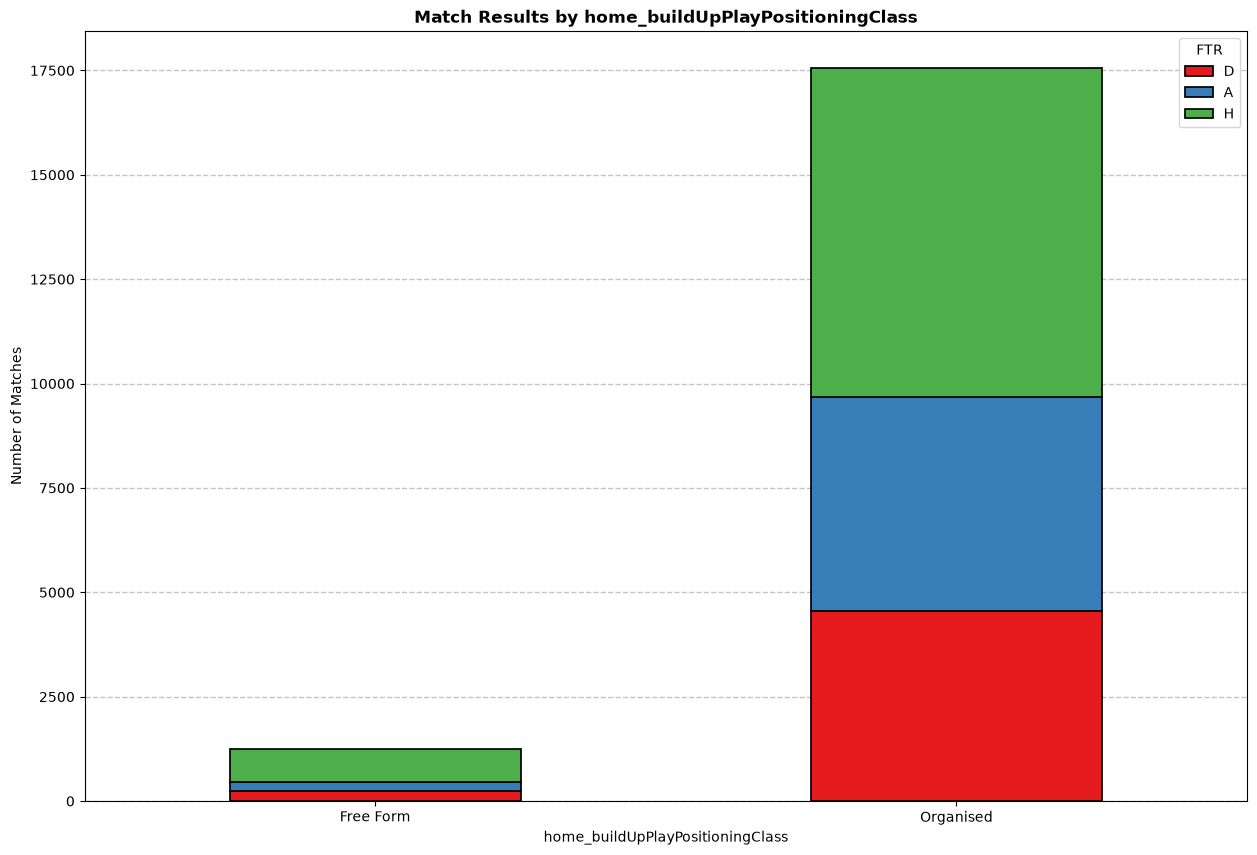

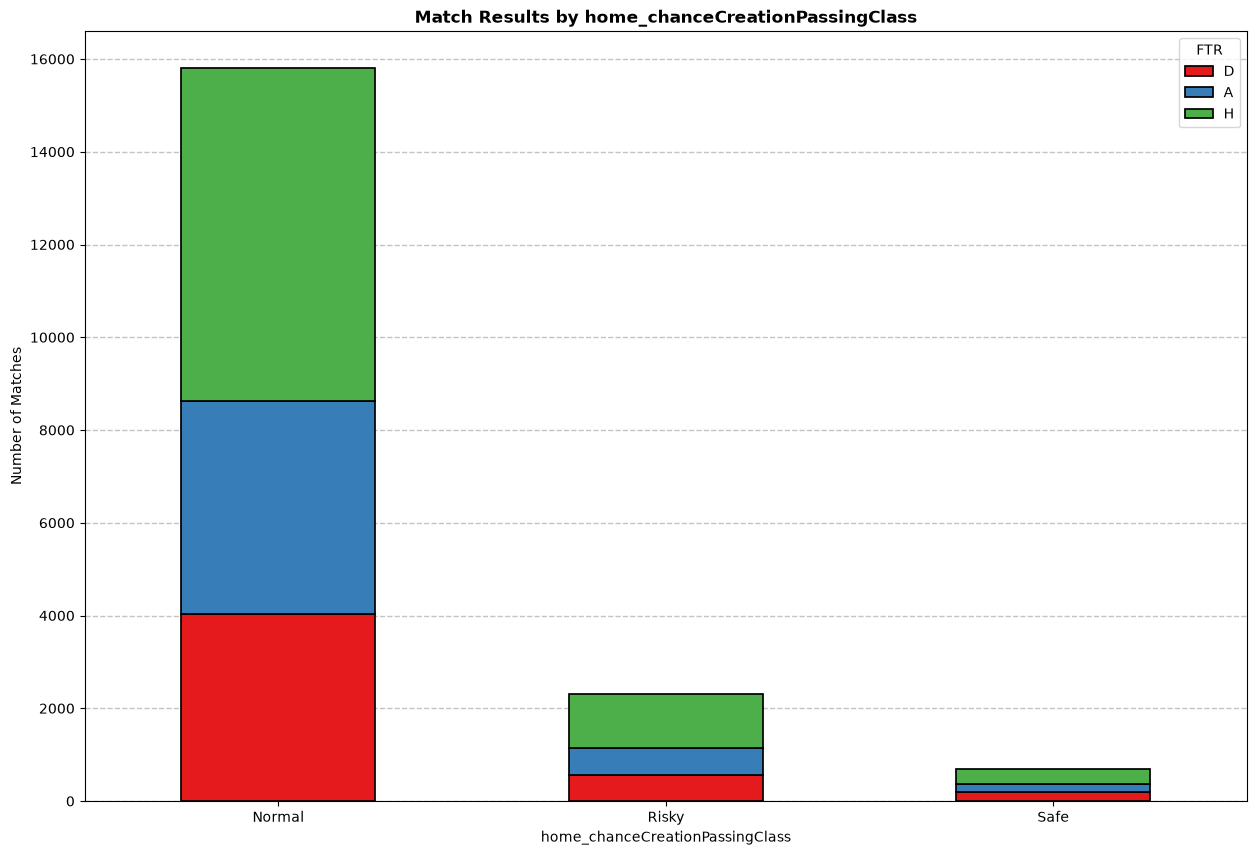

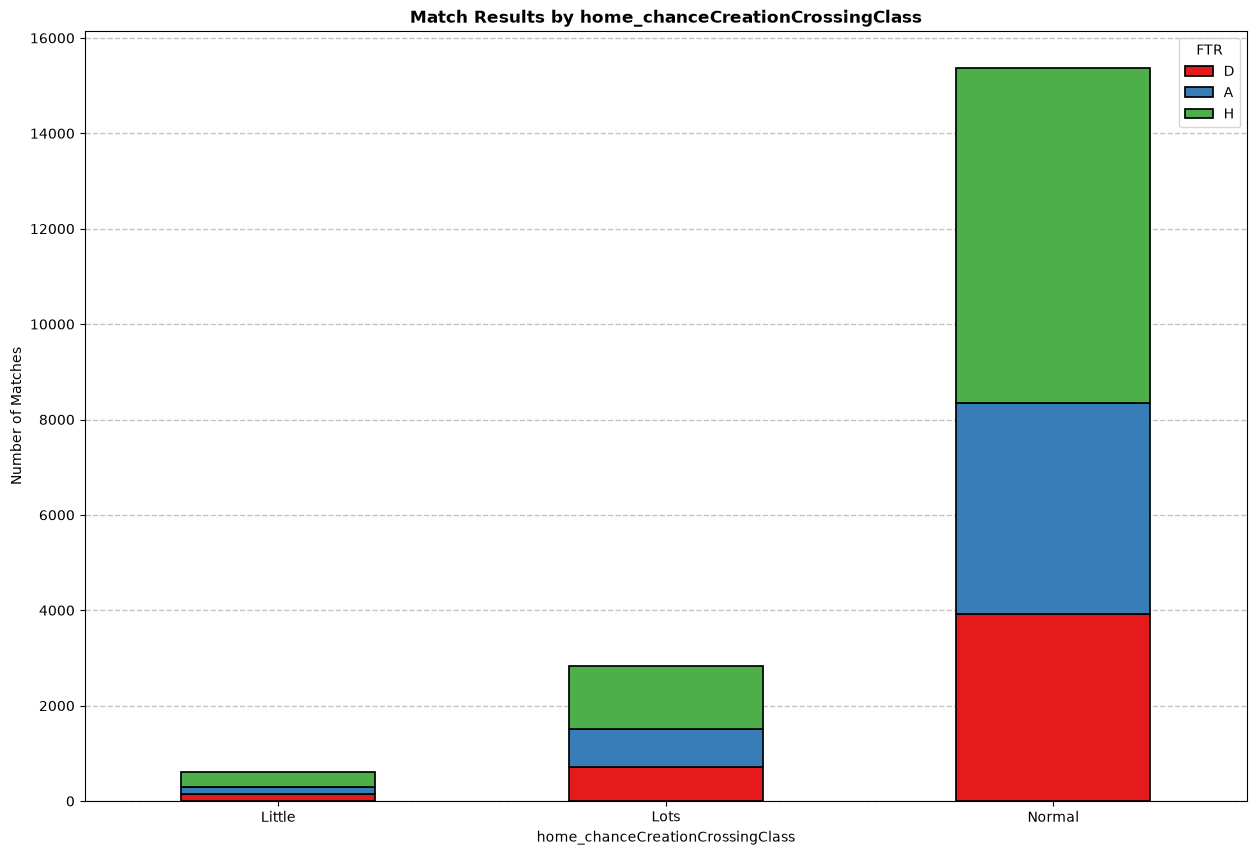

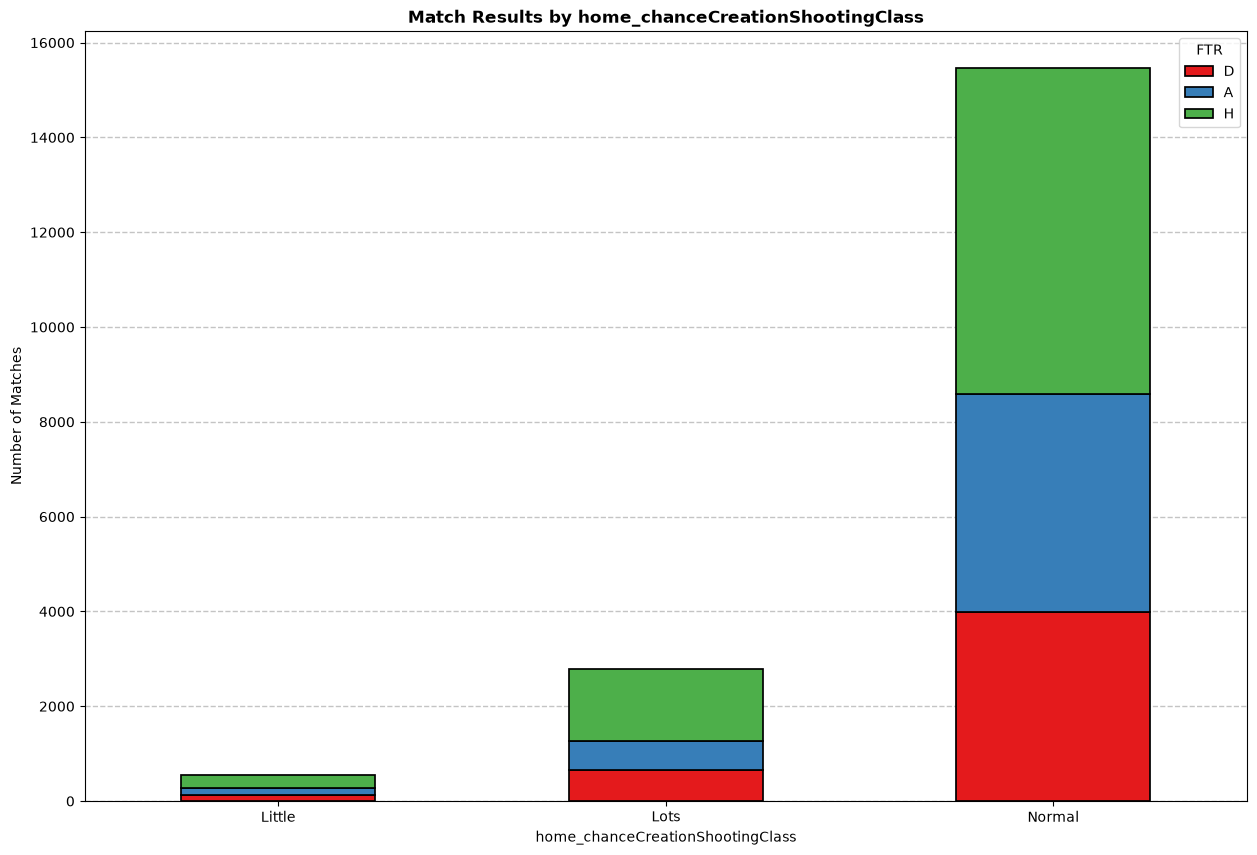

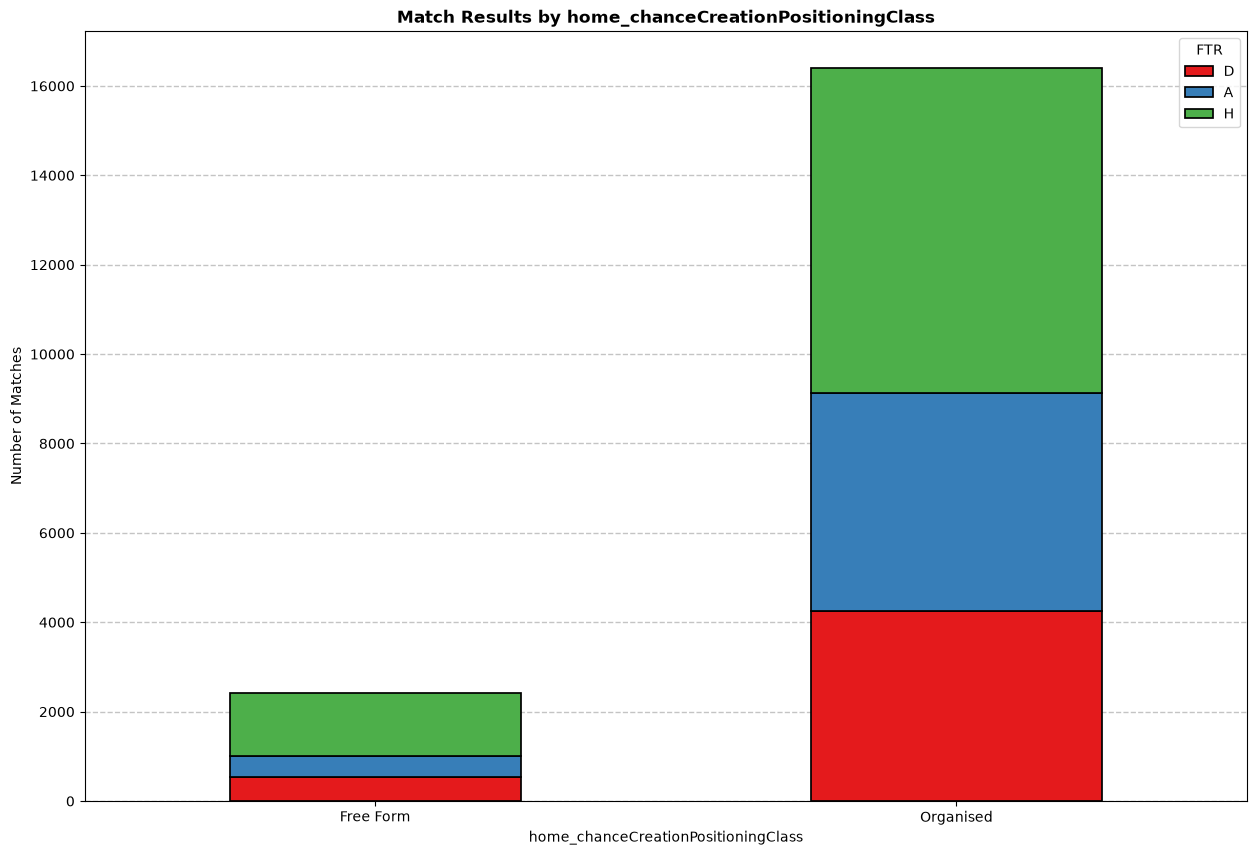

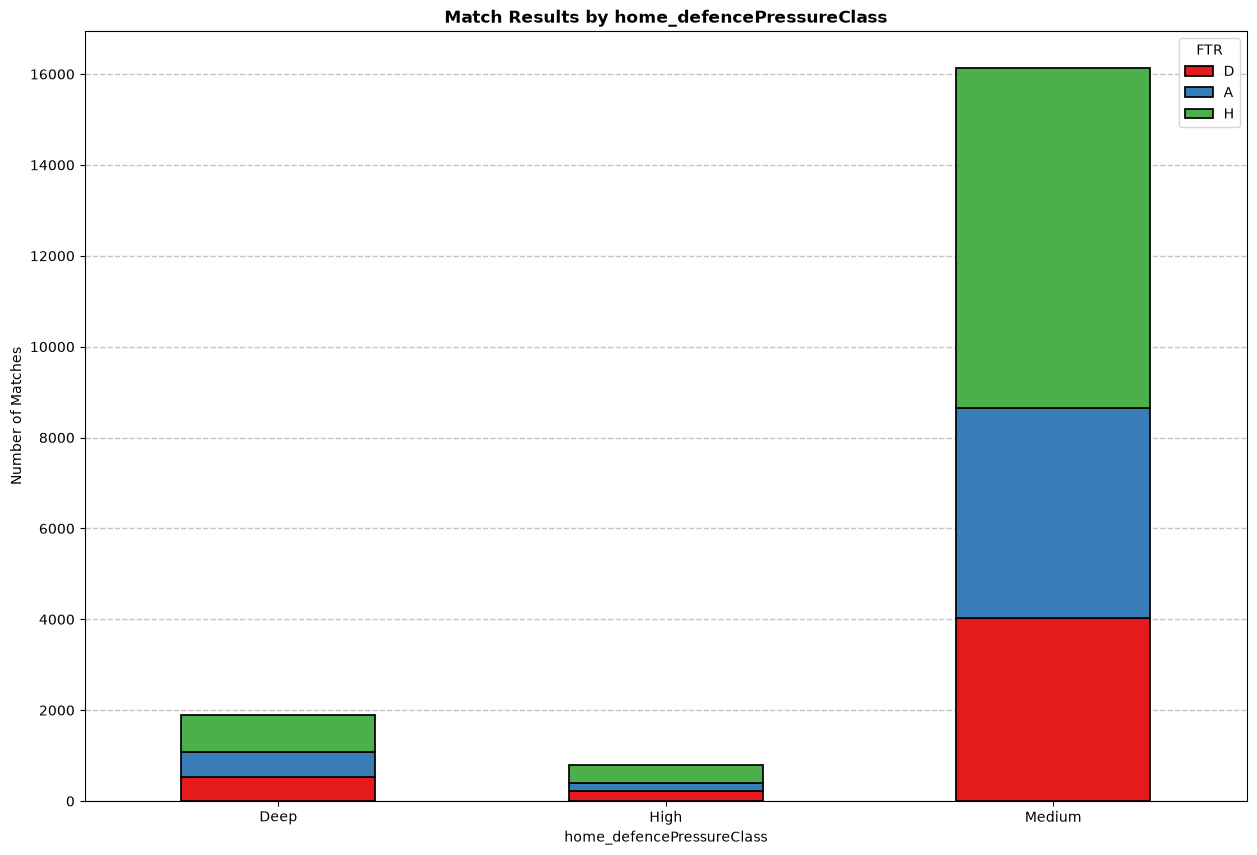

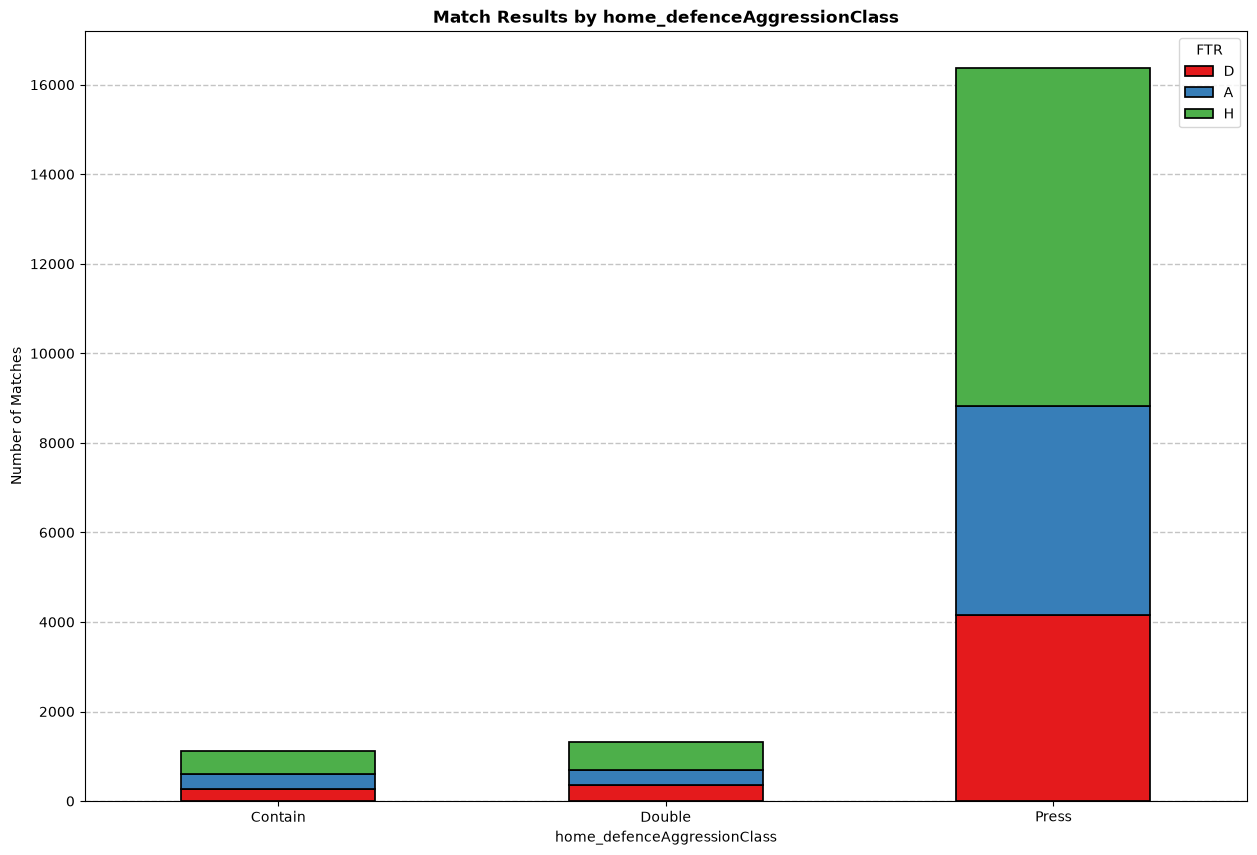

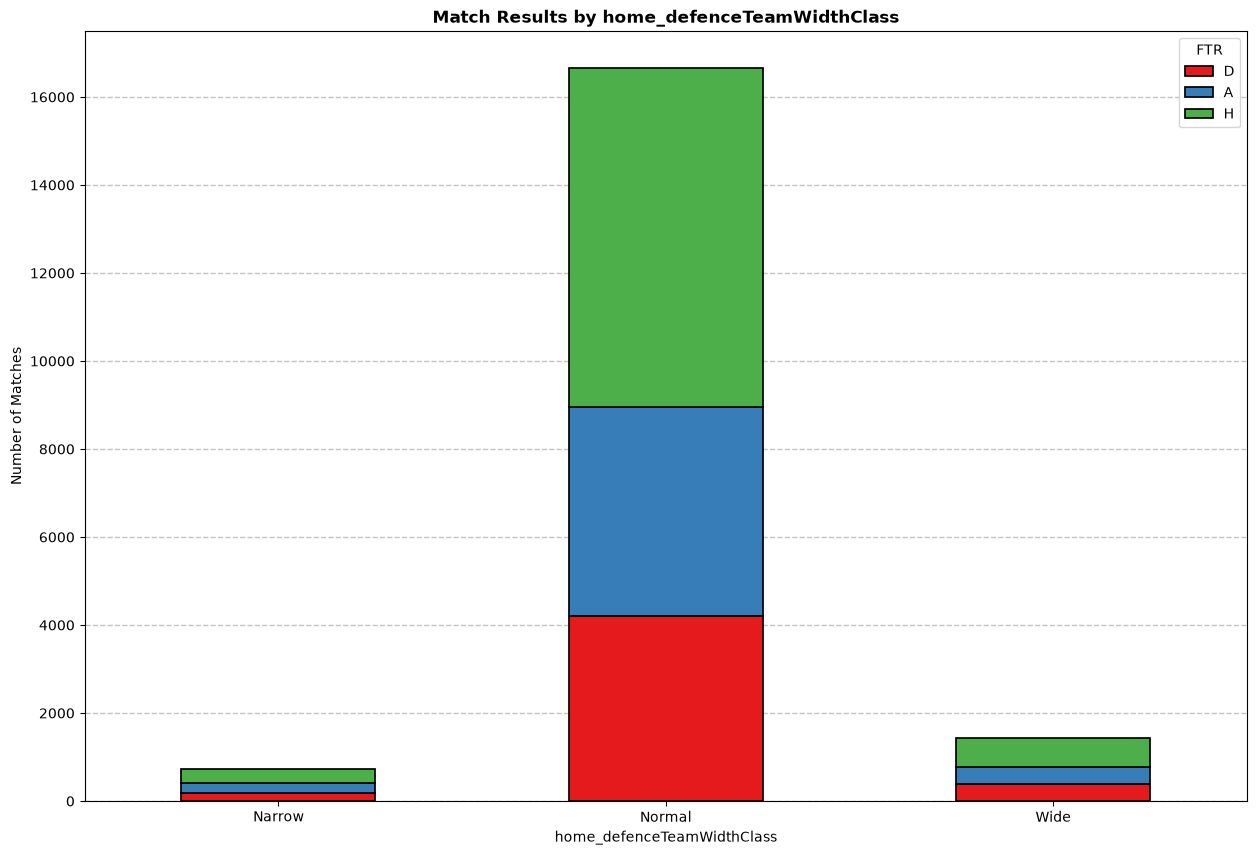

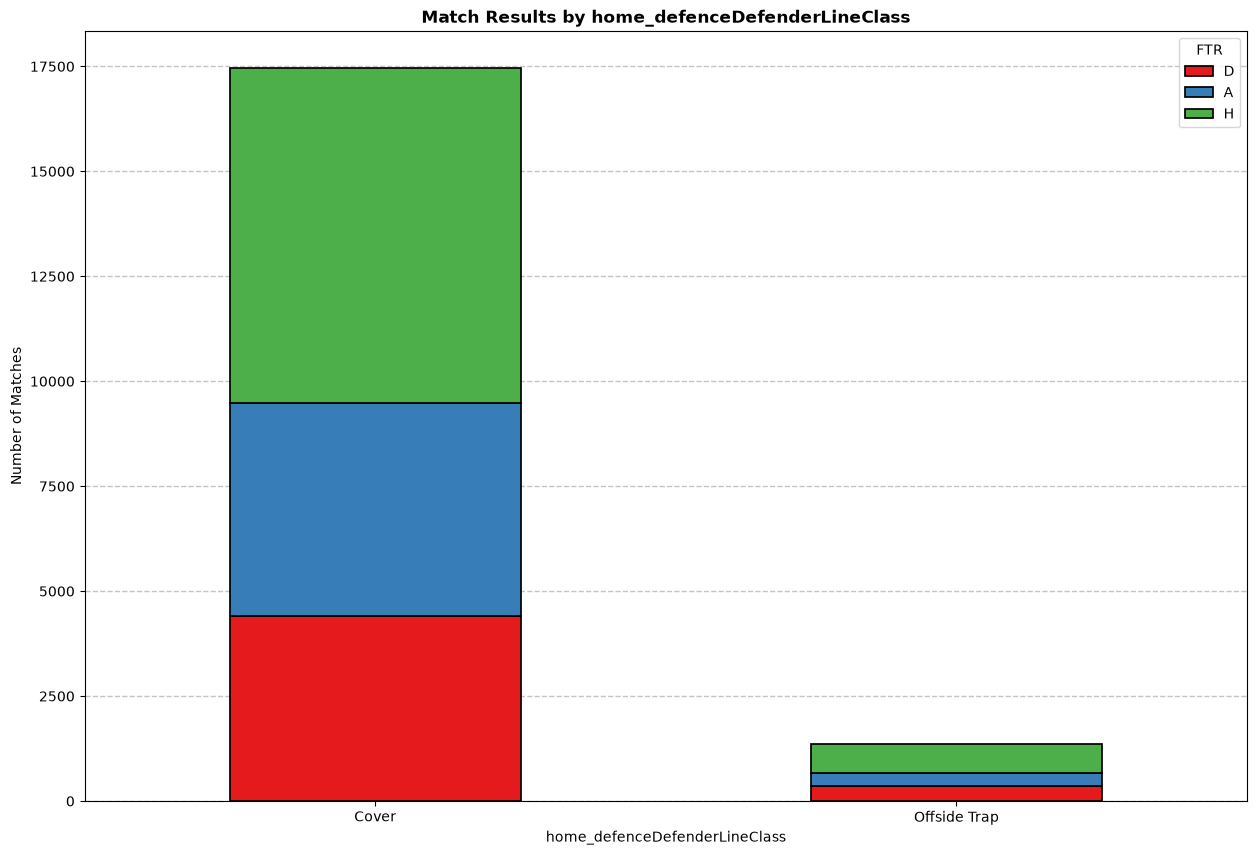

In [212]:
for col in cat_col:

    result_counts = pd.crosstab(data[col], data["FTR"])
    result_counts = result_counts[["D", "A", "H"]]

    result_counts.plot(kind="bar", figsize=(15,10) ,stacked=True, linewidth=1.25, color=sns.color_palette("Set1"), edgecolor="black")

    plt.title(f"Match Results by {col}", fontweight="bold")
    plt.xlabel(col)
    plt.ylabel("Number of Matches")
    plt.xticks(rotation=0)
    plt.legend(title="FTR")
    plt.grid(axis="y", linestyle="--", alpha=0.75, linewidth=1)
    plt.show()

#### Categorical Attributes Evaluation
The categorical attributes show no clear playing style consistently associated with a particular match result. Most differences appear to reflect uneven category frequencies and the general outcome distribution rather than a strong relationship with FTR.

## Overall Evaluation
Overall, the home-team attributes show limited predictive patterns when examined individually, although they may still provide useful information when combined during modelling. Therefore, all attributes will be retained for modelling except home_buildUpPlayDribbling, which is removed because approximately 75.8% of its values are missing.

---